In [27]:
# This script is for high stats evaluation of our reconstruction performance
# Author: Prabhjot Singh (prabhjot@fnal.gov)
# Date: 2026 March 20


In [28]:
from analyticresults import AnalyticResults
# python libraries
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from pathlib import Path
import sys
import os
from scipy.spatial import KDTree
import pandas as pd
import seaborn as sns

np.set_printoptions(linewidth=1000)

In [29]:
# skip notebook if missing truth files
SKIP_NOTEBOOK = False   # TODO: what does this do?

print ("Checking for required truth files...")

# helper function to skip notebook execution
def skip_if_needed():
    if globals().get("SKIP_NOTEBOOK", False):
        return True
    return False

Checking for required truth files...


In [30]:
# High statistics evaluation for COSMIC CLUSTERS only (q_true != 1)
# Otherwise we pass these variables from the main script

SBNDCODE_VERSION          = "v10_06_00"   # Use the latest version available
PROCESS                   = "nu_spill"    # options: "nu_spill", "cosmic_spill"
apa                       = "APA0"        # options: "APA0", "APA1"
event_low                 = 0             # Starting event number for processing
event_high                = 12            # Ending event number for processing

# Directories for input and output files
OUTDIR=Path("/exp/sbnd/data/users/prabhjot/wirecell_clustering/cluster_evaluation/runcode")
SUBDIR="Results_MC_2viewactive_2viewdead_newXin" # TODO: we need to find a way of not hardcoding this
OUTDIR=OUTDIR / SUBDIR

if PROCESS == "nu_spill":
  OUTDIR = OUTDIR / SBNDCODE_VERSION / PROCESS    
elif PROCESS == "cosmics":
  OUTDIR = OUTDIR / SBNDCODE_VERSION / "cosmics"
else:
  print("Incorrect PROCESS.")
  exit()

NEWOUTDIR     = OUTDIR/"xyz-coordinates"

PLOTDIR = OUTDIR / "plots"                  # Directory to save plots
PLOTDIR = PLOTDIR / apa
PLOTDIR.mkdir(parents=True, exist_ok=True)  # Create the directory if it doesn't exist

# List of other important parameters that we will need to pass to the clustering evaluation script
radius_efficiency         = 1             # in cm, radius around true point to look for reco points for efficiency calculation
radius_purity_xz          = 1             # in cm, radius in xz plane around reco point to look for true points for purity calculation
radius_purity_yz          = 2             # in cm, radius in yz plane around reco point to look for true points for purity calculation
min_recopoints_threshold  = 5             # Minimum number of reco points within the radius to consider a true point as matched
min_cluster_energy        = 10            # in MeV
min_true_points_cutoff    = 200           # Minimum number of true points in a cluster to consider it for evaluation
min_reco_points_cutoff    = 200           # Minimum number of reco points in a cluster to consider it for evaluation
ShiftReco_Z               = False          # Whether to shift reco points in z to match true points for better matching
Draw_debugging_Plots      = True          # To decide if we want to draw all plots or not

# Booleans to decide which selections to apply
Apply_energy_cutoff           = True          # Whether to apply energy cutoff on true points
Apply_min_true_points_cutoff  = True          # Whether to apply minimum true points cutoff on true clusters
Apply_min_reco_points_cutoff  = True          # Whether to apply minimum reco points cutoff on true clusters
Apply_fiducial_volume_cut     = True          # Whether to apply fiducial volume cut on both true and reco points

# Wirecell fiducial volume boundaries (cm)
x_min                     = -250.0
x_max                     = 250.0
y_min                     = -203.3
y_max                     = 200.5
z_min                     = 4.7
z_max                     = 500.6

# other customization parameters
marker_size=1

# print all above parameters for reference
print("SBNDCODE_VERSION:", SBNDCODE_VERSION)
print("PROCESS:", PROCESS)
print("apa:", apa)
print("first event:", event_low)
print("last event:", event_high)
print("")

# print directories for input and output files
print("Directories for input and output files")
print("Output directory:",            OUTDIR)
print("Subdirectory for this run:",   SUBDIR)
print("Directory for saving plots:",  PLOTDIR)
print("")

# print parameters used for selections
print("Parameters used for selections")
print("Shift reco points in z:",        ShiftReco_Z)
print("Reco points threshold:",         min_recopoints_threshold, "reco points")
print("Reco points threshold radius:" , radius_efficiency,        "cm for efficiency")
print("True points purity radius:",     radius_purity_xz,         "cm in xz plane and", radius_purity_yz, "cm in yz plane for purity")
print("min_cluster_energy:",            min_cluster_energy)
print("min_true_points_cutoff:",        min_true_points_cutoff)
print("Fiducial volume, X:",                                   x_min,                    "to",                 x_max,            "cm")
print("Fiducial volume, Y:",                                   y_min,                    "to",                 y_max,            "cm")
print("Fiducial volume, Z:",                                   z_min,                    "to",                 z_max,            "cm")
print("Drawing all debugging plots: ",                    Draw_debugging_Plots)
print("Applying energy cutoff on true points:",           Apply_energy_cutoff)
print("Applying minimum true points cutoff on true clusters:", Apply_min_true_points_cutoff)
print("Applying fiducial volume cut on true and reco points:", Apply_fiducial_volume_cut)
print("")

# print other customization parameters
print("other customization parameters")
print("Marker size is set to:", marker_size)

SBNDCODE_VERSION: v10_06_00
PROCESS: nu_spill
apa: APA0
first event: 0
last event: 12

Directories for input and output files
Output directory: /exp/sbnd/data/users/prabhjot/wirecell_clustering/cluster_evaluation/runcode/Results_MC_2viewactive_2viewdead_newXin/v10_06_00/nu_spill
Subdirectory for this run: Results_MC_2viewactive_2viewdead_newXin
Directory for saving plots: /exp/sbnd/data/users/prabhjot/wirecell_clustering/cluster_evaluation/runcode/Results_MC_2viewactive_2viewdead_newXin/v10_06_00/nu_spill/plots/APA0

Parameters used for selections
Shift reco points in z: False
Reco points threshold: 5 reco points
Reco points threshold radius: 1 cm for efficiency
True points purity radius: 1 cm in xz plane and 2 cm in yz plane for purity
min_cluster_energy: 10
min_true_points_cutoff: 200
Fiducial volume, X: -250.0 to 250.0 cm
Fiducial volume, Y: -203.3 to 200.5 cm
Fiducial volume, Z: 4.7 to 500.6 cm
Drawing all debugging plots:  True
Applying energy cutoff on true points: True
Applying 

In [31]:
 # Function to read in input files and return true and reco point information
def read_true_coordinates(files):
    """Reads coordinates from text files and returns numpy arrays."""
    _x = np.loadtxt(files[0])
    _y = np.loadtxt(files[1])
    _z = np.loadtxt(files[2])
    _id = np.loadtxt(files[3])
    _q = np.loadtxt(files[4])
    _e = np.loadtxt(files[5])
    _t = np.loadtxt(files[6])
    return _x, _y, _z, _id, _q, _e, _t

def read_pred_coordinates(files):
    """Reads coordinates from text files and returns numpy arrays."""
    _x = np.loadtxt(files[0])
    _y = np.loadtxt(files[1])
    _z = np.loadtxt(files[2])
    _id = np.loadtxt(files[3])
    _q = np.loadtxt(files[4])
    return _x, _y, _z, _id, _q

In [32]:
# Function to create and read files for each event
def read_files_for_event(evt):
    
    fx_true_apa0  = NEWOUTDIR / str(evt) / "x_truth_apa0.txt"
    fy_true_apa0  = NEWOUTDIR / str(evt) / "y_truth_apa0.txt"
    fz_true_apa0  = NEWOUTDIR / str(evt) / "z_truth_apa0.txt"
    fq_true_apa0  = NEWOUTDIR / str(evt) / "charge_truth_apa0.txt"
    fid_true_apa0 = NEWOUTDIR / str(evt) / "clusterid_truth_apa0.txt"
    fe_true_apa0  = NEWOUTDIR / str(evt) / "energy_truth_apa0.txt"
    ft_true_apa0  = NEWOUTDIR / str(evt) / "time_truth_apa0.txt"

    fx_true_apa1  = NEWOUTDIR / str(evt) / "x_truth_apa1.txt"
    fy_true_apa1  = NEWOUTDIR / str(evt) / "y_truth_apa1.txt"
    fz_true_apa1  = NEWOUTDIR / str(evt) / "z_truth_apa1.txt"
    fq_true_apa1  = NEWOUTDIR / str(evt) / "charge_truth_apa1.txt"
    fid_true_apa1 = NEWOUTDIR / str(evt) / "clusterid_truth_apa1.txt"
    fe_true_apa1  = NEWOUTDIR / str(evt) / "energy_truth_apa1.txt"
    ft_true_apa1  = NEWOUTDIR / str(evt) / "time_truth_apa1.txt"

    fx_pred_apa0  = NEWOUTDIR / str(evt) / "x_clustering_apa0.txt"
    fy_pred_apa0  = NEWOUTDIR / str(evt) / "y_clustering_apa0.txt"
    fz_pred_apa0  = NEWOUTDIR / str(evt) / "z_clustering_apa0.txt"
    fq_pred_apa0  = NEWOUTDIR / str(evt) / "charge_clustering_apa0.txt"
    fid_pred_apa0 = NEWOUTDIR / str(evt) / "clusterid_clustering_apa0.txt"

    fx_pred_apa1  = NEWOUTDIR / str(evt) / "x_clustering_apa1.txt"
    fy_pred_apa1  = NEWOUTDIR / str(evt) / "y_clustering_apa1.txt"
    fz_pred_apa1  = NEWOUTDIR / str(evt) / "z_clustering_apa1.txt"
    fq_pred_apa1  = NEWOUTDIR / str(evt) / "charge_clustering_apa1.txt"
    fid_pred_apa1 = NEWOUTDIR / str(evt) / "clusterid_clustering_apa1.txt"

    # check for missing or empty truth files
    if apa =='APA0':
        if not fx_true_apa0.exists() or os.stat(fx_true_apa0).st_size <= 1:
            print(f"{fx_true_apa0} not found or empty. Skipping rest of notebook.")
            SKIP_NOTEBOOK = True
        if not fy_true_apa0.exists() or os.stat(fy_true_apa0).st_size<= 1:
            print(f"{fy_true_apa0} not found or empty. Skipping rest of notebook.")
            SKIP_NOTEBOOK = True
        if not fz_true_apa0.exists() or os.stat(fz_true_apa0).st_size <= 1:
            print(f"{fz_true_apa0} not found or empty. Skipping rest of notebook.")
            SKIP_NOTEBOOK = True
        if not fx_pred_apa0.exists() or os.stat(fx_pred_apa0).st_size <= 1:
            print(f"{fx_pred_apa0} not found or empty. Skipping rest of notebook.")
            SKIP_NOTEBOOK = True
        if not fy_pred_apa0.exists() or os.stat(fy_pred_apa0).st_size<= 1:
            print(f"{fy_pred_apa0} not found or empty. Skipping rest of notebook.")
            SKIP_NOTEBOOK = True
        if not fz_pred_apa0.exists() or os.stat(fz_pred_apa0).st_size <= 1:
            print(f"{fz_pred_apa0} not found or empty. Skipping rest of notebook.")
            SKIP_NOTEBOOK = True
    elif apa =='APA1':
        if not fx_true_apa1.exists() or os.stat(fx_true_apa1).st_size <= 1:
            print(f"{fx_true_apa1} not found or empty. Skipping rest of notebook.")
            SKIP_NOTEBOOK = True
        if not fy_true_apa1.exists() or os.stat(fy_true_apa1).st_size <= 1:
            print(f"{fy_true_apa1} not found or empty. Skipping rest of notebook.")
            SKIP_NOTEBOOK = True
        if not fz_true_apa1.exists() or os.stat(fz_true_apa1).st_size <= 1:
            print(f"{fz_true_apa1} not found or empty. Skipping rest of notebook.")
            SKIP_NOTEBOOK = True
        if not fx_pred_apa1.exists() or os.stat(fx_pred_apa1).st_size <= 1:
            print(f"{fx_pred_apa1} not found or empty. Skipping rest of notebook.")
            SKIP_NOTEBOOK = True
        if not fy_pred_apa1.exists() or os.stat(fy_pred_apa1).st_size<= 1:
            print(f"{fy_pred_apa1} not found or empty. Skipping rest of notebook.")
            SKIP_NOTEBOOK = True
        if not fz_pred_apa1.exists() or os.stat(fz_pred_apa1).st_size <= 1:
            print(f"{fz_pred_apa1} not found or empty. Skipping rest of notebook.")
            SKIP_NOTEBOOK = True
    else:
        print("Incorrect apa.")

    # Skip if truth files not found
    if skip_if_needed():
        print("Skipping this cell.")
    else:
        # group files for loading
        true_files_apa0 = [fx_true_apa0, fy_true_apa0, fz_true_apa0, fid_true_apa0, fq_true_apa0, fe_true_apa0, ft_true_apa0]  # Replace with file names
        true_files_apa1 = [fx_true_apa1, fy_true_apa1, fz_true_apa1, fid_true_apa1, fq_true_apa1, fe_true_apa1, ft_true_apa1]  # Replace with file names
        pred_files_apa0 = [fx_pred_apa0, fy_pred_apa0, fz_pred_apa0, fid_pred_apa0, fq_pred_apa0]
        pred_files_apa1 = [fx_pred_apa1, fy_pred_apa1, fz_pred_apa1, fid_pred_apa1, fq_pred_apa1]

        # Define placeholders
        x_true = y_true = z_true = id_true = q_true = e_true = t_true = None
        x_pred = y_pred = z_pred = id_pred = q_pred = None

        # Load the true and predicted coordinates
        if apa =='APA0':
            x_true_apa0, y_true_apa0, z_true_apa0, id_true_apa0, q_true_apa0, e_true_apa0 , t_true_apa0 = read_true_coordinates(true_files_apa0)
            x_pred_apa0, y_pred_apa0, z_pred_apa0, id_pred_apa0, q_pred_apa0                            = read_pred_coordinates(pred_files_apa0)

            x_true  = x_true_apa0
            y_true  = y_true_apa0
            z_true  = z_true_apa0
            id_true = id_true_apa0
            q_true  = q_true_apa0
            e_true  = e_true_apa0
            t_true  = t_true_apa0

            x_pred  = x_pred_apa0
            y_pred  = y_pred_apa0
            z_pred  = z_pred_apa0
            id_pred = id_pred_apa0
            q_pred  = q_pred_apa0

        elif apa =='APA1':
            x_true_apa1, y_true_apa1, z_true_apa1, id_true_apa1, q_true_apa1, e_true_apa1, t_true_apa1= read_true_coordinates(true_files_apa1)
            x_pred_apa1, y_pred_apa1, z_pred_apa1, id_pred_apa1, q_pred_apa1                          = read_pred_coordinates(pred_files_apa1)

            x_true  = x_true_apa1
            y_true  = y_true_apa1
            z_true  = z_true_apa1
            id_true = id_true_apa1
            q_true  = q_true_apa1   
            e_true  = e_true_apa1
            t_true  = t_true_apa1

            x_pred  = x_pred_apa1
            y_pred  = y_pred_apa1
            z_pred  = z_pred_apa1
            id_pred = id_pred_apa1
            q_pred  = q_pred_apa1

        else:
            print("Incorrect apa.") 

    return x_true, y_true, z_true, id_true, q_true, e_true, t_true, x_pred, y_pred, z_pred, id_pred, q_pred

      

In [33]:
# Function to apply energy cutoff for each true cluster
def apply_energy_cutoff(true_points, energy_cutoff):

  # Compute sum of e_true per cluster (grouped by id_true)
  cluster_sums = {}
  for point in true_points:
      cluster_sums[point[3]] = cluster_sums.get(point[3], 0) + point[5]  # id_true at index 3, e_true at index 5

  # Filter points, keeping only clusters where sum(e_true) >= min_cluster_energy
  true_points = np.array([point for point in true_points if cluster_sums[point[3]] >= energy_cutoff])

  return true_points

In [34]:
# Function to apply minimum points cutoff
def apply_min_true_points_cutoff(true_points, min_points):
    cluster_counts = {}
    for point in true_points:
        cluster_id = point[3]
        cluster_counts[cluster_id] = cluster_counts.get(cluster_id, 0) + 1
    
    true_points = np.array([point for point in true_points if cluster_counts[point[3]] >= min_points])
    return true_points

In [35]:
# Function to apply minimum reco points cutoff for reco clusters
def apply_min_reco_points_cutoff(reco_points, min_points):
    cluster_counts = {}
    for point in reco_points:
        cluster_id = point[3]
        cluster_counts[cluster_id] = cluster_counts.get(cluster_id, 0) + 1
    
    reco_points = np.array([point for point in reco_points if cluster_counts[point[3]] >= min_points])
    return reco_points

In [36]:
# Function to apply fiducial volume cut to true points
def apply_fiducial_volume_cut_true(true_points):
    """Apply fiducial volume cuts to true points (6D array)."""
    filtered_points = []
    for point in true_points:
        x, y, z = point[0], point[1], point[2]
        if x_min <= x <= x_max and y_min <= y <= y_max and z_min <= z <= z_max:
            filtered_points.append(point)
    return np.array(filtered_points) if filtered_points else np.array([]).reshape(0, 6)

# Function to apply fiducial volume cut to reco points
def apply_fiducial_volume_cut_reco(reco_points):
    """Apply fiducial volume cuts to reco points (5D array)."""
    filtered_points = []
    for point in reco_points:
        x, y, z = point[0], point[1], point[2]
        if x_min <= x <= x_max and y_min <= y <= y_max and z_min <= z <= z_max:
            filtered_points.append(point)
    return np.array(filtered_points) if filtered_points else np.array([]).reshape(0, 5)

In [37]:
# Function to re-assign cluster IDs to both true and reco points based on proximity in x and y coordinates
def reassign_cluster_ID_true(points_5d):
    
    # Group points by ID and compute average x for each cluster
    clusters = {}
    for point in points_5d:   
        cluster_id = point[3]  # Original cluster ID
        if cluster_id not in clusters:
            clusters[cluster_id] = []
        clusters[cluster_id].append(point)

    # Compute new cluster IDs based on average x position
    new_points = []
    for cluster_id, points in clusters.items():
        points = np.array(points)
        #avg_xy = np.mean(points[:, 0]) + np.mean(points[:, 1])  # Compute average x-position, 0 is x-coordinate index
        avg_xy = np.mean(points[:, 0])
        # convert avg_x to nearest integer (since x is in cm, we can round to nearest cm)
        #avg_xy = round(avg_xy)
        # get avg_xy to only 2 decimal places
        avg_xy = round(avg_xy, 2)
        if points[:, 4].any() == 1:
            avg_xy = 9999+len(points_5d)  # If any point in the cluster has id_true == 1, add 9999 to avg_xy to make it a unique cluster ID for true points
        #else:
        #    avg_xy = round(avg_xy)
        points[:, 3] = avg_xy  # Reassign cluster ID to avg_x, because index 3 is cluster ID
        new_points.append(points)

    # Flatten list into a NumPy array
    points_5d_after_reassiging = np.vstack(new_points)

    return points_5d_after_reassiging


In [38]:
# Function to re-assign cluster IDs to both true and reco points based on proximity in x and y coordinates
def reassign_cluster_ID_reco(points_5d_reco):
    
    # Group points by ID and compute average x for each cluster
    clusters = {}
    for point in points_5d_reco:   
        cluster_id = point[3]  # Original cluster ID
        if cluster_id not in clusters:
            clusters[cluster_id] = []
        clusters[cluster_id].append(point)

    # Compute new cluster IDs based on average x position
    new_points = []
    for cluster_id, points in clusters.items():
        points = np.array(points)
        avg_xy = np.mean(points[:, 0]) # Compute average x-position, 0 is x-coordinate index
        #avg_xy = np.mean(points[:, 0]) + np.mean(points[:, 1])  # Compute average x-position, 0 is x-coordinate index
        # convert avg_x to nearest integer (since x is in cm, we can round to nearest cm)
        avg_xy = round(avg_xy, 2)
        points[:, 3] = avg_xy  # Reassign cluster ID to avg_x, because index 3 is cluster ID
        new_points.append(points)

    # Flatten list into a NumPy array
    points_5d_after_reassiging = np.vstack(new_points)

    return points_5d_after_reassiging


In [39]:
# Function to group clusters by cluster ID
def GroupClustersByID(points_5d):
    clusters = {}
    for point in points_5d:
        cluster_id = point[3]  # Cluster ID is at index 3
        if cluster_id not in clusters:
            clusters[cluster_id] = []
        clusters[cluster_id].append(point)
    return clusters

In [40]:
# Function to increase reco points z values by +0.5 cm to account for the shift in the geometry file
def ShiftRecoClusterZValues(clusters_reco, shift_value=0.5):
    for cluster_id, points in clusters_reco.items():
        points = np.array(points)
        shifted_points = points[:, 2]
        shifted_points = shifted_points + shift_value

        points[:, 2] = shifted_points # Shift z values, since index 2 is z-coordinate
        clusters_reco[cluster_id] = points
    return clusters_reco

In [41]:
# Function to draw the true and the reco clusters together in the same plot to visually compare them
# We will use different colors for true and reco clusters.
# This one for x-z plane
def DrawTrueRecoClustersXZ(true_clusters, predicted_clusters, event):

    view = "XZ"

    # Create figure and subplots
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))  # 1 row, 2 columns
    # First scatter plot (left)
    axes[0].set_xlim(0, 500)  # Set x-axis range
    axes[0].set_ylim(-250, 250)  # Set y-axis range
    axes[0].set_xlabel("z [cm]")
    axes[0].set_ylabel("x [cm]")
    axes[0].set_title("True clusters: Event " + str(event) + ", " + apa + ", " + view)
    # Draw true clusters in the first subplot
    for cluster_id, points in true_clusters.items():
        points = np.array(points)
        true_x_cluster = points[:, 0]
        true_z_cluster = points[:, 2]
        scatter = axes[0].scatter(true_z_cluster, true_x_cluster, s=marker_size, alpha=0.5)
        color = scatter.get_facecolor()[0]
        axes[0].plot([], [], color=color, label=f'Cluster {cluster_id:.0f}')
    axes[0].legend()

    # Second scatter plot (right)
    axes[1].set_xlim(axes[0].get_xlim())  # Set x-axis range
    axes[1].set_ylim(axes[0].get_ylim())  # Set y-axis range
    axes[1].set_xlabel("z [cm]")
    axes[1].set_ylabel("x [cm]")
    axes[1].set_title("Reco clusters: Event " + str(event) + ", " + apa + ", " + view)
    
    # Draw reco clusters in the second subplot
    for cluster_id, points in predicted_clusters.items():
        points = np.array(points)
        reco_x_cluster = points[:, 0]
        reco_z_cluster = points[:, 2]
        scatter = axes[1].scatter(reco_z_cluster, reco_x_cluster, s=1, alpha=0.5)
        color = scatter.get_facecolor()[0]
        axes[1].plot([], [], color=color, label=f'Cluster {cluster_id:.0f}')
    axes[1].legend()
    # Adjust layout and show plot
    plt.tight_layout()
    plt.savefig(PLOTDIR_EVT/ f"all_clusters_reco_true_event{event}_apa_{apa}_{view}.png")
    # plt.show(block=False)

In [42]:
# Function to draw the true and the reco clusters together in the same plot to visually compare them
# This one for YZ plane
def DrawTrueRecoClustersYZ(true_clusters, predicted_clusters, event):

    view = "YZ"

    # Create figure and subplots
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))  # 1 row, 2 columns
    # First scatter plot (left)
    axes[0].set_xlim(0, 500)  # Set x-axis range
    axes[0].set_ylim(-250, 250)  # Set y-axis range
    axes[0].set_xlabel("z [cm]")
    axes[0].set_ylabel("y [cm]")
    axes[0].set_title("True clusters: Event " + str(event) + ", " + apa + ", " + view)
    # Draw true clusters in the first subplot
    for cluster_id, points in true_clusters.items():
        points = np.array(points)
        true_y_cluster = points[:, 1]
        true_z_cluster = points[:, 2]
        scatter = axes[0].scatter(true_z_cluster, true_y_cluster, s=marker_size, alpha=0.5)
        color = scatter.get_facecolor()[0]
        axes[0].plot([], [], color=color, label=f'Cluster {cluster_id:.0f}')
    axes[0].legend()

    # Second scatter plot (right)
    axes[1].set_xlim(axes[0].get_xlim())  # Set x-axis range
    axes[1].set_ylim(axes[0].get_ylim())  # Set y-axis range
    axes[1].set_xlabel("z [cm]")
    axes[1].set_ylabel("y [cm]")
    axes[1].set_title("Reco clusters: Event " + str(event) + ", " + apa + ", " + view)
    
    # Draw reco clusters in the second subplot
    for cluster_id, points in predicted_clusters.items():
        points = np.array(points)
        reco_y_cluster = points[:, 1]
        reco_z_cluster = points[:, 2]
        scatter = axes[1].scatter(reco_z_cluster, reco_y_cluster, s=1, alpha=0.5)
        color = scatter.get_facecolor()[0]
        axes[1].plot([], [], color=color, label=f'Cluster {cluster_id:.0f}')
    axes[1].legend()
    # Adjust layout and show plot
    plt.tight_layout()
    plt.savefig(PLOTDIR_EVT / f"all_clusters_reco_true_event{event}_apa_{apa}_{view}.png")
    # plt.show(block=False)

In [43]:
# Function to evaluate efficiency. We calculate energy-weighted efficiency
def EvaluateEfficiency(clusters_true, clusters_reco, event):

    # store efficiency results
    efficiency_results = []

    # save energies of true clusters
    matched_true_cluster_energy = []
    total_true_cluster_energy   = []

    # Loop over each true cluster
    for true_cluster_id, true_points in clusters_true.items():
        true_points     = np.array(true_points)
        true_coords     = true_points[:, :3]
        true_energies   = true_points[:, 5]  # energy is the 6th column

        # Loop over each predicted cluster to find the best match
        for reco_cluster_id, reco_points in clusters_reco.items():
            reco_points = np.array(reco_points)
            reco_coords = reco_points[:, :3]

            # Build KDTree for the predicted cluster
            reco_tree = KDTree(reco_coords)

            # Query the KDTree with the true points to find nearest neighbors
            indices = reco_tree.query_ball_point(true_coords, r=radius_efficiency)  # Find all neighbors within radius

            # Count the number of neighbors for each true point
            num_neighbors = [len(neighbors) for neighbors in indices]

            # Check how many true points are within the radius of any predicted point and reweight by energy
            matched_true_points_energy = np.sum([true_energies[i] for i, neighbors in enumerate(indices) if len(neighbors) > min_recopoints_threshold])
            matched_true_cluster_energy.append(matched_true_points_energy)

            total_true_energy = np.sum(true_energies)
            total_true_cluster_energy.append(total_true_energy)

            efficiency_energy_weighted = matched_true_points_energy / total_true_energy if total_true_energy > 0 else 0
        
            # Store the efficiency result alonn with event number, true cluster ID, reco cluster ID, matched true energy and total true energy for this cluster
            efficiency_results.append({
                'event': event,
                'true_cluster_id': true_cluster_id,
                'reco_cluster_id': reco_cluster_id,
                'efficiency_energy_weighted': efficiency_energy_weighted,
                'matched_true_cluster_energy': matched_true_points_energy,
                'total_true_cluster_energy': total_true_energy
            })

    # convert this into 2D matrix and a plot
    df = pd.DataFrame(efficiency_results)
    efficiency_matrix_energy_weighted = df.pivot(index='true_cluster_id', columns='reco_cluster_id', values='efficiency_energy_weighted').fillna(0)

    # plot heatmap
    # only shows ID values upto 3 significant digits to avoid overcrowding of labels
    plt.figure(figsize=(10, 8))
    sns.heatmap(efficiency_matrix_energy_weighted, annot=True, fmt=".2f", cmap="YlGnBu", 
                xticklabels=[f"{int(x):d}" for x in efficiency_matrix_energy_weighted.columns], 
                yticklabels=[f"{int(y):d}" for y in efficiency_matrix_energy_weighted.index])

    plt.title(f"Energy-Weighted Efficiency: Event {event}, {apa}")
    plt.xlabel("Reco Cluster ID")
    plt.ylabel("True Cluster ID")
    plt.savefig(PLOTDIR_EVT / f"efficiency_energy_weighted_evt_{evt}_{apa}.png")
    # plt.show(block=False)

    return efficiency_results

In [44]:
# Purity Evaluation
def EvaluatePurity(clusters_true, clusters_reco, event):

  # store purity results
  purity_results = []

  # Loop over each reco cluster
  for reco_cluster_id, reco_points in clusters_reco.items():
      reco_points = np.array(reco_points)
      reco_coords = reco_points[:, :3]

      # loop over each true cluster
      for true_cluster_id, true_points in clusters_true.items():
          true_points = np.array(true_points)
          true_coords = true_points[:, :3]

          # Build KDTree for the true cluster
          true_tree = KDTree(true_coords)

          # Query the KDTree with the predicted points to find nearest true point
          distances, indices = true_tree.query(reco_coords, k=1)

          nearest_points = true_coords[indices]
          xz_projection = np.sqrt((nearest_points[:, 0] - reco_coords[:, 0])**2 + (nearest_points[:, 2] - reco_coords[:, 2])**2)
          yz_projection = np.sqrt((nearest_points[:, 1] - reco_coords[:, 1])**2 + (nearest_points[:, 2] - reco_coords[:, 2])**2)

          # Apply distance cuts to determine matched reco points
          matched_reco_points = reco_coords[(xz_projection <= radius_purity_xz) & (yz_projection <= radius_purity_yz)]
          total_reco_points   = len(reco_coords)
          purity              = len(matched_reco_points) / total_reco_points if total_reco_points > 0 else 0

          # Store the purity result for this cluster pair
          purity_results.append({
            'event': event,
            'reco_cluster_id': reco_cluster_id,
            'true_cluster_id': true_cluster_id,
            'matched_reco_points': len(matched_reco_points),
            'total_reco_points': total_reco_points,
            'purity': purity
          })

  # Convert purity results to a DataFrame for easier analysis
  purity_df = pd.DataFrame(purity_results)

  # Create a pivot table for the heatmap
  heatmap_data = purity_df.pivot(index='true_cluster_id', columns='reco_cluster_id', values='purity')
  
  # Plot the heatmap
  plt.figure(figsize=(12, 8))
  sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="YlGnBu", 
                xticklabels=[f"{int(x):d}" for x in heatmap_data.columns], 
                yticklabels=[f"{int(y):d}" for y in heatmap_data.index])
  plt.title(f"Purity: Event {event}, {apa}")
  plt.xlabel("Reco Cluster ID")
  plt.ylabel("True Cluster ID")
  plt.savefig(PLOTDIR_EVT /  f"purity_evt{evt}_{apa}.png")
  # plt.show(block=False)

  return purity_results

In [45]:
# Function to match true and reco clustered based on their purities and efficiencies and save this information for all matched pairs in a list for later analysis

def MatchRecoTruePairs(all_purity_results, all_eff_results):

    # Convert lists of purity and efficiency results to DataFrames
    purity_df     = pd.DataFrame(all_purity_results)
    efficiency_df = pd.DataFrame(all_eff_results)

    # Merge the two DataFrames on event, true_cluster_id, and reco_cluster_id
    merged_df = pd.merge(purity_df, efficiency_df, on=['event', 'true_cluster_id', 'reco_cluster_id'])

    # Now merged_df contains both purity and efficiency information for each true-reco cluster pair
    # Match pairs based on maximum purity
    matched_pairs       = merged_df[merged_df['purity'] > 0]
    best_matched_purity = matched_pairs.loc[matched_pairs.groupby('true_cluster_id')['purity'].idxmax()]

    # Loop over each reco cluster and find the true cluster with which it has the highest purity
    final_matched_pairs = []
    for reco_cluster_id, group in best_matched_purity.groupby('reco_cluster_id'):
        best_pair = group.loc[group['purity'].idxmax()]
        final_matched_pairs.append(best_pair)

    print("We have ", len(final_matched_pairs), "matched pairs of true and reco clusters")

    return final_matched_pairs


In [46]:
# Function to draw efficiency vs purity for all matched pairs

def DrawEfficiencyVsPurity(all_matched_pairs):
  plt.figure(figsize=(10, 8))
  cmap = plt.cm.YlGnBu.copy()
  cmap.set_under('white')
  plt.scatter([entry['efficiency_energy_weighted'] for entry in all_matched_pairs], 
              [entry['purity'] for entry in all_matched_pairs], 
              color='blue', alpha=0.7)

  plt.xlim(-0.02, 1.02)
  plt.ylim(-0.02, 1.02)
  plt.title(f"Efficiency vs Purity for True-Reco Cluster Pairs, {apa}, {len(all_matched_pairs)} clusters")
  plt.grid(True, linestyle='--', alpha=0.6)
  plt.xlabel('Efficiency')
  plt.ylabel('Purity')
  plt.savefig(PLOTDIR / f"efficiency_vs_purity_{SUBDIR}_{apa}_clusters_{len(all_matched_pairs)}.png")
  # plt.show(block=False)

  # Print information about final matched pairs
  #print("Efficiency and purity for all matched pairs:")
  #for pair in all_matched_pairs:
  #    print(f"Event: {pair['event']}, True Cluster ID: {pair['true_cluster_id']}, Reco Cluster ID: {pair['reco_cluster_id']}, Purity: {pair['purity']*100:4.2f}%, Efficiency: {pair['efficiency_energy_weighted']*100:4.2f}%")
  

In [47]:
# Fnction to draw true and reco clusters together for visual comparison and also draw their efficiency and purity values on the plot
def DrawClustersWithEfficiencyPurity(all_matched_pairs, event):
    view = "XZ"

    for pair in all_matched_pairs:
        true_cluster_id = pair['true_cluster_id']
        reco_cluster_id = pair['reco_cluster_id']
        purity          = pair['purity']
        efficiency      = pair['efficiency_energy_weighted']

        true_points     = clusters_true.get(true_cluster_id, [])
        reco_points     = clusters_reco.get(reco_cluster_id, [])

        # Create figure and subplots
        fig, axes = plt.subplots(1, 2, figsize=(12, 6))  # 1 row, 2 columns

        # First scatter plot (left)
        axes[0].set_xlabel("z [cm]")
        axes[0].set_ylabel("x [cm]")
        axes[0].set_title("True Reco clusters: Event " + str(event) + ", " + apa + ", " + view)
        axes[0].grid(True, linestyle='--', alpha=0.6)

        # Second scatter plot (right)
        axes[1].set_xlim(-0.02, 1.02)  # Set x-axis range
        axes[1].set_ylim(-0.02, 1.02)  # Set y-axis range
        axes[1].set_xlabel("Efficiency")
        axes[1].set_ylabel("Purity")
        axes[1].set_title("Efficiency and Purity " + str(event) + ", " + apa + ", " + view)
        axes[1].set_title(f"Efficiency {efficiency*100:4.2f}%, Purity {purity*100:4.2f}%")
                          

        if len(true_points) > 0 and len(reco_points) > 0:
            true_points = np.array(true_points)
            reco_points = np.array(reco_points)

            true_x_cluster = true_points[:, 0]
            true_z_cluster = true_points[:, 2]
            reco_x_cluster = reco_points[:, 0]
            reco_z_cluster = reco_points[:, 2]
            scatter_true_reco = axes[0].scatter(true_z_cluster, true_x_cluster, s=marker_size, alpha=0.5, color = 'red', label = f'True Cluster {true_cluster_id:.0f}')
            scatter_true_reco = axes[0].scatter(reco_z_cluster, reco_x_cluster, s=marker_size, alpha=0.5, color = 'blue', label = f'Reco Cluster {reco_cluster_id:.0f}')
            axes[0].legend()
            axes[0].set_xlim(reco_points[:, 2].min() - 5, reco_points[:, 2].max() + 5)
            axes[0].set_ylim(reco_points[:, 0].min() - 5, reco_points[:, 0].max() + 5)

            axes[1].scatter(efficiency, purity, alpha=0.7, color='blue')
            axes[1].grid(True, linestyle='--', alpha=0.6)
    
        # Adjust layout and show plot
        plt.tight_layout()
        plt.savefig(PLOTDIR_EVT / f"efficiency_purity_event{event}_apa_{apa}_{view}_trueID_{true_cluster_id}_reco_ID{reco_cluster_id}.png")
        # plt.show(block=False)


In [48]:
# Function to draw the same above thing but for a single event
# Function to draw efficiency vs purity for all matched pairs

def DrawEfficiencyVsPurityEventLevel(all_matched_pairs, event):
  plt.figure(figsize=(10, 8))
  cmap = plt.cm.YlGnBu.copy()
  cmap.set_under('white')
  plt.scatter([entry['efficiency_energy_weighted'] for entry in all_matched_pairs], 
              [entry['purity'] for entry in all_matched_pairs], 
              color='blue', alpha=0.7)

  plt.xlim(-0.02, 1.02)
  plt.ylim(-0.02, 1.02)
  plt.title(f"Efficiency vs Purity for True-Reco Cluster Pairs, {apa}, {len(all_matched_pairs)} clusters, Event {event}")
  plt.grid(True, linestyle='--', alpha=0.6)
  plt.xlabel('Efficiency')
  plt.ylabel('Purity')
  plt.savefig(PLOTDIR_EVT /  f"efficiency_vs_purity_evt{evt}_{apa}.png")
  # plt.show(block=False)

  # print the efficiency and purity values for each matched pair in the plot
  print(f"Efficiency and Purity values for each matched pair in Event {event}:")
  for entry in all_matched_pairs:
    print(f"True Cluster ID: {entry['true_cluster_id']}, Reco Cluster ID: {entry['reco_cluster_id']}, Efficiency: {entry['efficiency_energy_weighted']*100:4.2f}%, Purity: {entry['purity']*100:4.2f}%")
  
  # Call function to draw true and reco clusters together for visual comparison and also draw their efficiency and purity values on the plot
  if(Draw_debugging_Plots):
    DrawClustersWithEfficiencyPurity(all_matched_pairs, event)


In [50]:
# Function to filter for cosmic clusters only (q_true != 1)
def filter_cosmic_points(true_points):
    """Keep only cosmic points where q_true != 1 (index 4)."""
    cosmic_points = np.array([point for point in true_points if point[4] != 1])
    return cosmic_points if len(cosmic_points) > 0 else np.array([]).reshape(0, 6)


Processing event 0...
Number of true points before cosmic filter: 53967
Number of true points after cosmic filter (q_true != 1): 46522
Number of true points before energy cutoff: 46522
Number of true points after energy cutoff: 46272
Number of true points before minimum points cutoff: 46272
Number of true points after minimum points cutoff: 46272
Number of true points before fiducial volume cut: 46272
Number of true points after fiducial volume cut: 45951
Number of true clusters: 7
Number of reco points before minimum points cutoff: 17354
Number of reco points after minimum points cutoff: 17322
Number of reco points before fiducial volume cut: 17322
Number of reco points after fiducial volume cut: 17322
Number of reco clusters: 7


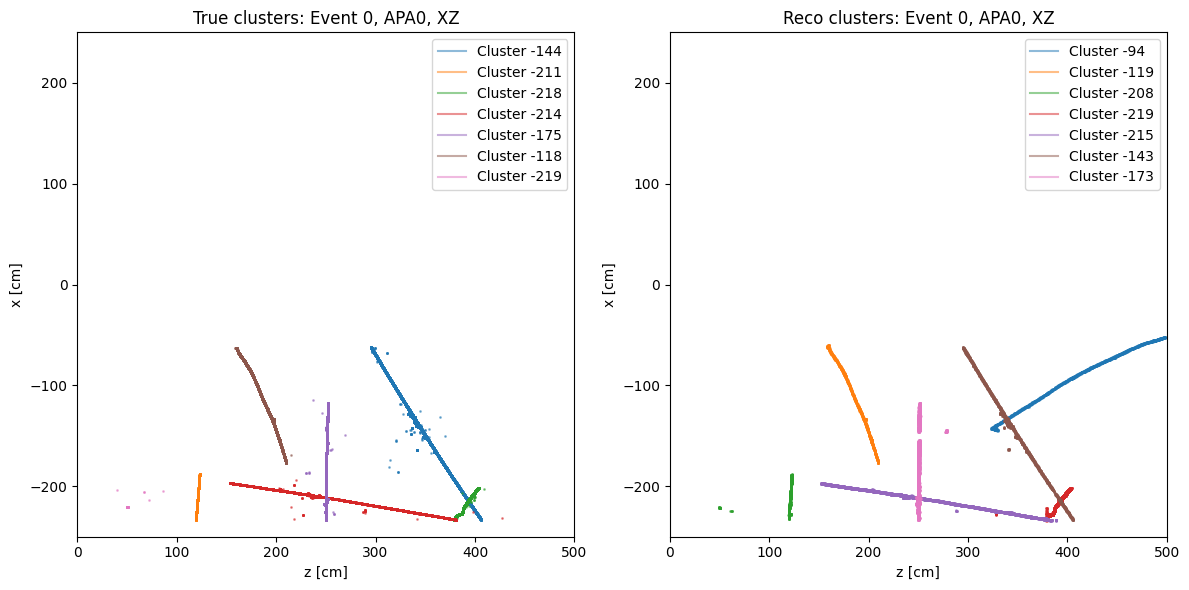

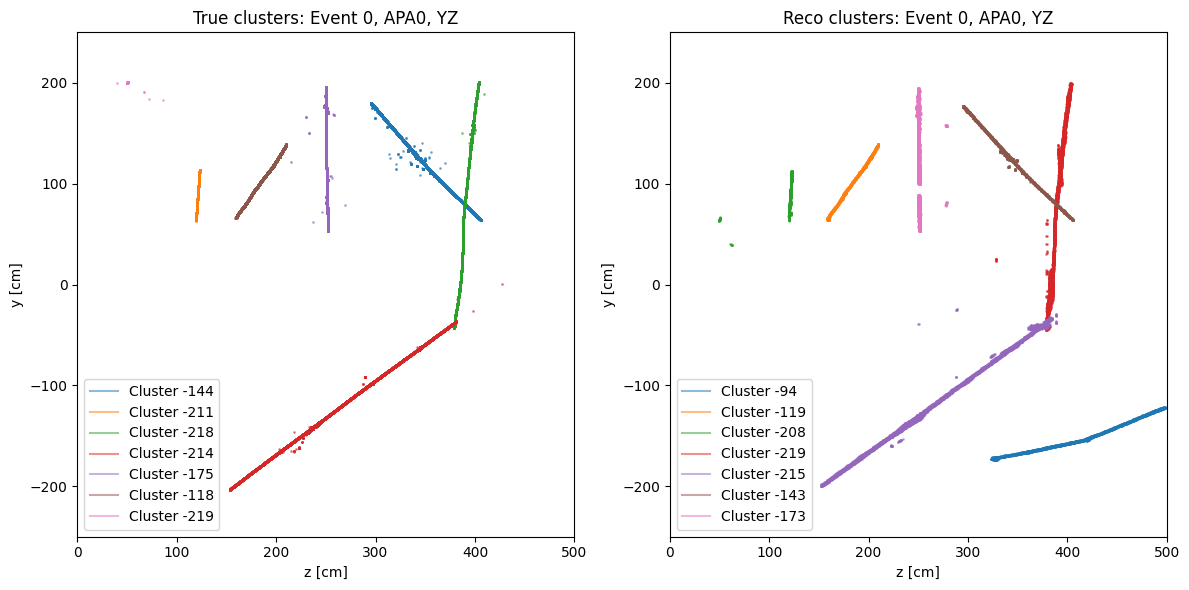

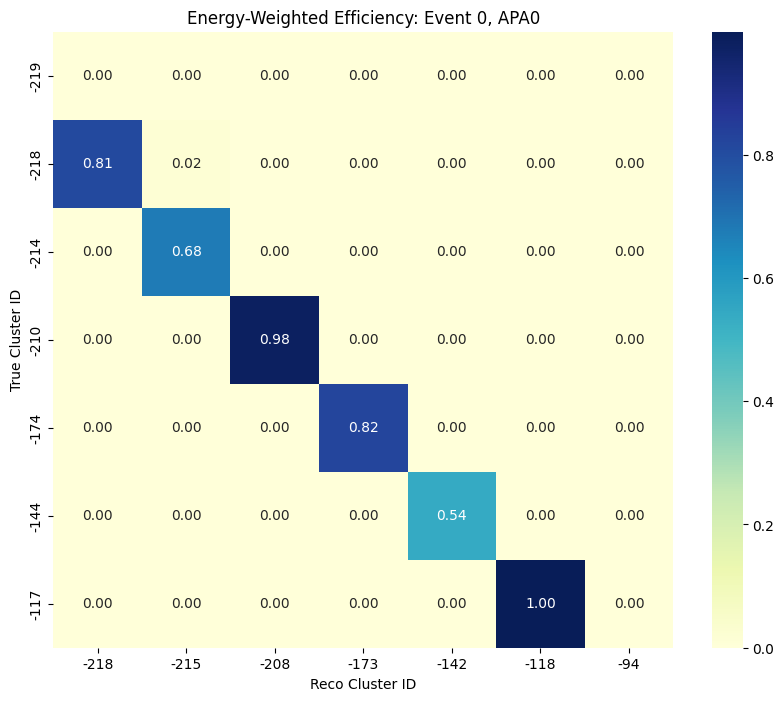

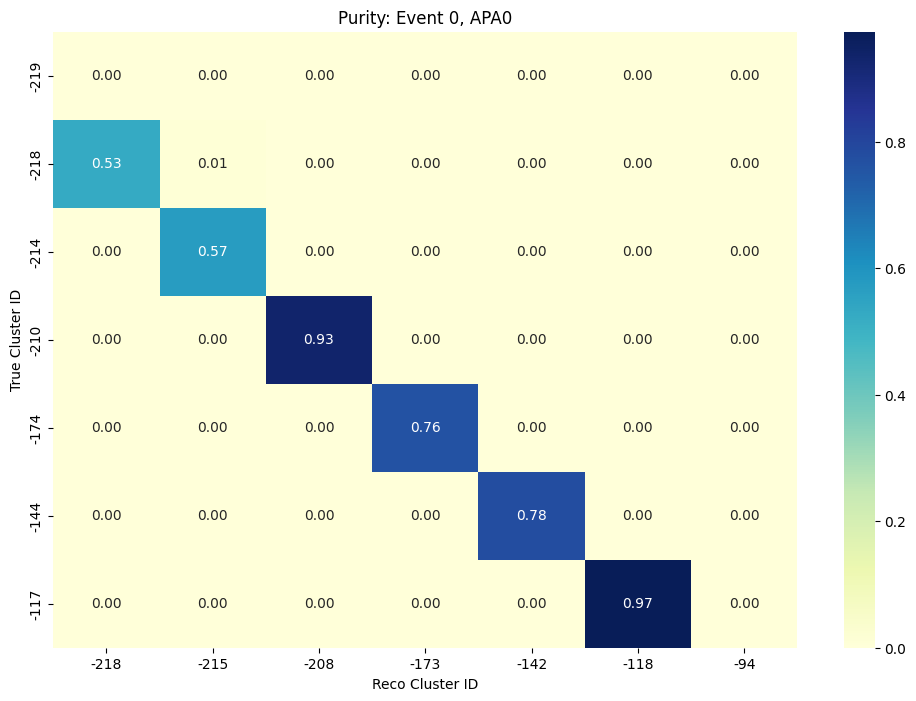

We have  6 matched pairs of true and reco clusters


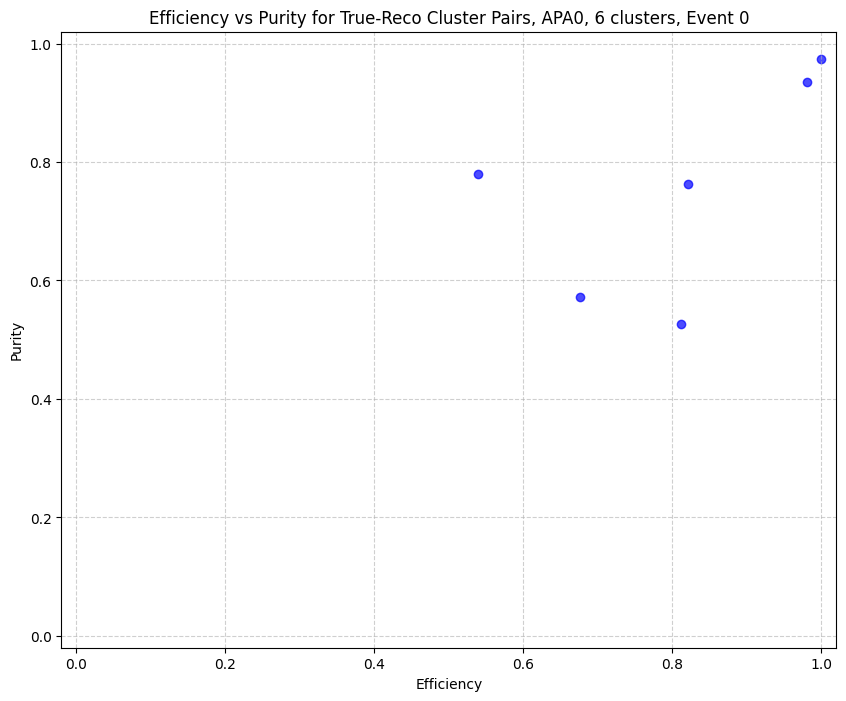

Efficiency and Purity values for each matched pair in Event 0:
True Cluster ID: -218.26, Reco Cluster ID: -218.71, Efficiency: 81.17%, Purity: 52.59%
True Cluster ID: -214.08, Reco Cluster ID: -215.4, Efficiency: 67.59%, Purity: 57.22%
True Cluster ID: -210.6, Reco Cluster ID: -208.17, Efficiency: 98.06%, Purity: 93.50%
True Cluster ID: -174.85, Reco Cluster ID: -173.22, Efficiency: 82.08%, Purity: 76.34%
True Cluster ID: -144.23, Reco Cluster ID: -142.9, Efficiency: 53.96%, Purity: 77.92%
True Cluster ID: -117.54, Reco Cluster ID: -118.61, Efficiency: 99.97%, Purity: 97.38%


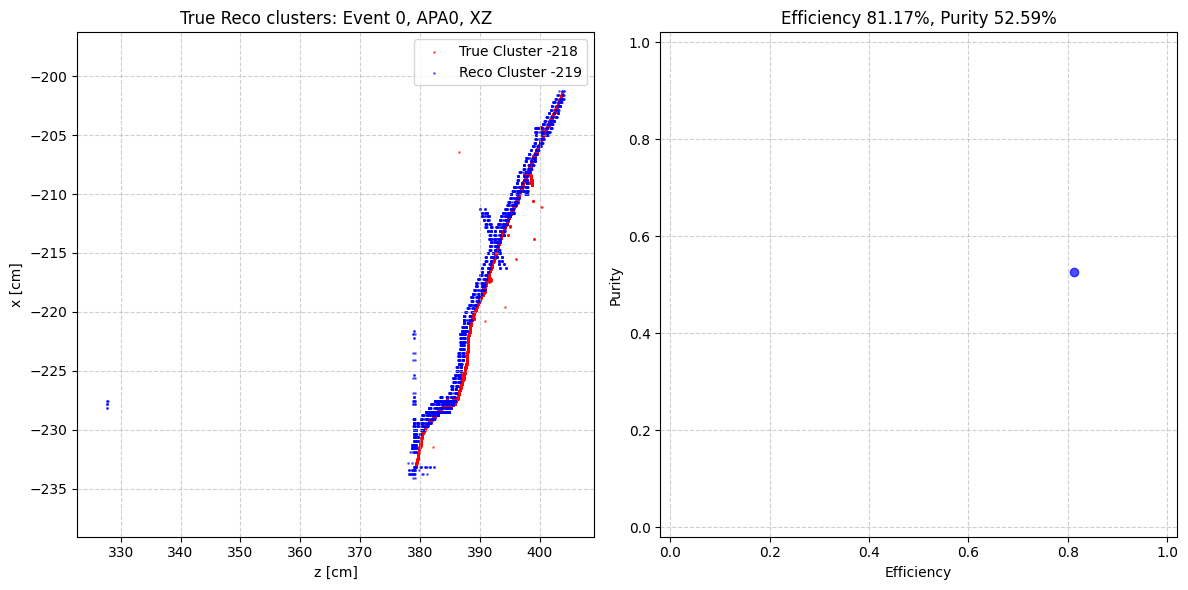

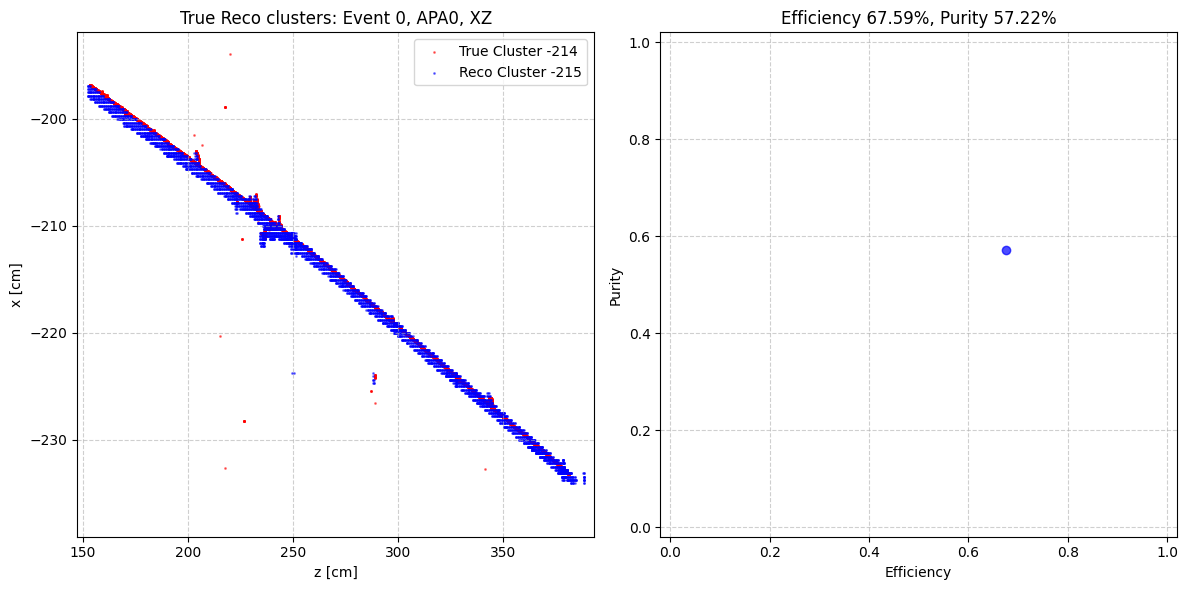

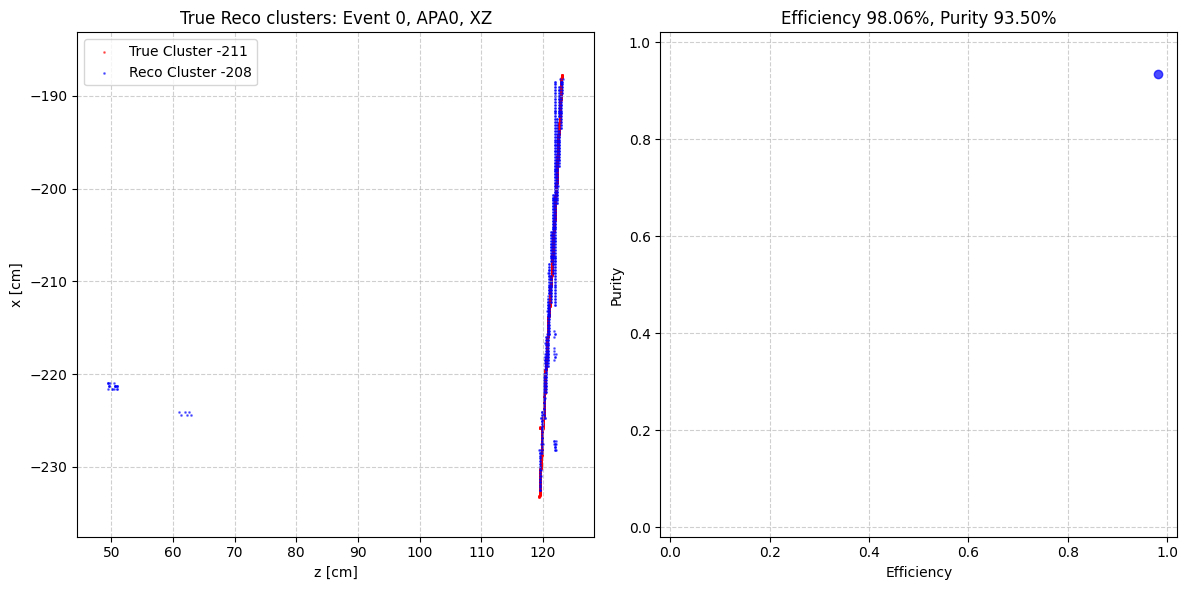

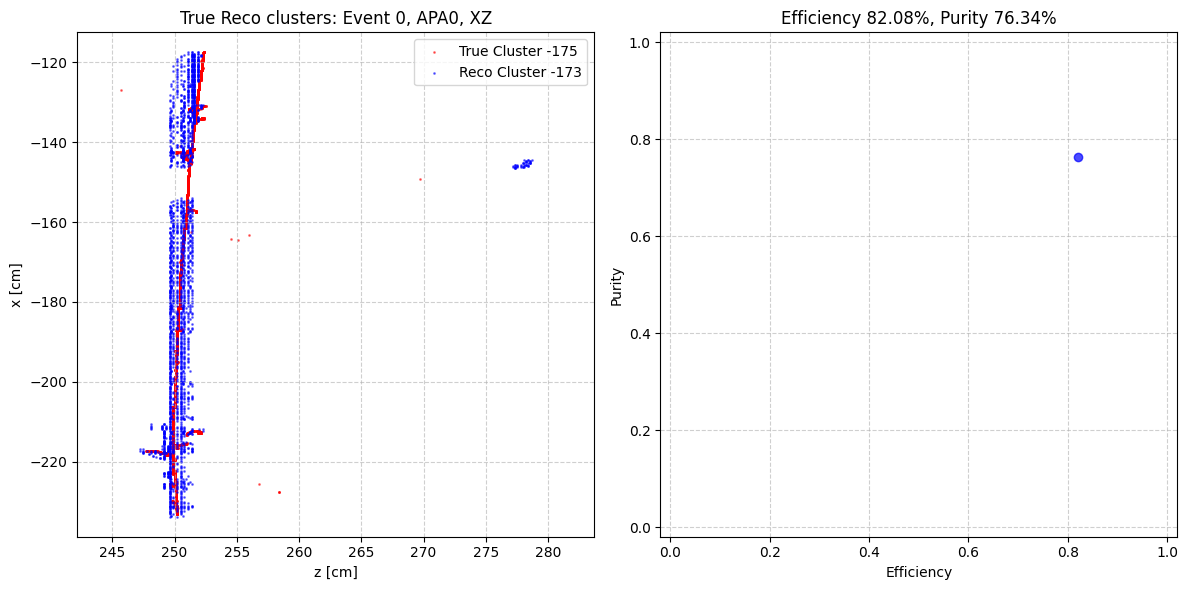

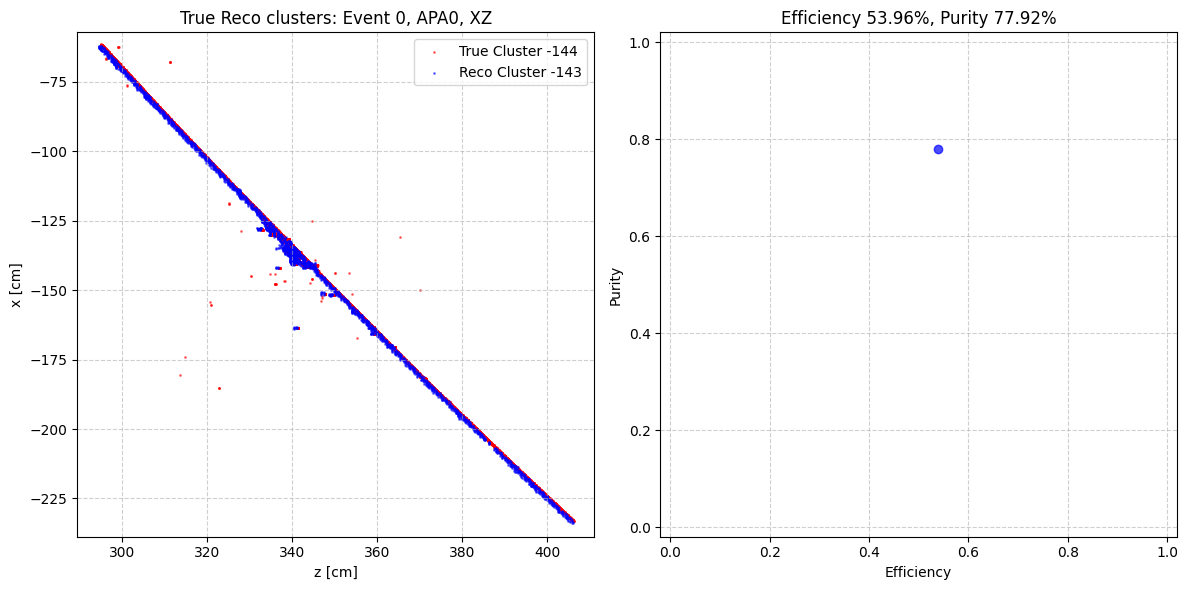

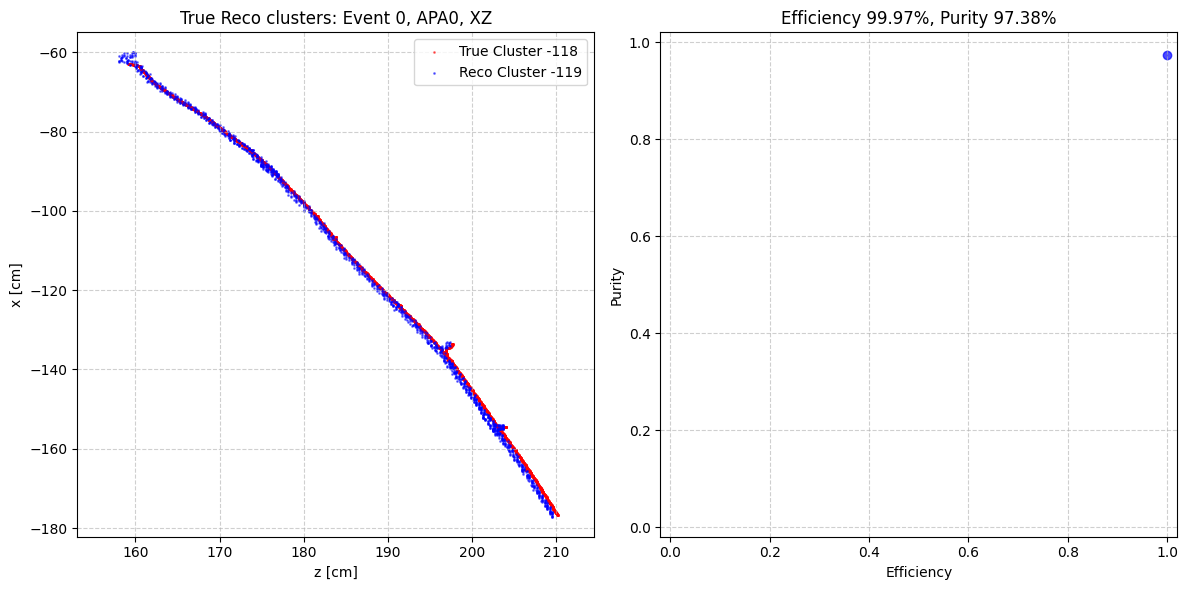



Processing event 1...
Number of true points before cosmic filter: 4102
Number of true points after cosmic filter (q_true != 1): 2439
Number of true points before energy cutoff: 2439
Number of true points after energy cutoff: 1936
Number of true points before minimum points cutoff: 1936
Number of true points after minimum points cutoff: 1928
Number of true points before fiducial volume cut: 1928
Number of true points after fiducial volume cut: 1917
Number of true clusters: 3
Number of reco points before minimum points cutoff: 1180
Number of reco points after minimum points cutoff: 670
Number of reco points before fiducial volume cut: 670
Number of reco points after fiducial volume cut: 670
Number of reco clusters: 2


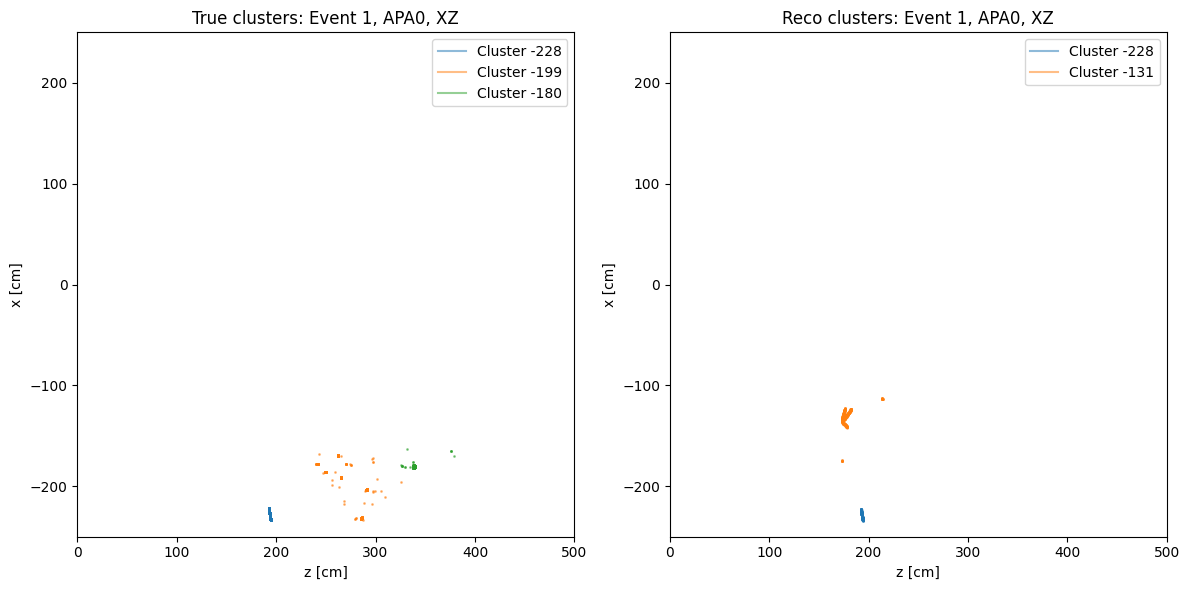

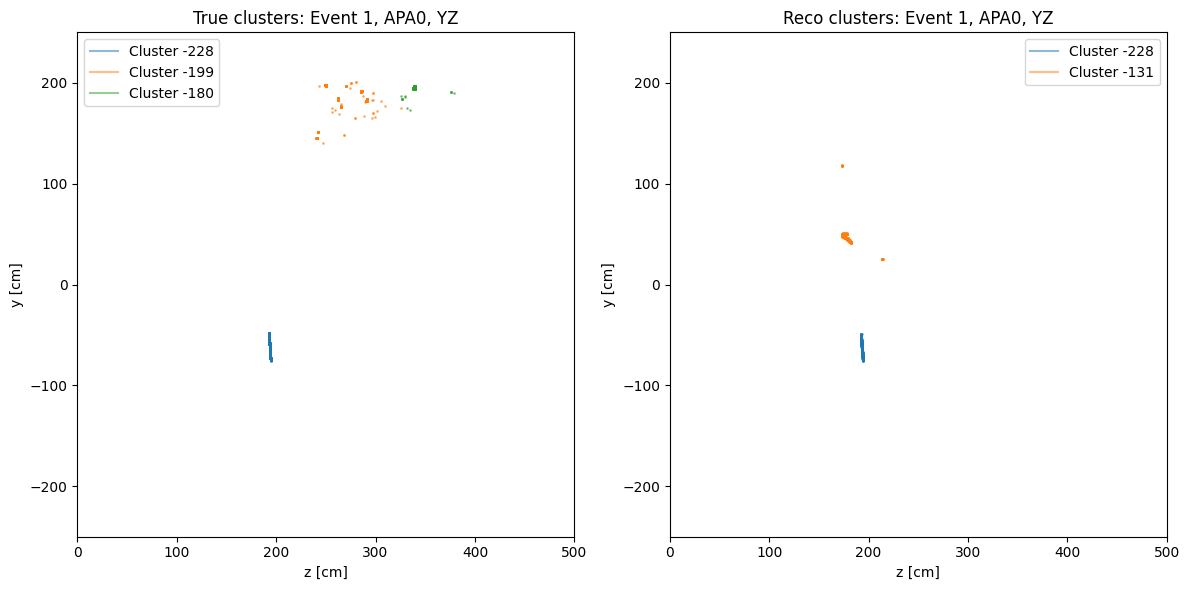

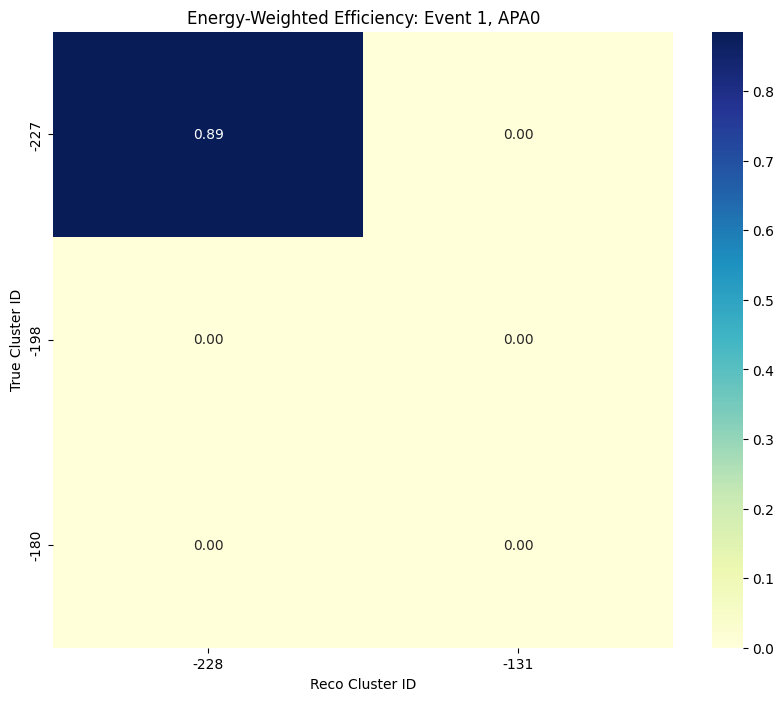

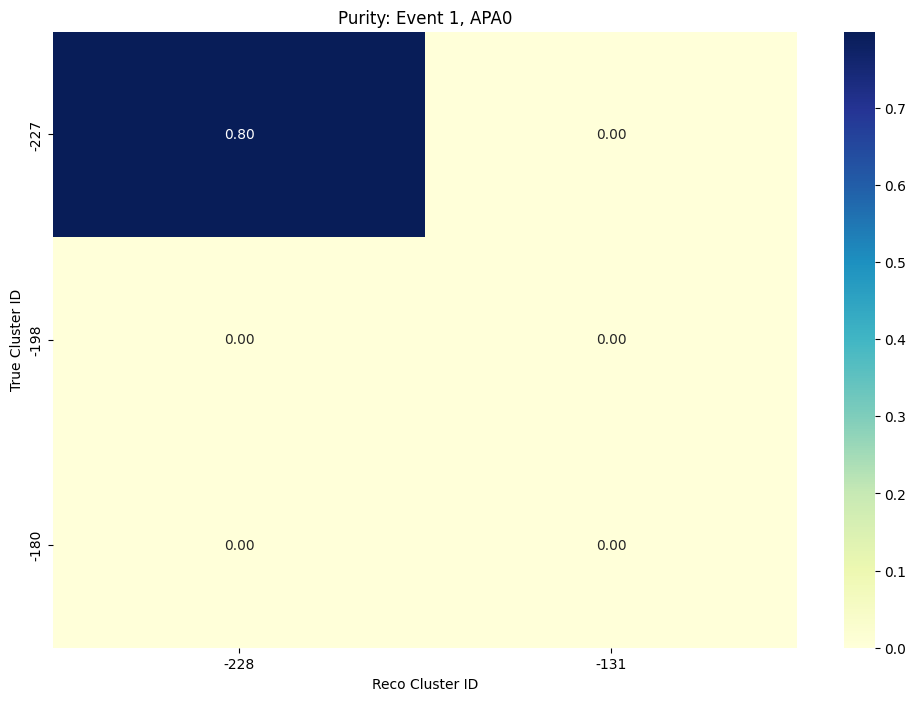

We have  1 matched pairs of true and reco clusters


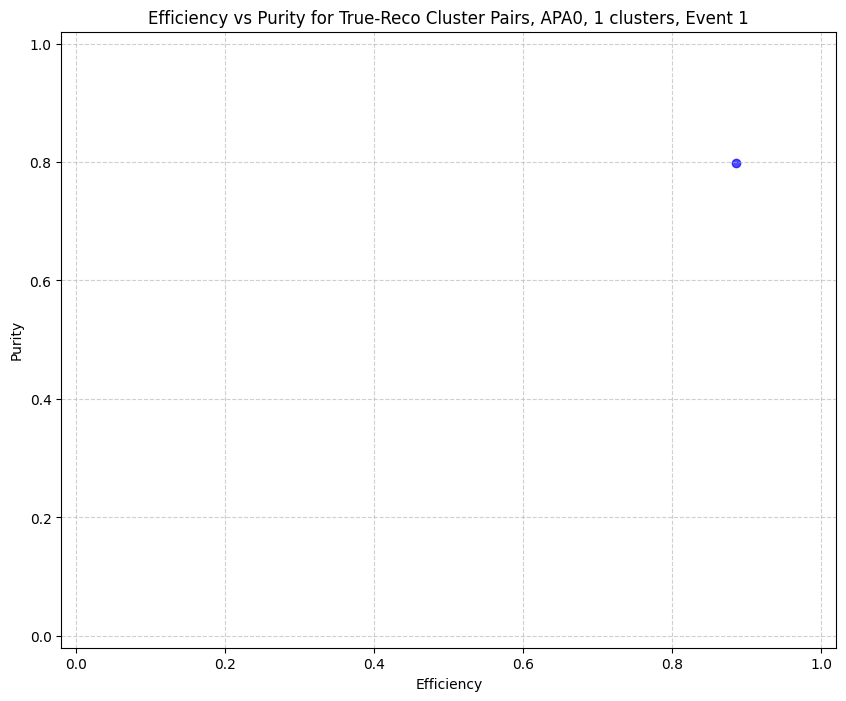

Efficiency and Purity values for each matched pair in Event 1:
True Cluster ID: -227.52, Reco Cluster ID: -228.14, Efficiency: 88.55%, Purity: 79.85%


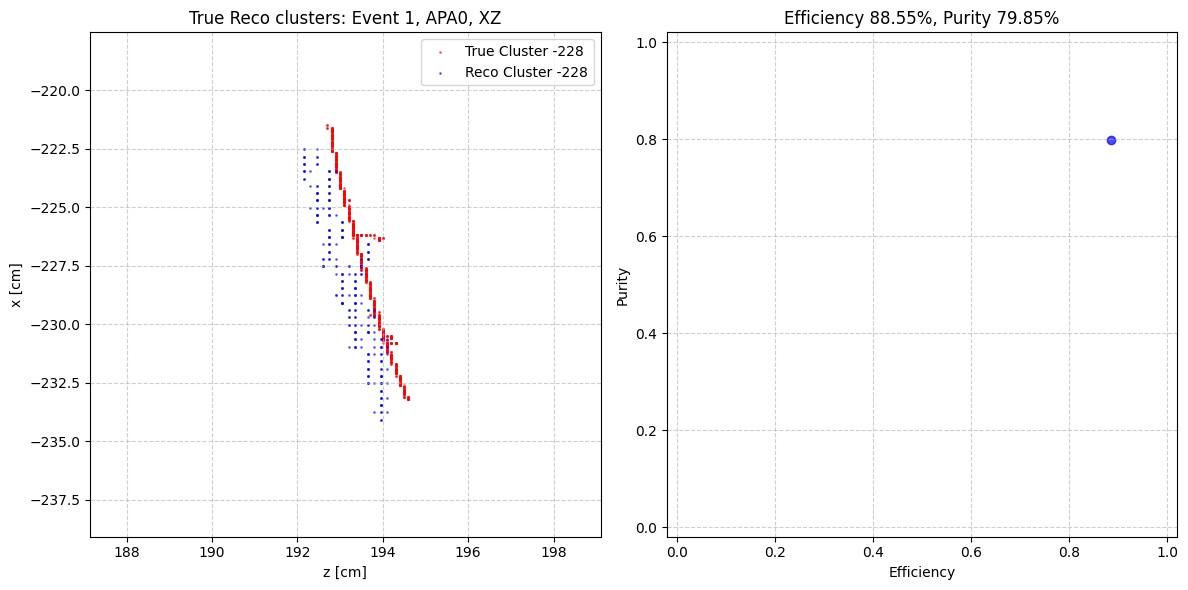



Processing event 2...
Number of true points before cosmic filter: 37888
Number of true points after cosmic filter (q_true != 1): 36492
Number of true points before energy cutoff: 36492
Number of true points after energy cutoff: 36146
Number of true points before minimum points cutoff: 36146
Number of true points after minimum points cutoff: 36146
Number of true points before fiducial volume cut: 36146
Number of true points after fiducial volume cut: 35035
Number of true clusters: 8
Number of reco points before minimum points cutoff: 10026
Number of reco points after minimum points cutoff: 9788
Number of reco points before fiducial volume cut: 9788
Number of reco points after fiducial volume cut: 9657
Number of reco clusters: 6


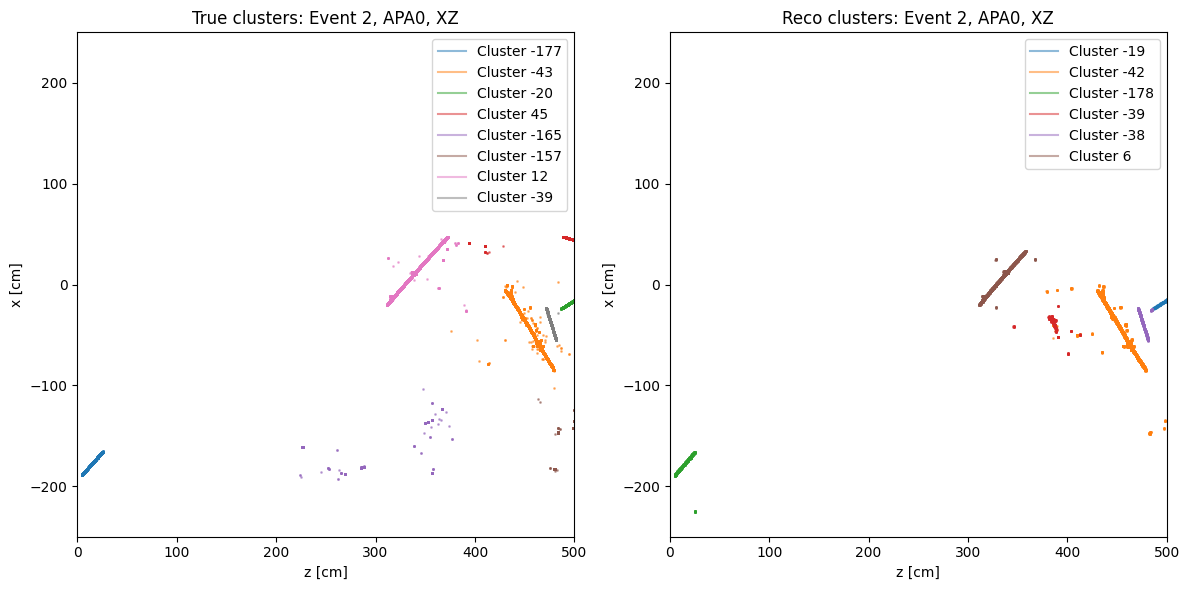

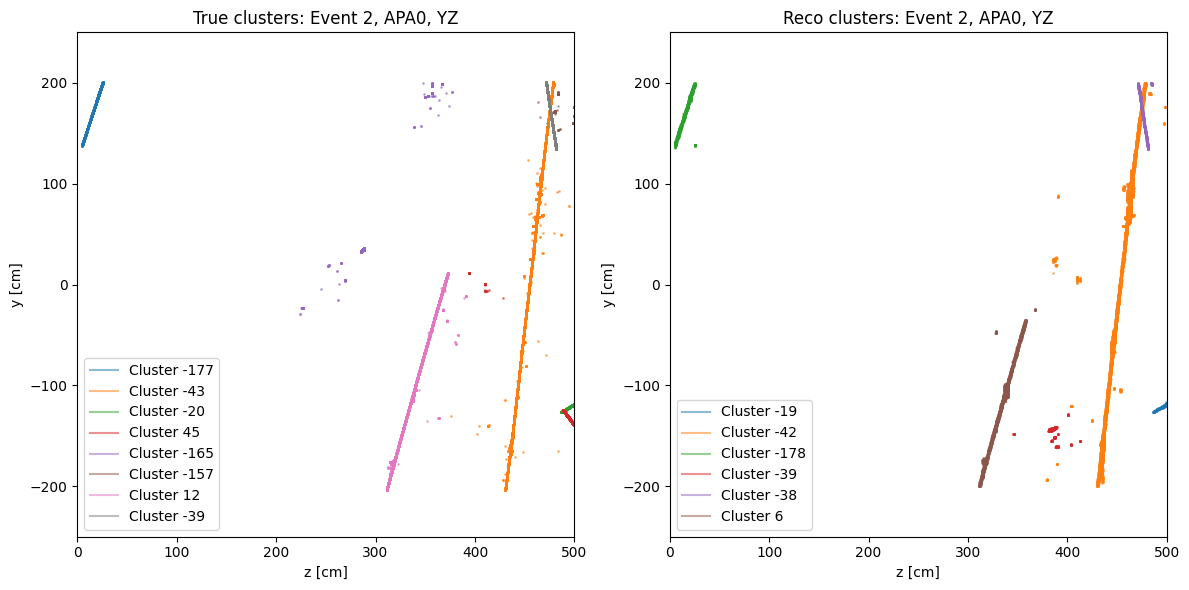

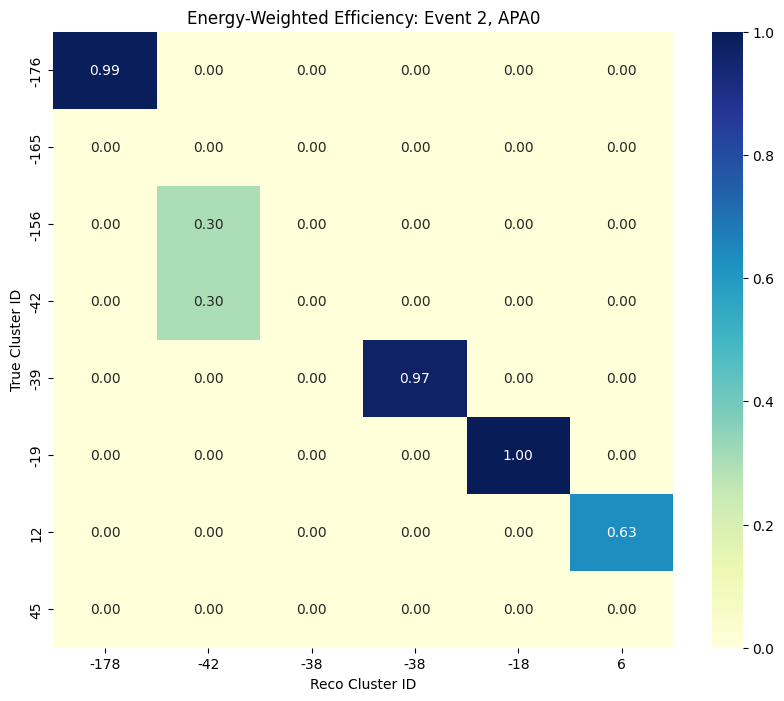

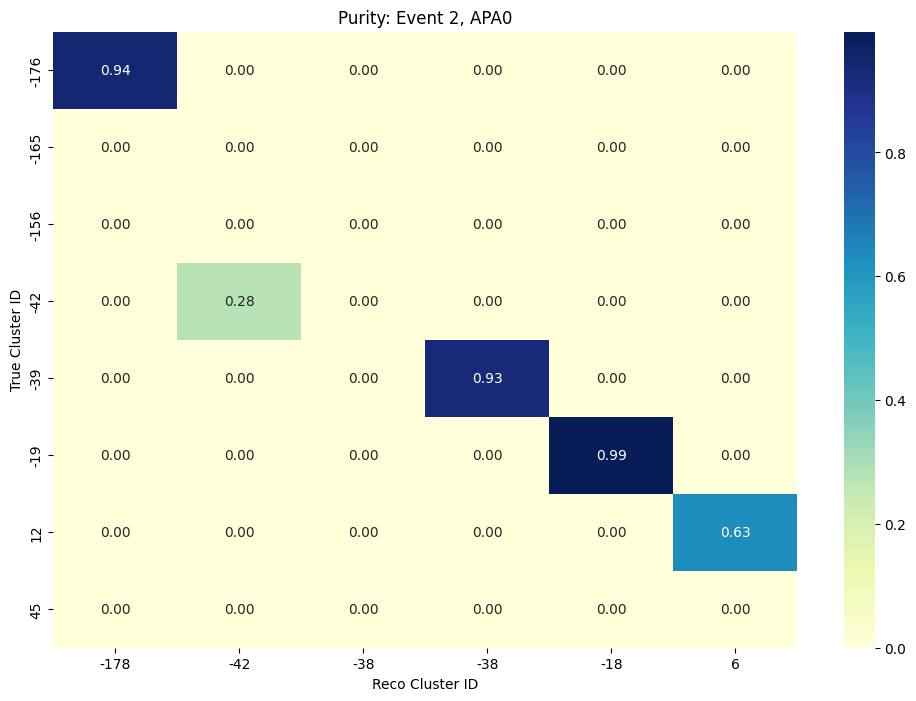

We have  5 matched pairs of true and reco clusters


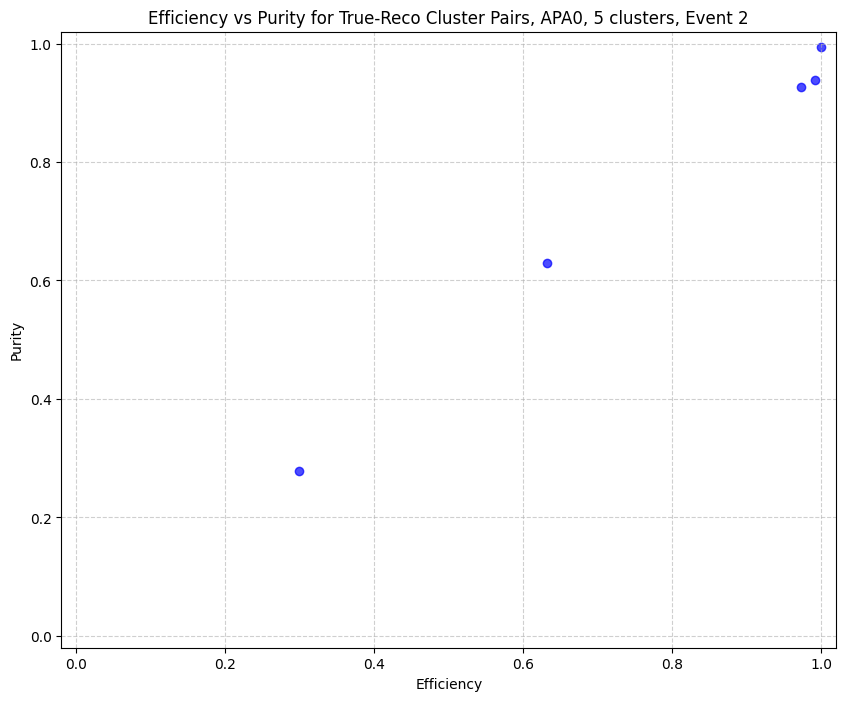

Efficiency and Purity values for each matched pair in Event 2:
True Cluster ID: -176.77, Reco Cluster ID: -178.5, Efficiency: 99.09%, Purity: 93.85%
True Cluster ID: -42.91, Reco Cluster ID: -42.35, Efficiency: 29.87%, Purity: 27.76%
True Cluster ID: -39.06, Reco Cluster ID: -38.3, Efficiency: 97.21%, Purity: 92.71%
True Cluster ID: -19.64, Reco Cluster ID: -18.77, Efficiency: 100.00%, Purity: 99.49%
True Cluster ID: 12.13, Reco Cluster ID: 6.3, Efficiency: 63.15%, Purity: 63.02%


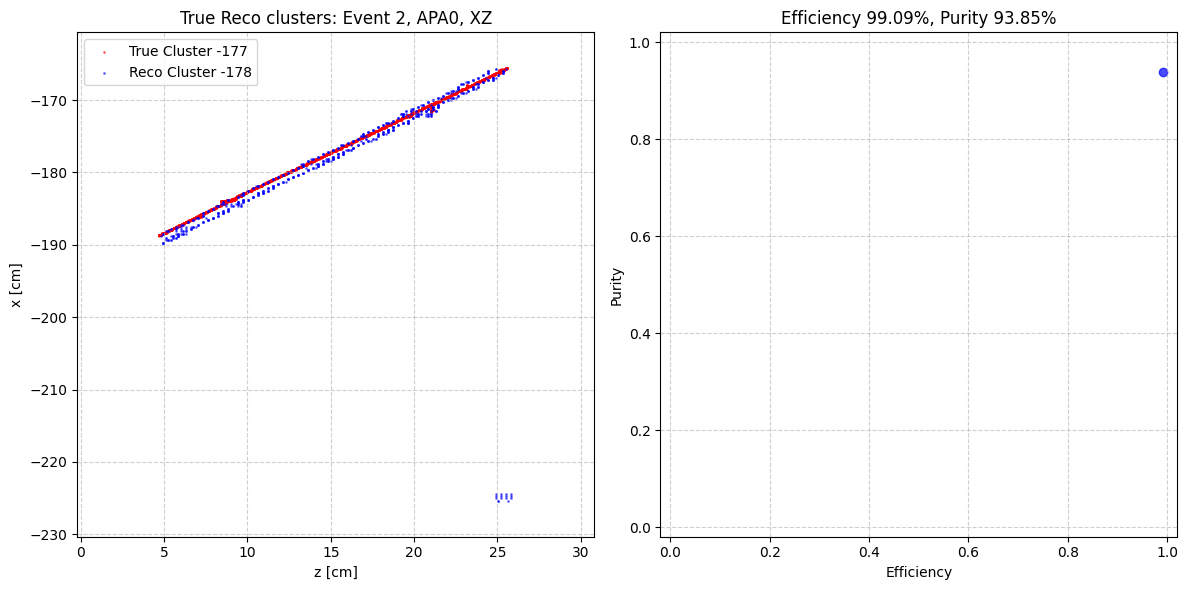

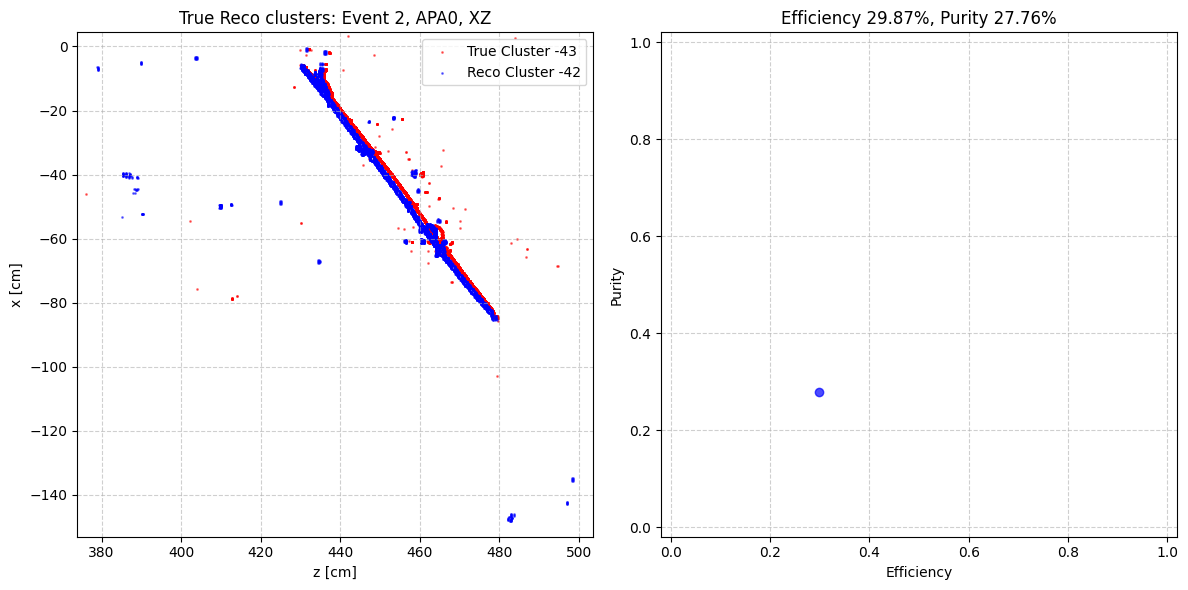

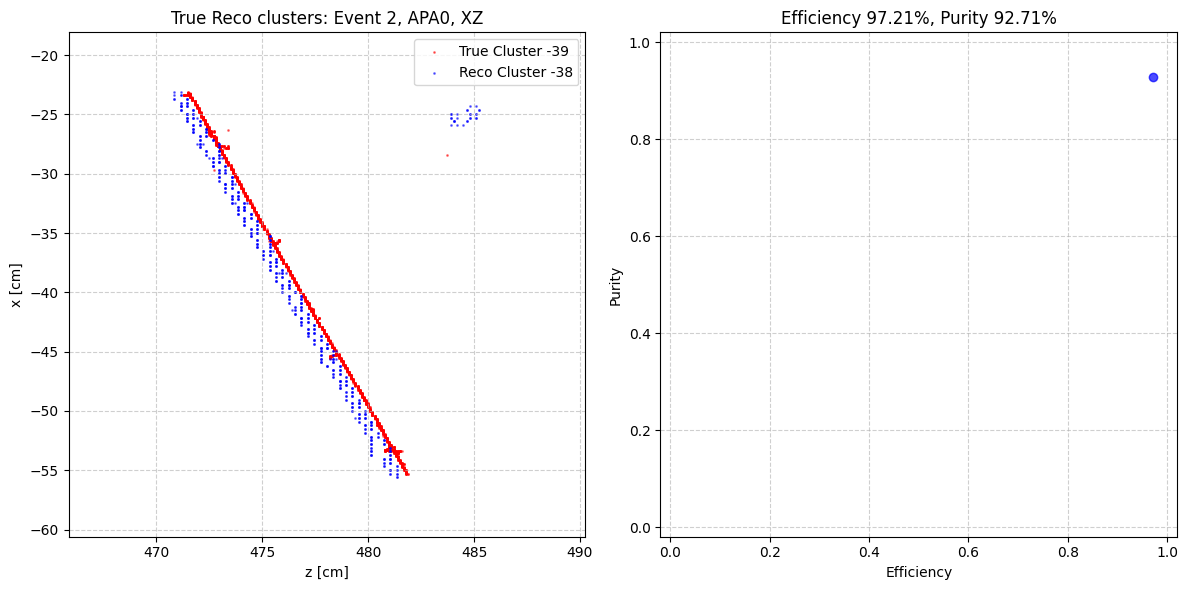

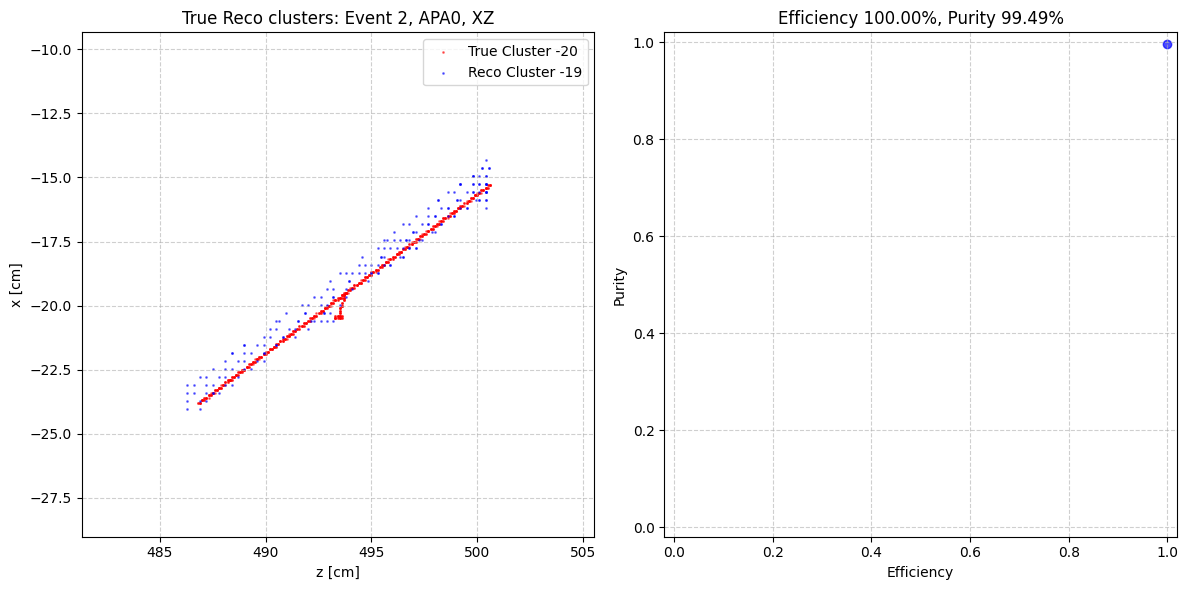

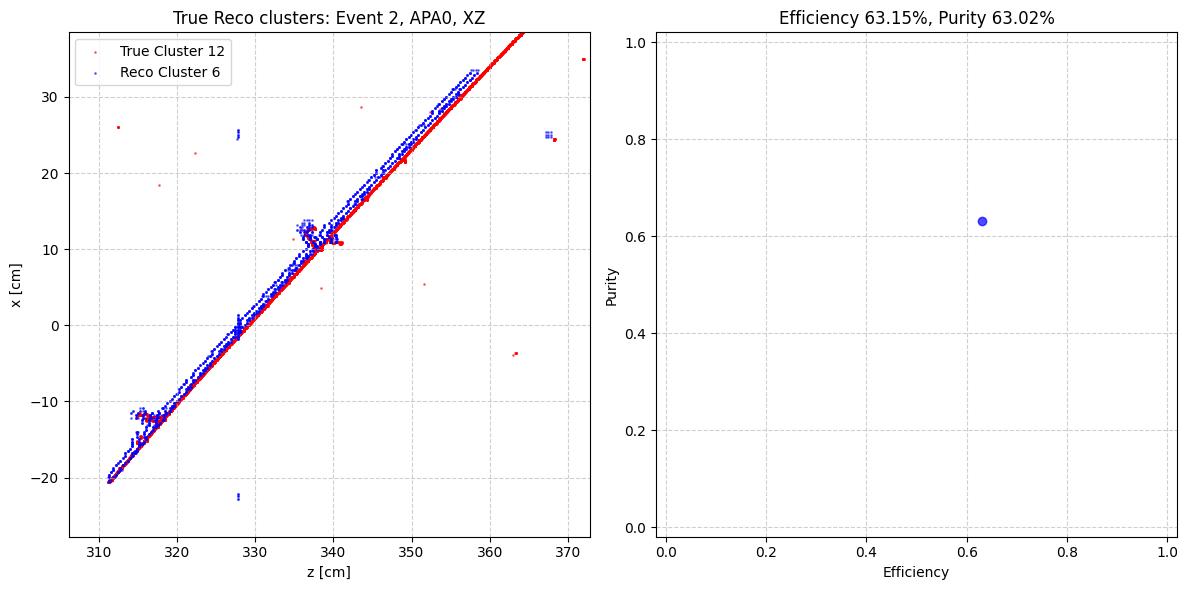



Processing event 3...
Number of true points before cosmic filter: 45974
Number of true points after cosmic filter (q_true != 1): 45809
Number of true points before energy cutoff: 45809
Number of true points after energy cutoff: 45691
Number of true points before minimum points cutoff: 45691
Number of true points after minimum points cutoff: 45684
Number of true points before fiducial volume cut: 45684
Number of true points after fiducial volume cut: 44953
Number of true clusters: 8
Number of reco points before minimum points cutoff: 12135
Number of reco points after minimum points cutoff: 12046
Number of reco points before fiducial volume cut: 12046
Number of reco points after fiducial volume cut: 11886
Number of reco clusters: 6


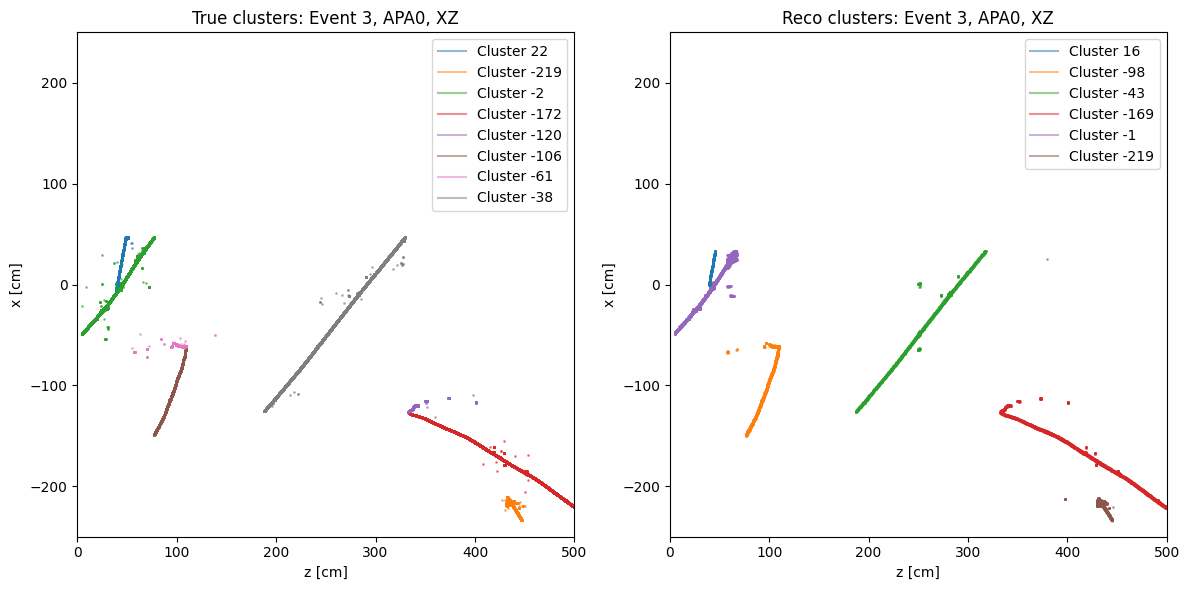

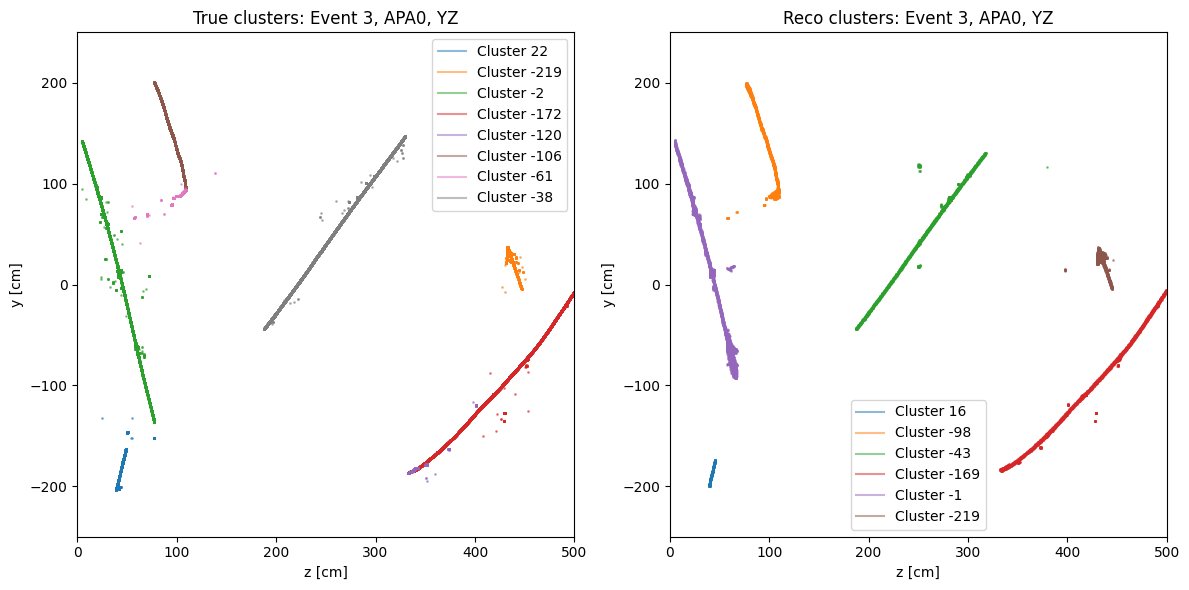

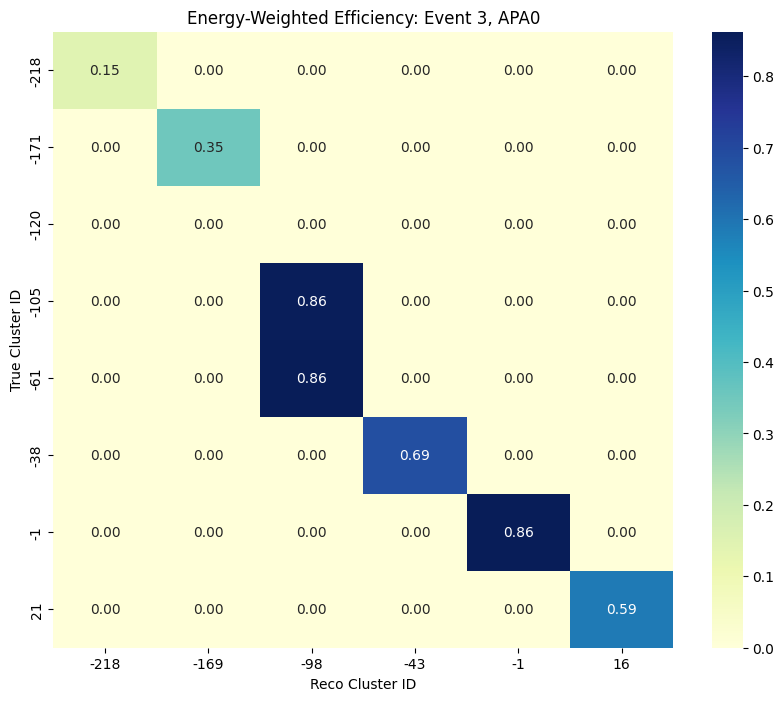

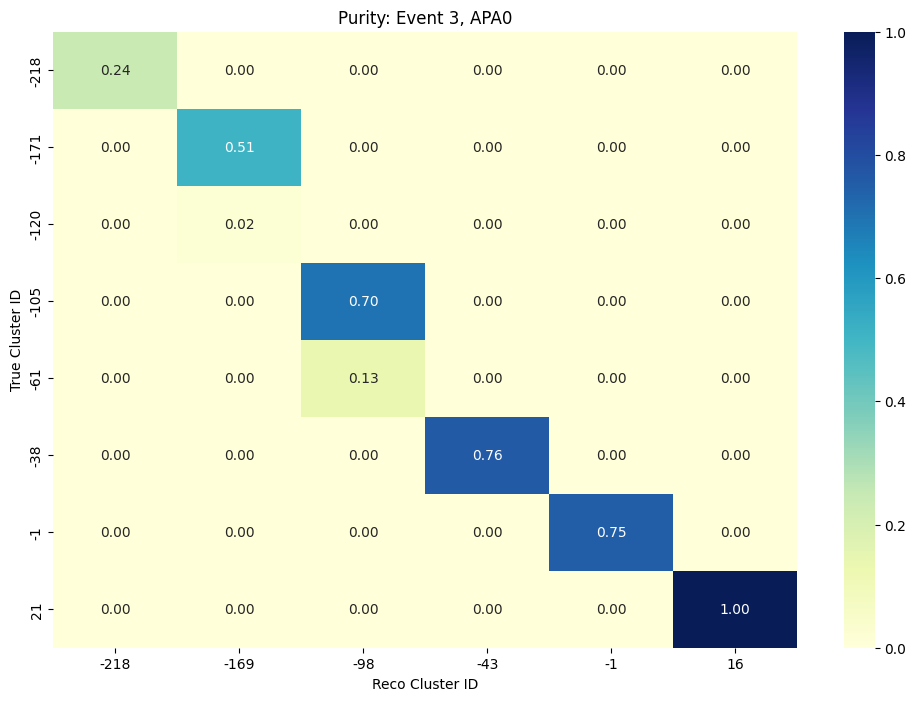

We have  6 matched pairs of true and reco clusters


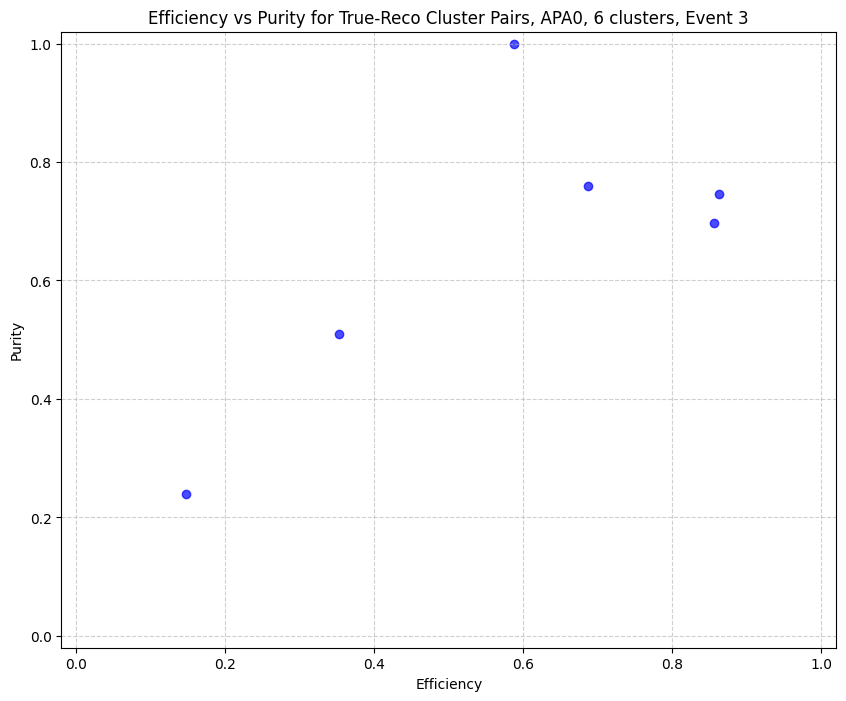

Efficiency and Purity values for each matched pair in Event 3:
True Cluster ID: -218.94, Reco Cluster ID: -218.87, Efficiency: 14.73%, Purity: 23.90%
True Cluster ID: -171.54, Reco Cluster ID: -169.17, Efficiency: 35.24%, Purity: 51.04%
True Cluster ID: -105.88, Reco Cluster ID: -98.45, Efficiency: 85.64%, Purity: 69.73%
True Cluster ID: -38.27, Reco Cluster ID: -43.26, Efficiency: 68.66%, Purity: 76.02%
True Cluster ID: -1.84, Reco Cluster ID: -1.43, Efficiency: 86.25%, Purity: 74.65%
True Cluster ID: 21.59, Reco Cluster ID: 16.32, Efficiency: 58.76%, Purity: 100.00%


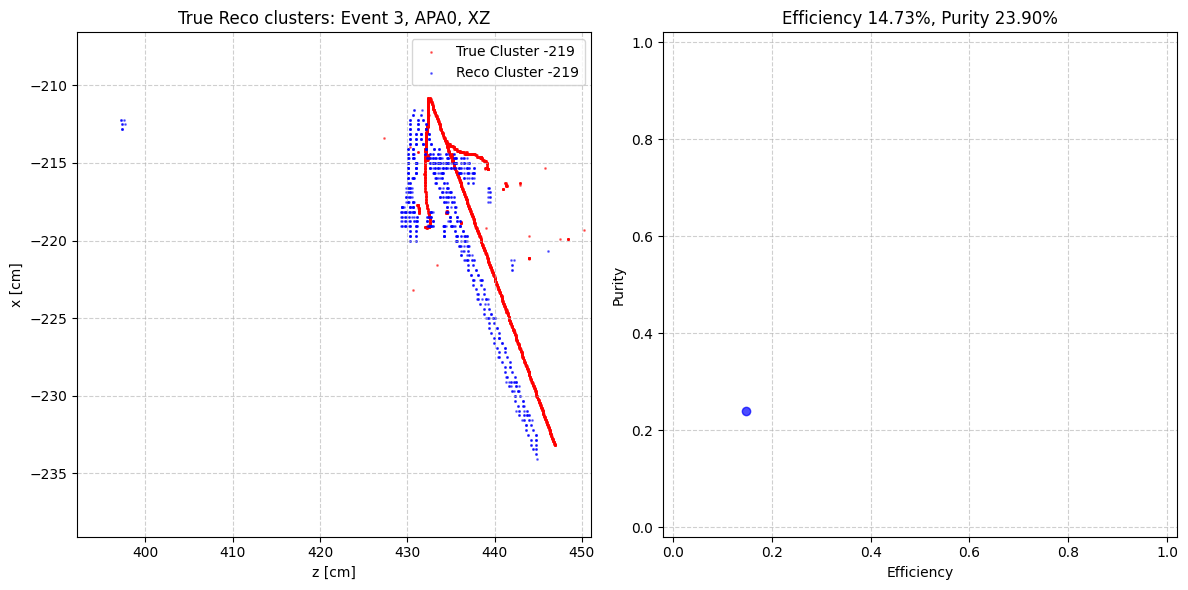

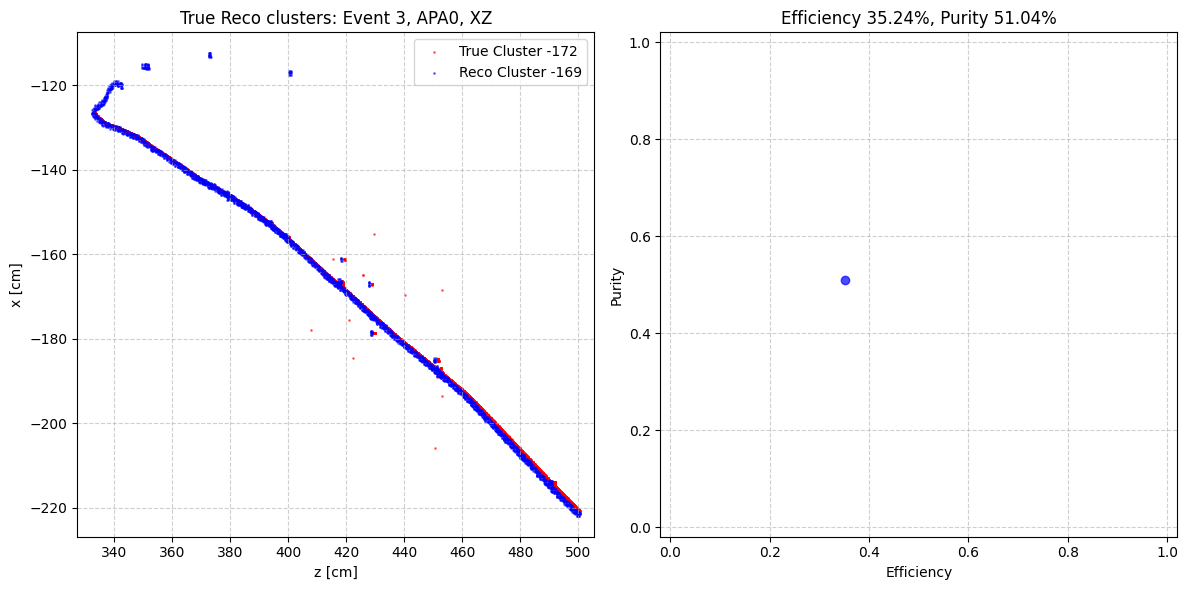

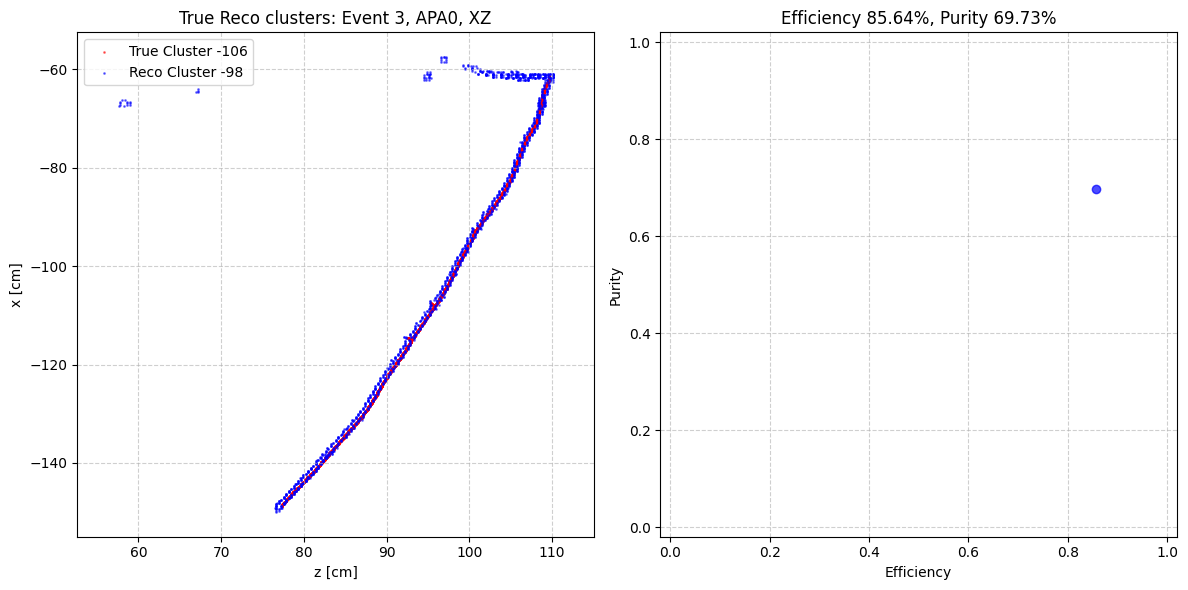

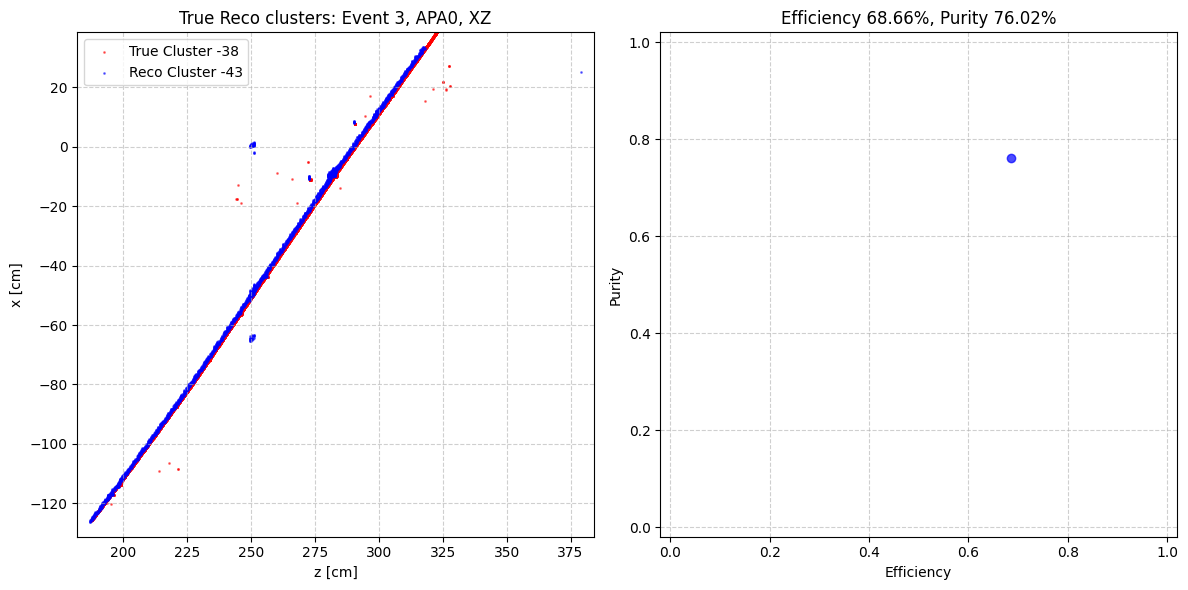

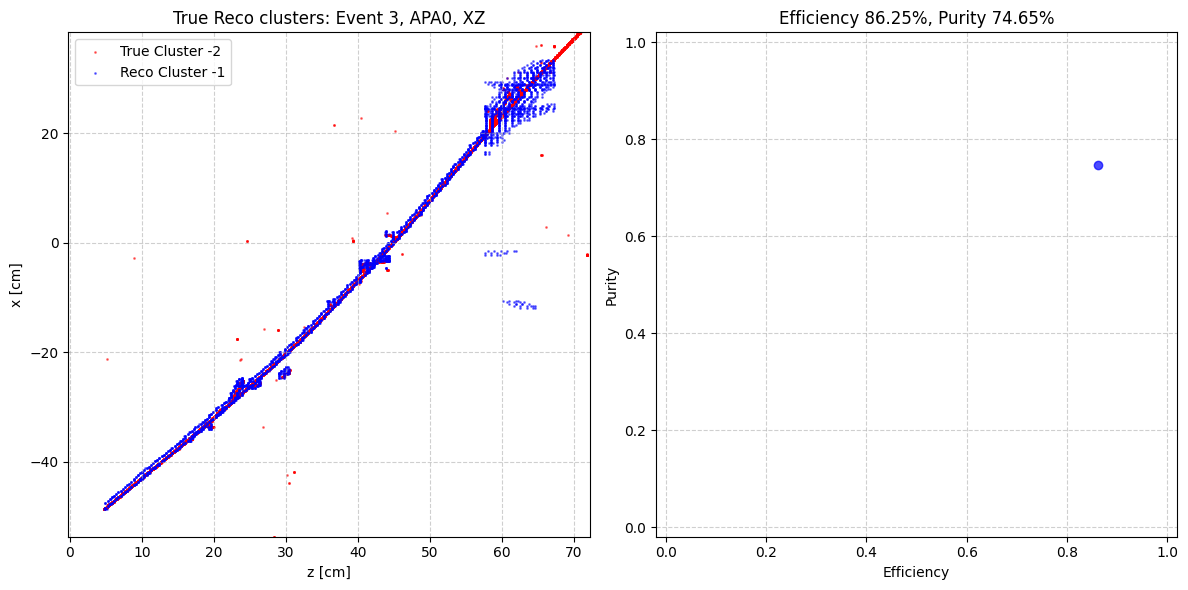

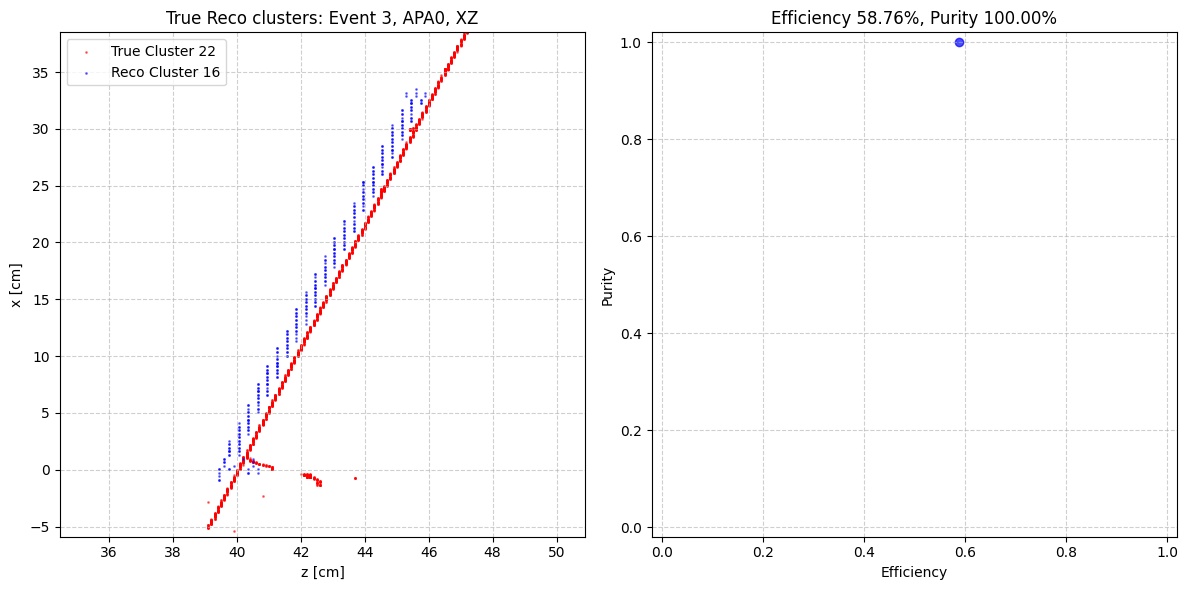



Processing event 4...
Number of true points before cosmic filter: 25175
Number of true points after cosmic filter (q_true != 1): 25175
Number of true points before energy cutoff: 25175
Number of true points after energy cutoff: 24908
Number of true points before minimum points cutoff: 24908
Number of true points after minimum points cutoff: 24908
Number of true points before fiducial volume cut: 24908
Number of true points after fiducial volume cut: 24628
Number of true clusters: 3
Number of reco points before minimum points cutoff: 10273
Number of reco points after minimum points cutoff: 10199
Number of reco points before fiducial volume cut: 10199
Number of reco points after fiducial volume cut: 10182
Number of reco clusters: 3


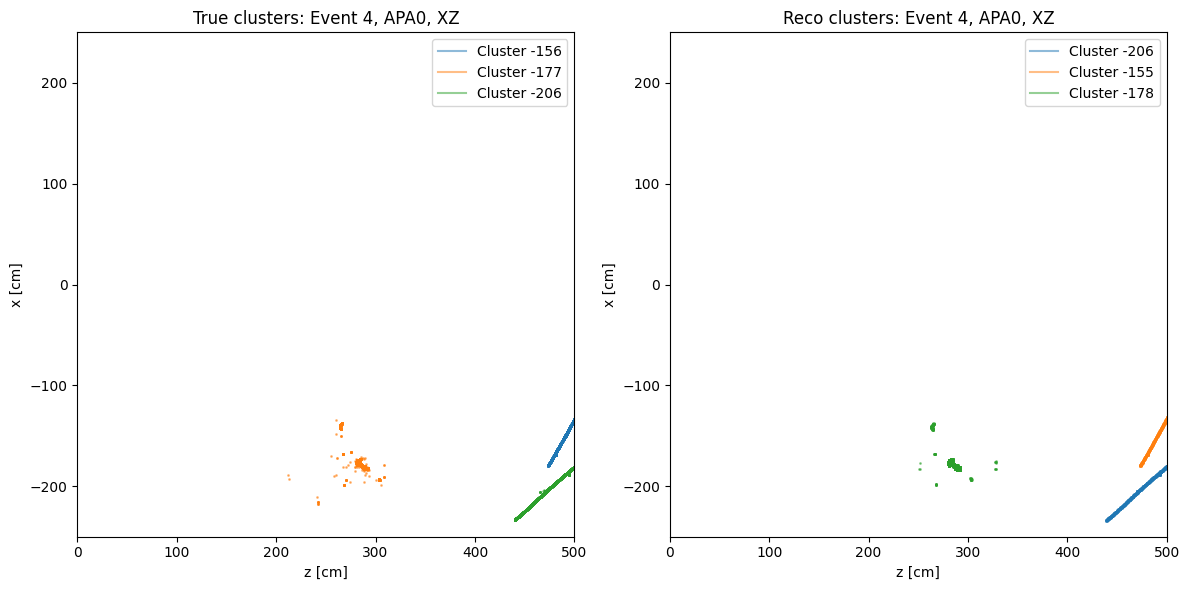

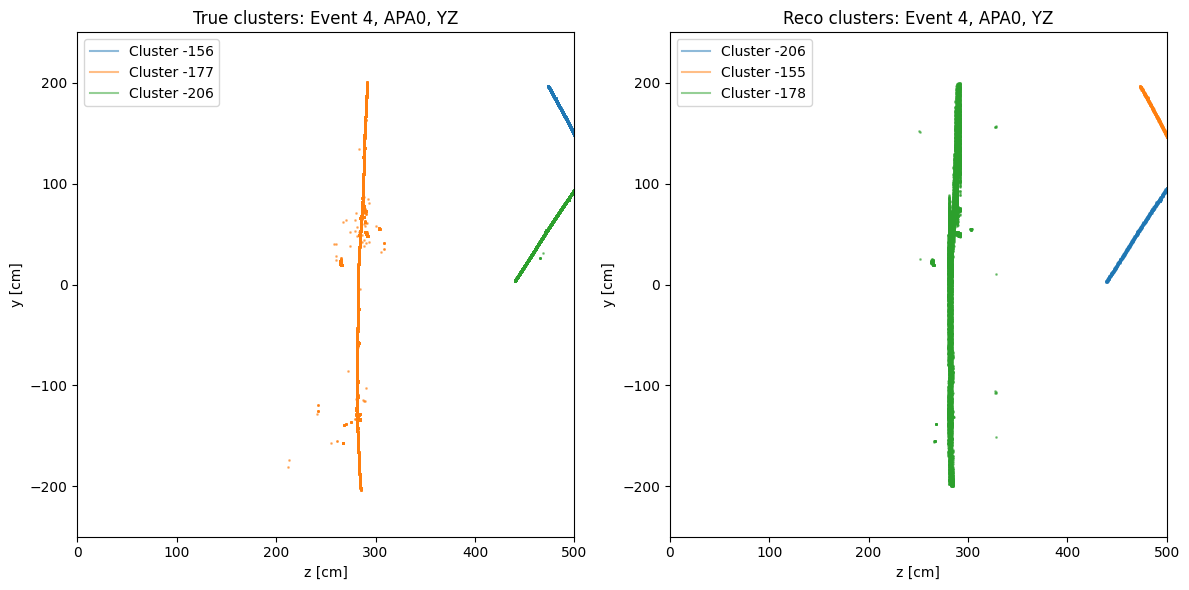

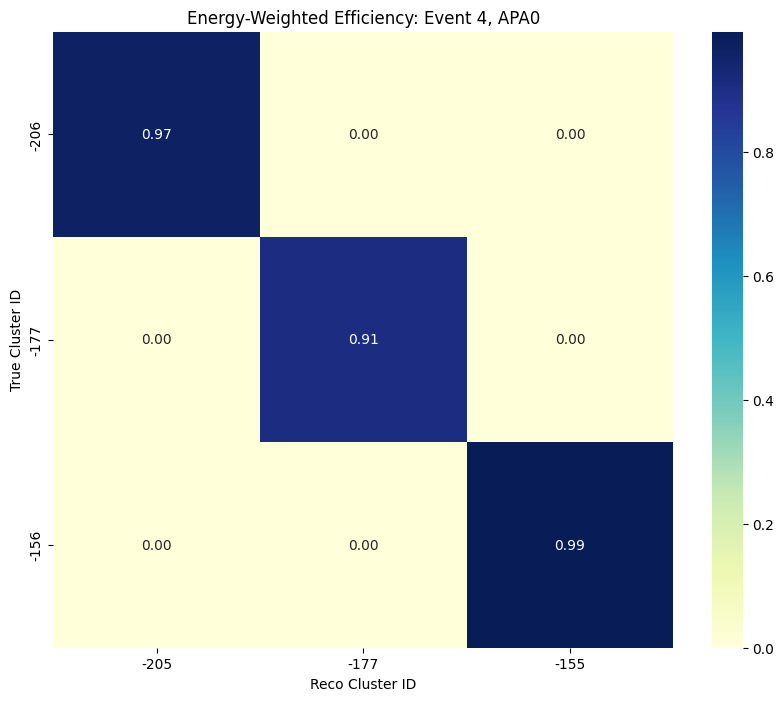

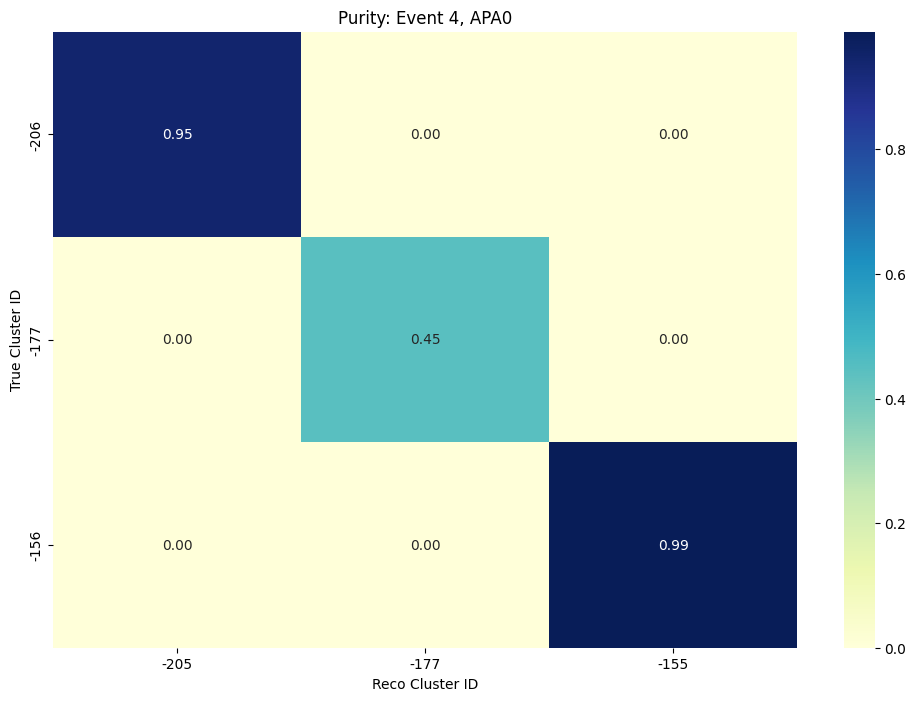

We have  3 matched pairs of true and reco clusters


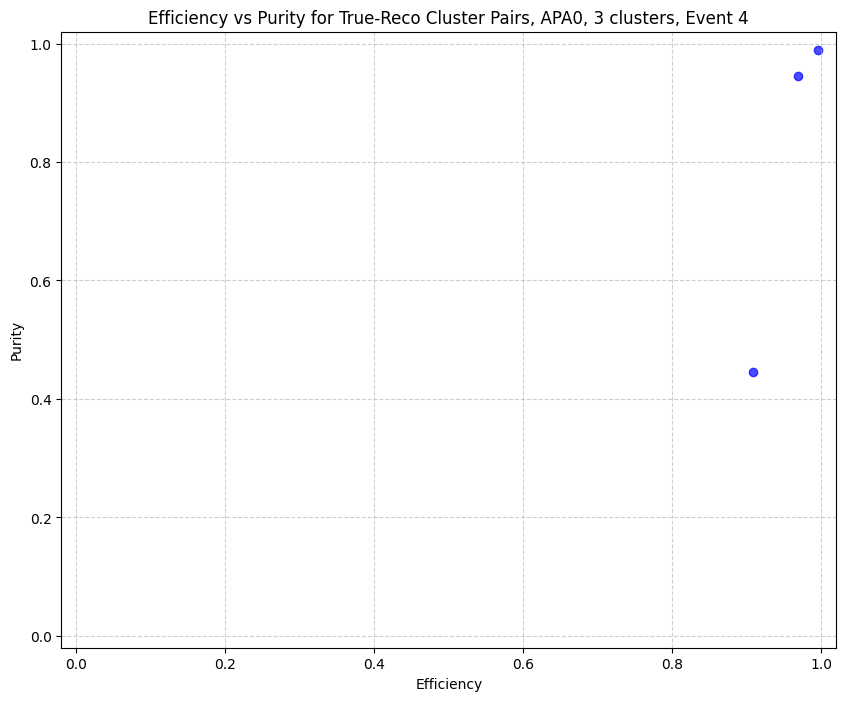

Efficiency and Purity values for each matched pair in Event 4:
True Cluster ID: -206.09, Reco Cluster ID: -205.87, Efficiency: 96.83%, Purity: 94.54%
True Cluster ID: -177.28, Reco Cluster ID: -177.83, Efficiency: 90.79%, Purity: 44.59%
True Cluster ID: -156.07, Reco Cluster ID: -155.4, Efficiency: 99.48%, Purity: 98.88%


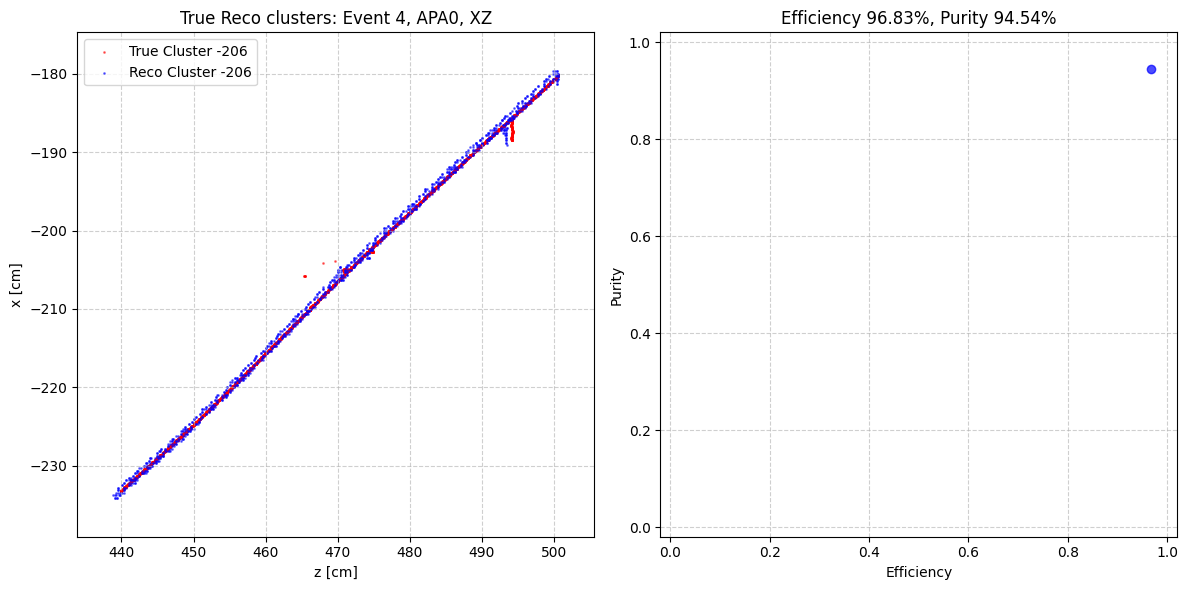

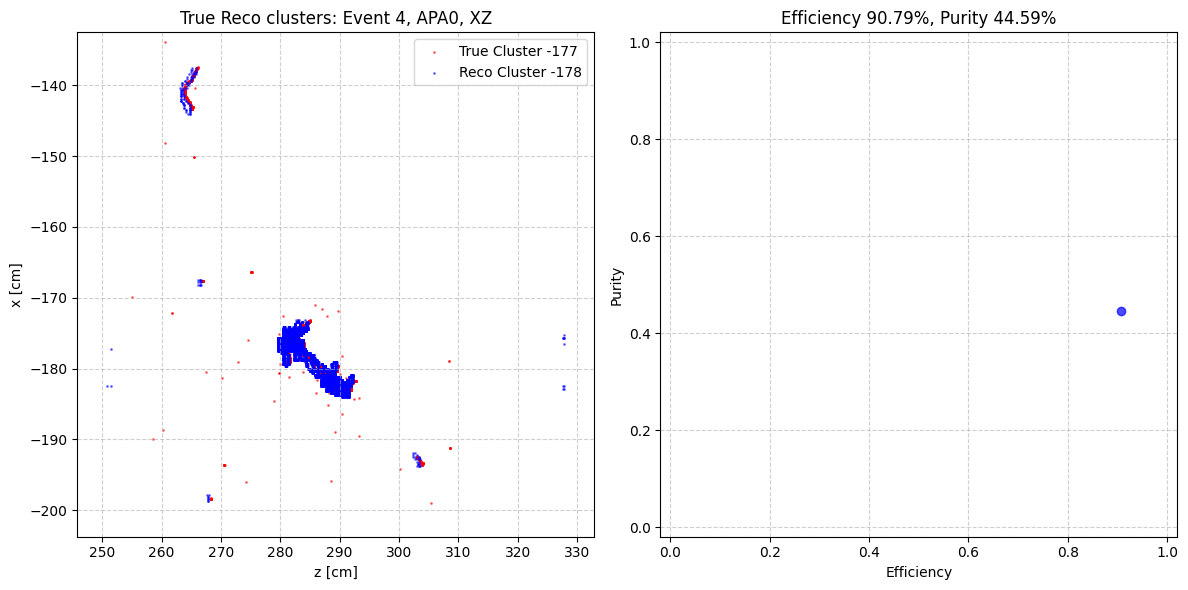

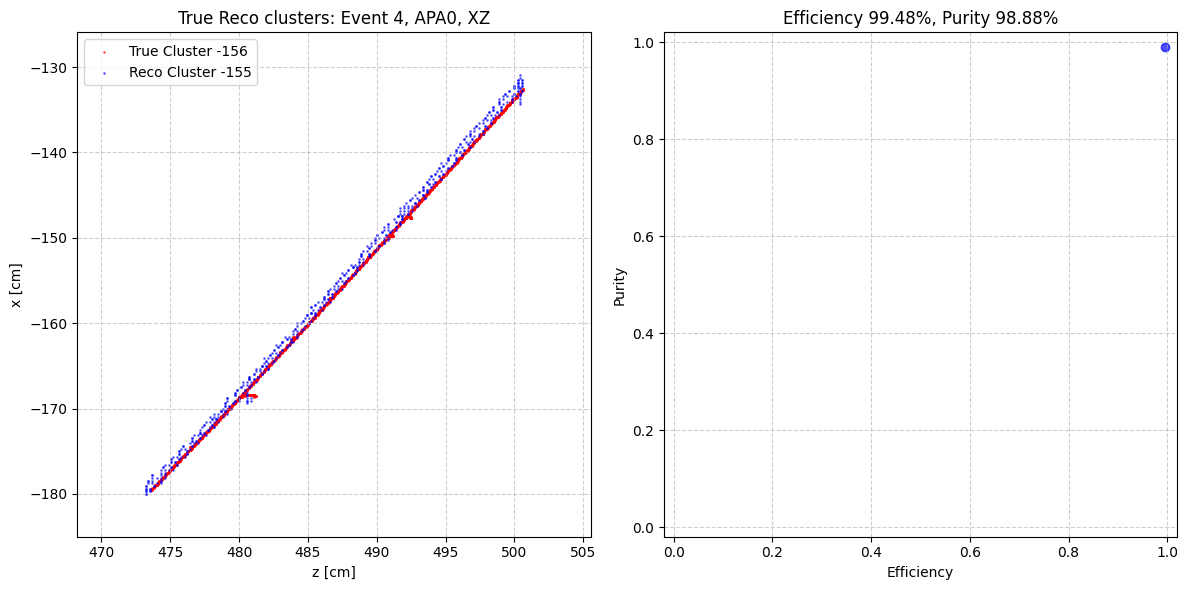



Processing event 5...
Number of true points before cosmic filter: 40566
Number of true points after cosmic filter (q_true != 1): 33578
Number of true points before energy cutoff: 33578
Number of true points after energy cutoff: 33143
Number of true points before minimum points cutoff: 33143
Number of true points after minimum points cutoff: 33099
Number of true points before fiducial volume cut: 33099
Number of true points after fiducial volume cut: 32408
Number of true clusters: 7
Number of reco points before minimum points cutoff: 28493
Number of reco points after minimum points cutoff: 28240
Number of reco points before fiducial volume cut: 28240
Number of reco points after fiducial volume cut: 28240
Number of reco clusters: 6


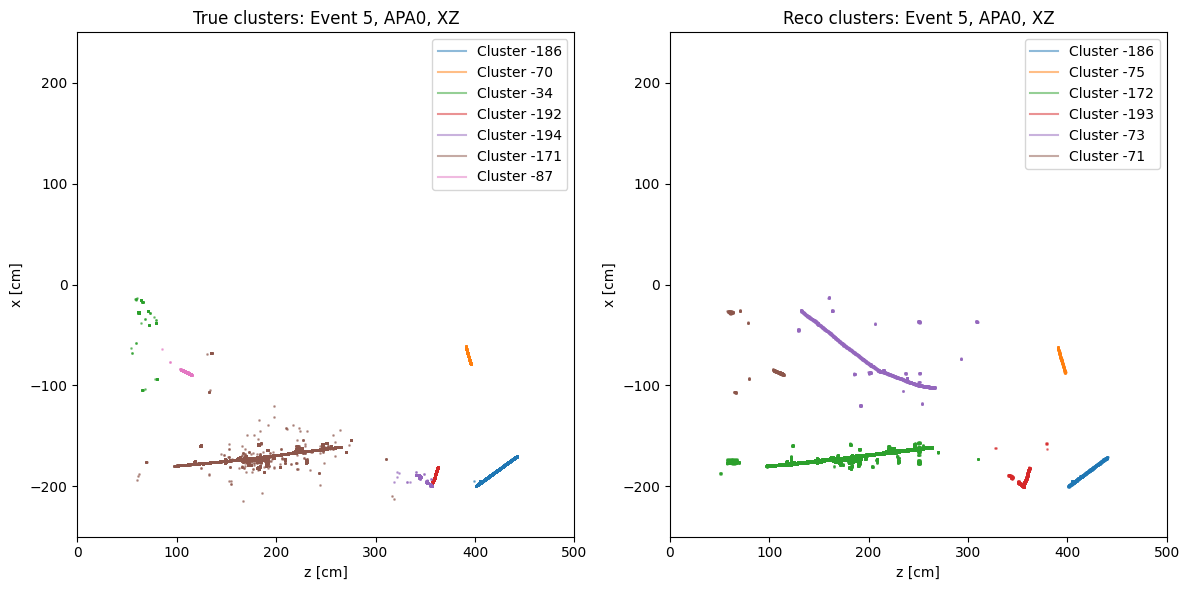

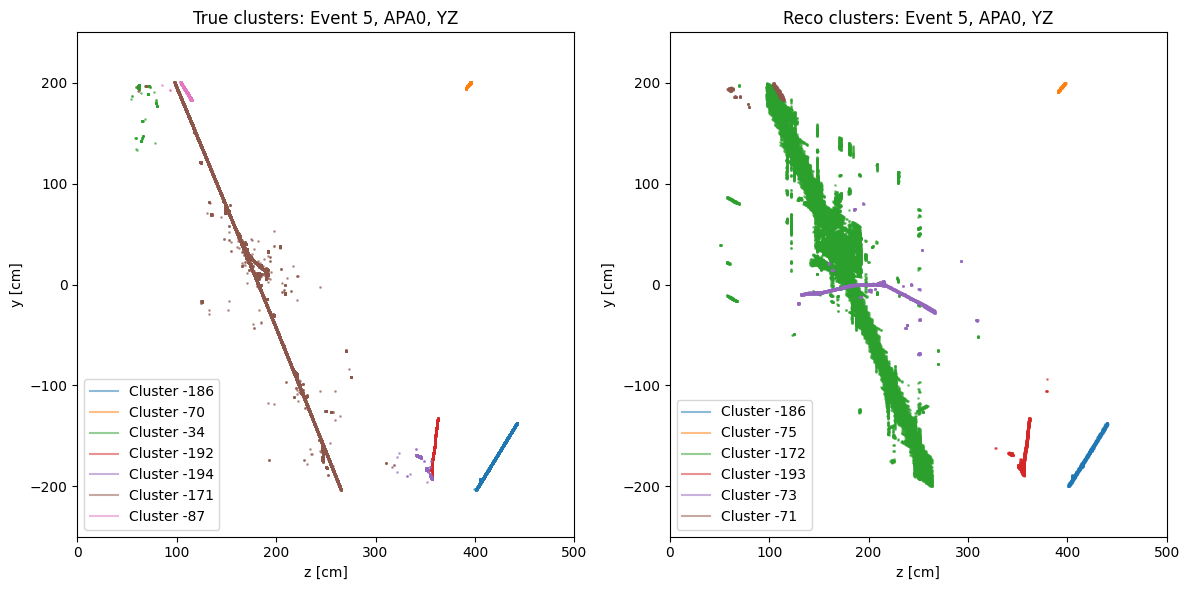

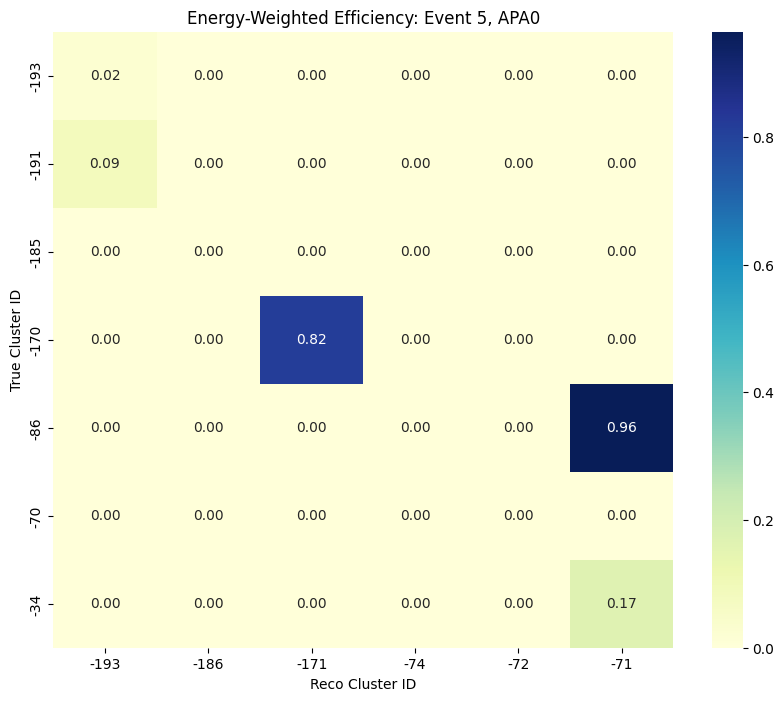

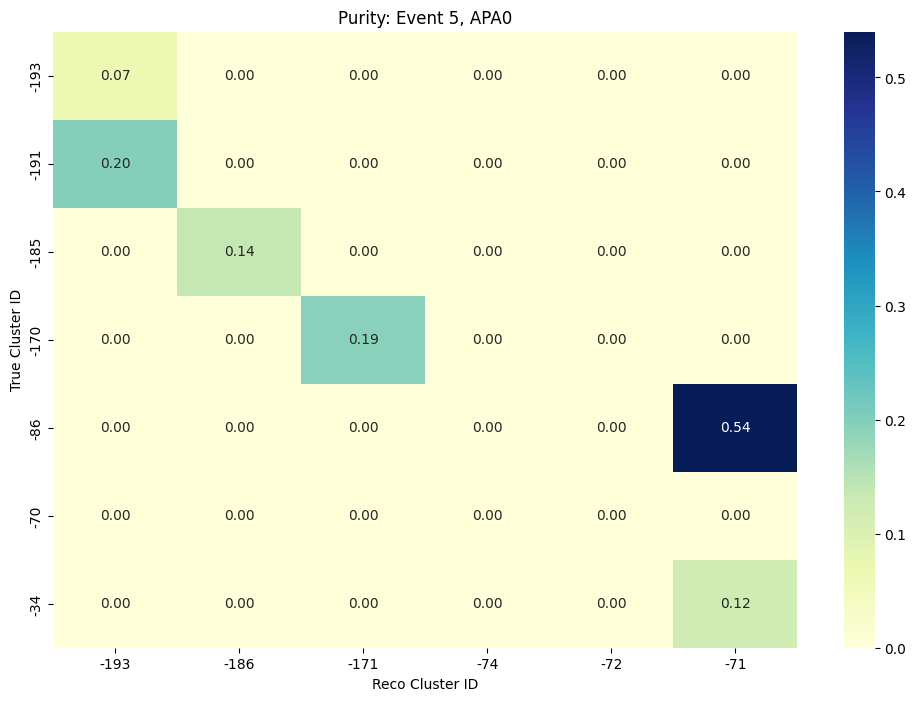

We have  4 matched pairs of true and reco clusters


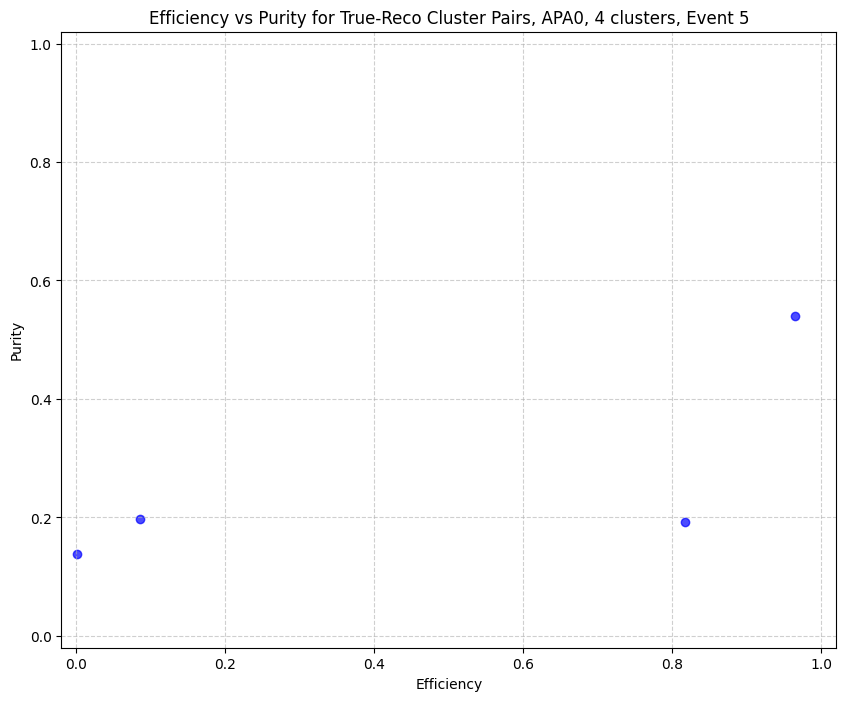

Efficiency and Purity values for each matched pair in Event 5:
True Cluster ID: -191.67, Reco Cluster ID: -193.4, Efficiency: 8.57%, Purity: 19.73%
True Cluster ID: -185.76, Reco Cluster ID: -186.16, Efficiency: 0.16%, Purity: 13.88%
True Cluster ID: -170.85, Reco Cluster ID: -171.95, Efficiency: 81.65%, Purity: 19.25%
True Cluster ID: -86.84, Reco Cluster ID: -71.08, Efficiency: 96.47%, Purity: 54.01%


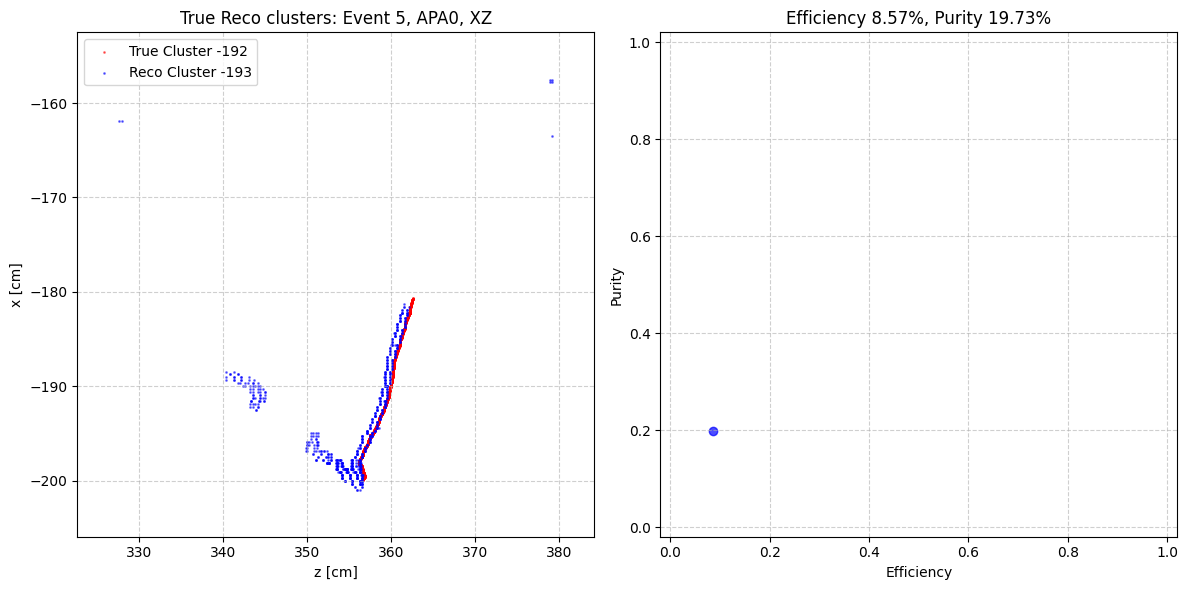

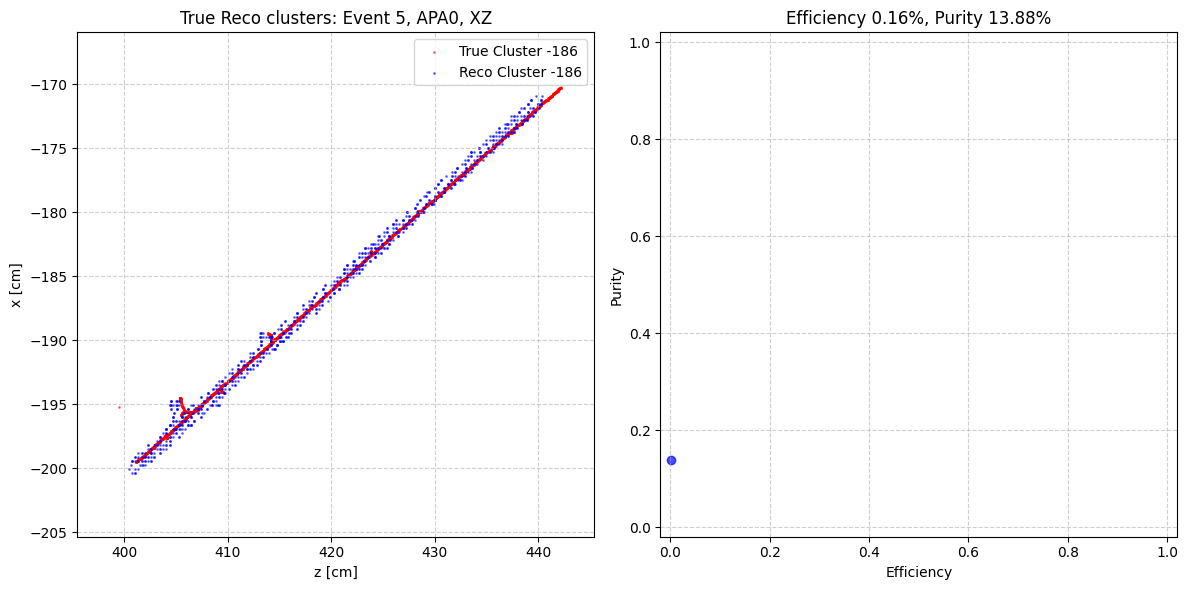

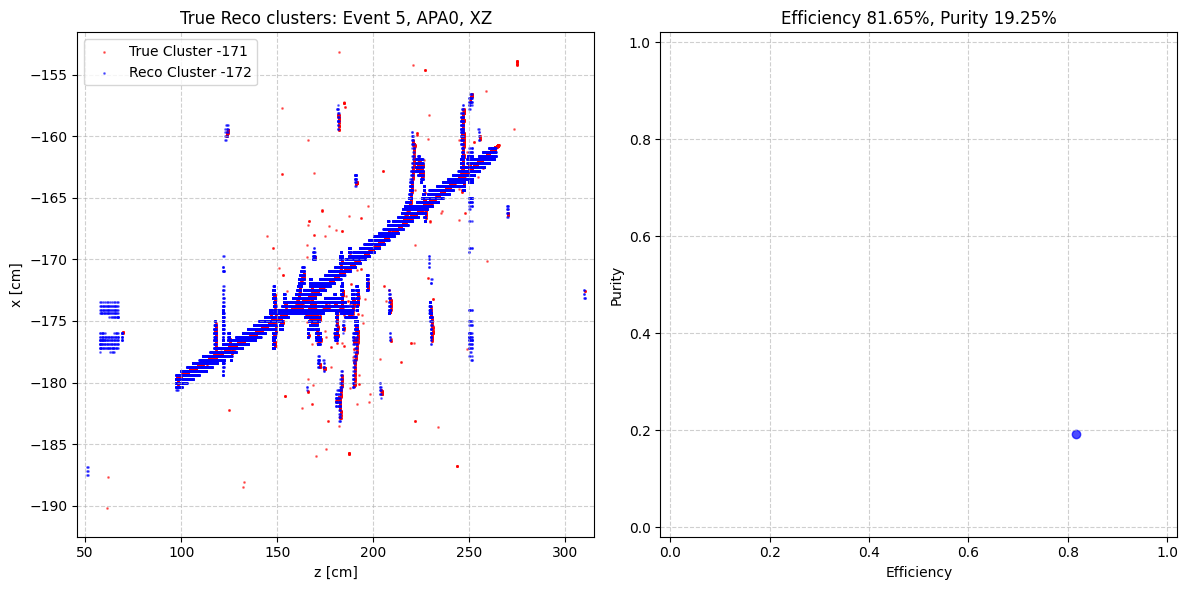

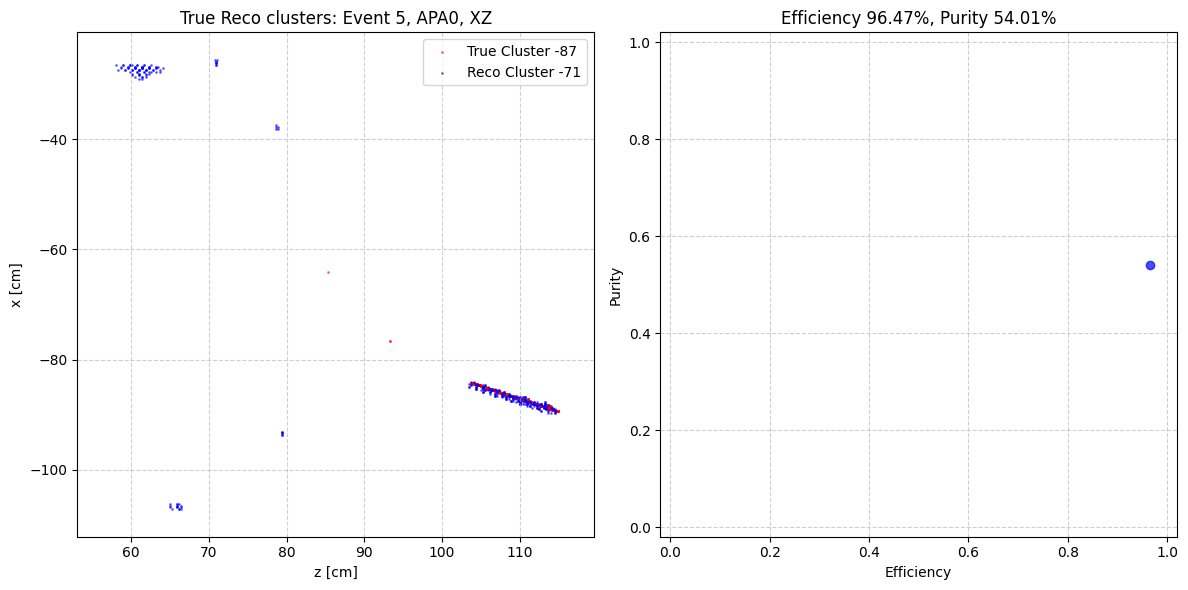



Processing event 6...
Number of true points before cosmic filter: 12813
Number of true points after cosmic filter (q_true != 1): 12769
Number of true points before energy cutoff: 12769
Number of true points after energy cutoff: 12657
Number of true points before minimum points cutoff: 12657
Number of true points after minimum points cutoff: 12657
Number of true points before fiducial volume cut: 12657
Number of true points after fiducial volume cut: 12031
Number of true clusters: 2
Number of reco points before minimum points cutoff: 4040
Number of reco points after minimum points cutoff: 3981
Number of reco points before fiducial volume cut: 3981
Number of reco points after fiducial volume cut: 3975
Number of reco clusters: 1


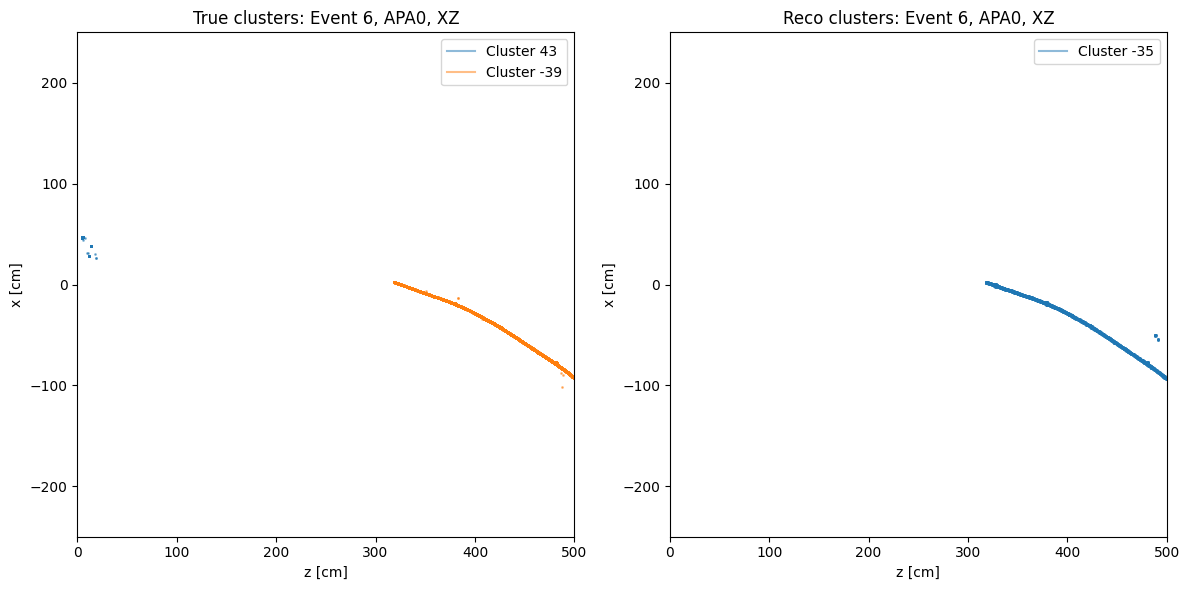

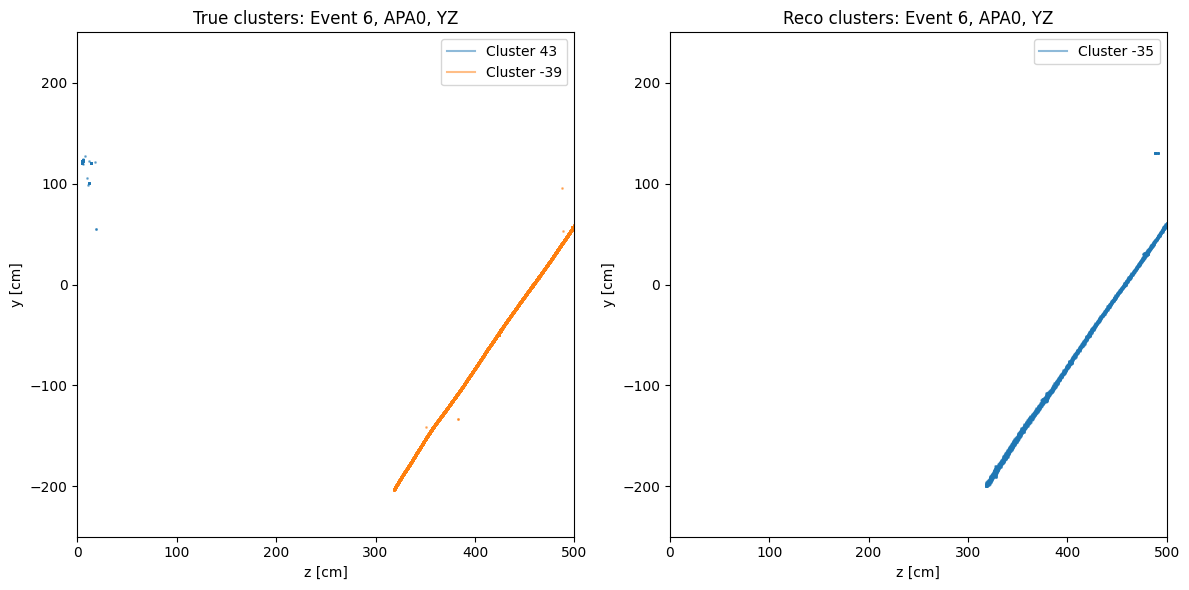

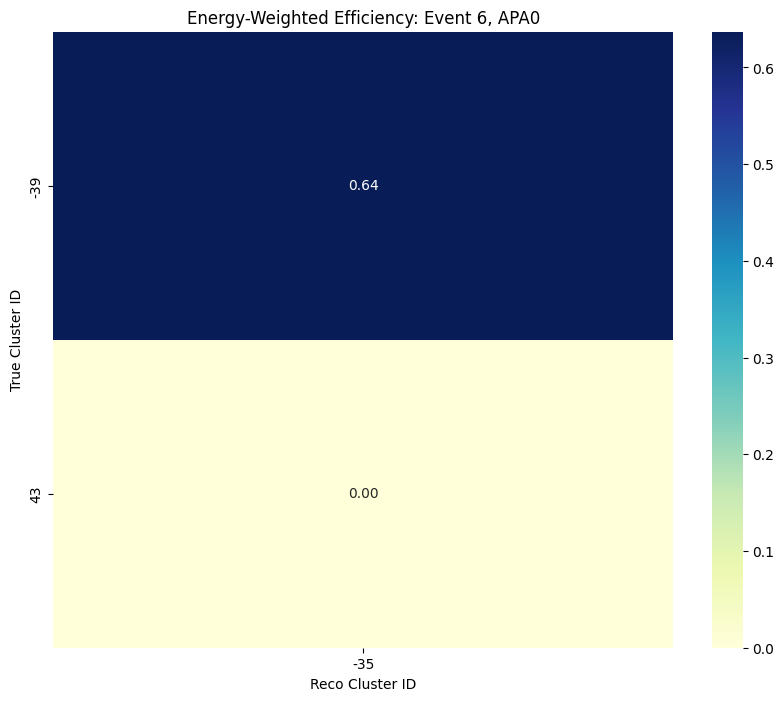

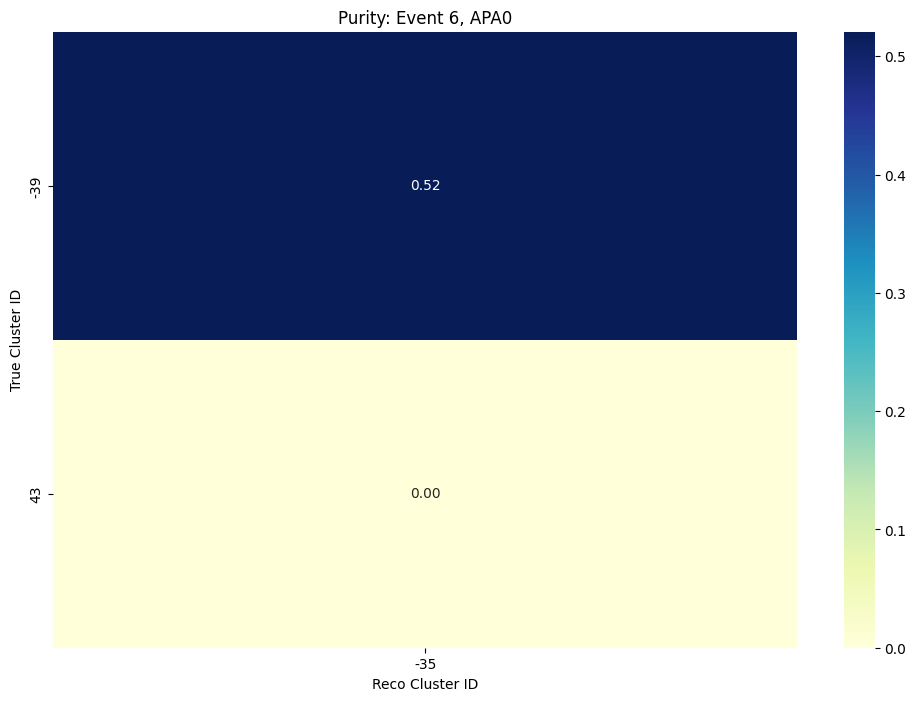

We have  1 matched pairs of true and reco clusters


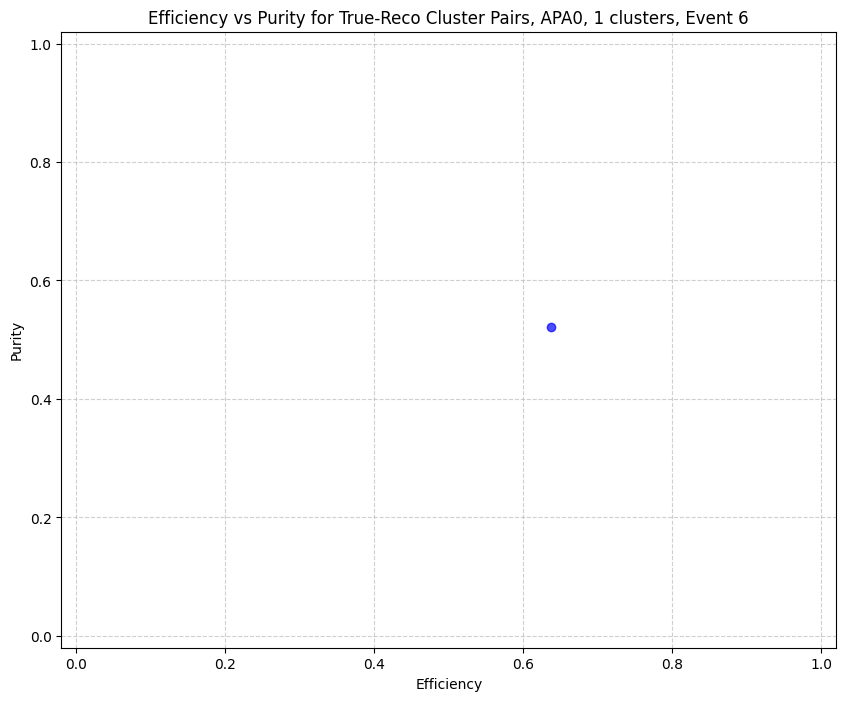

Efficiency and Purity values for each matched pair in Event 6:
True Cluster ID: -39.46, Reco Cluster ID: -35.06, Efficiency: 63.69%, Purity: 52.08%


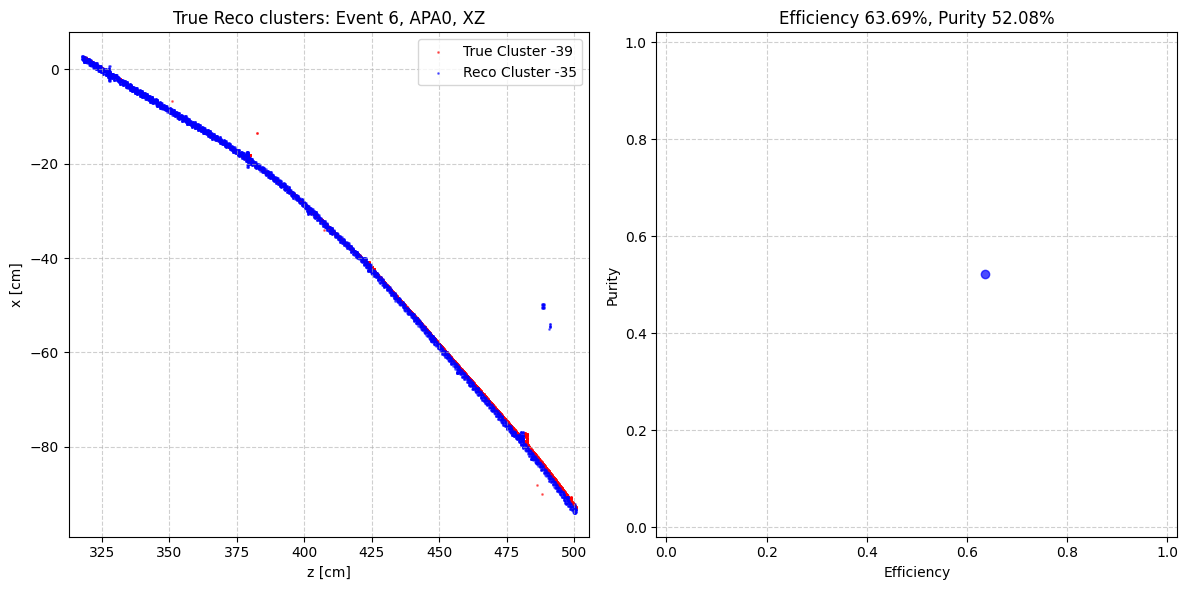



Processing event 7...
Number of true points before cosmic filter: 57918
Number of true points after cosmic filter (q_true != 1): 57918
Number of true points before energy cutoff: 57918
Number of true points after energy cutoff: 57602
Number of true points before minimum points cutoff: 57602
Number of true points after minimum points cutoff: 57602
Number of true points before fiducial volume cut: 57602
Number of true points after fiducial volume cut: 56986
Number of true clusters: 7
Number of reco points before minimum points cutoff: 17570
Number of reco points after minimum points cutoff: 17469
Number of reco points before fiducial volume cut: 17469
Number of reco points after fiducial volume cut: 17454
Number of reco clusters: 7


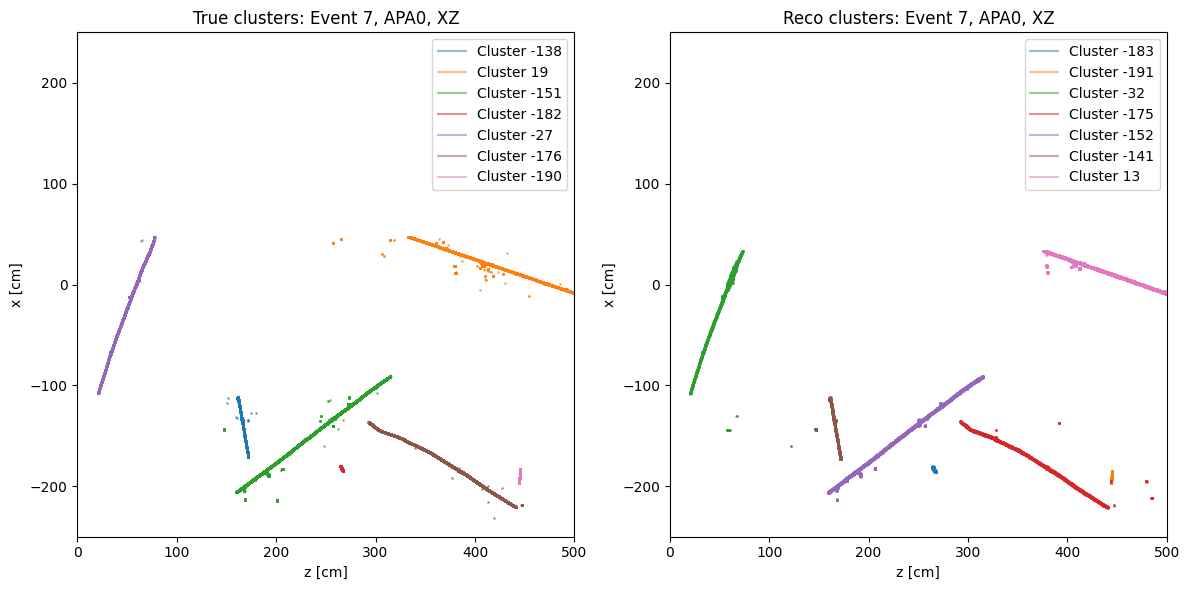

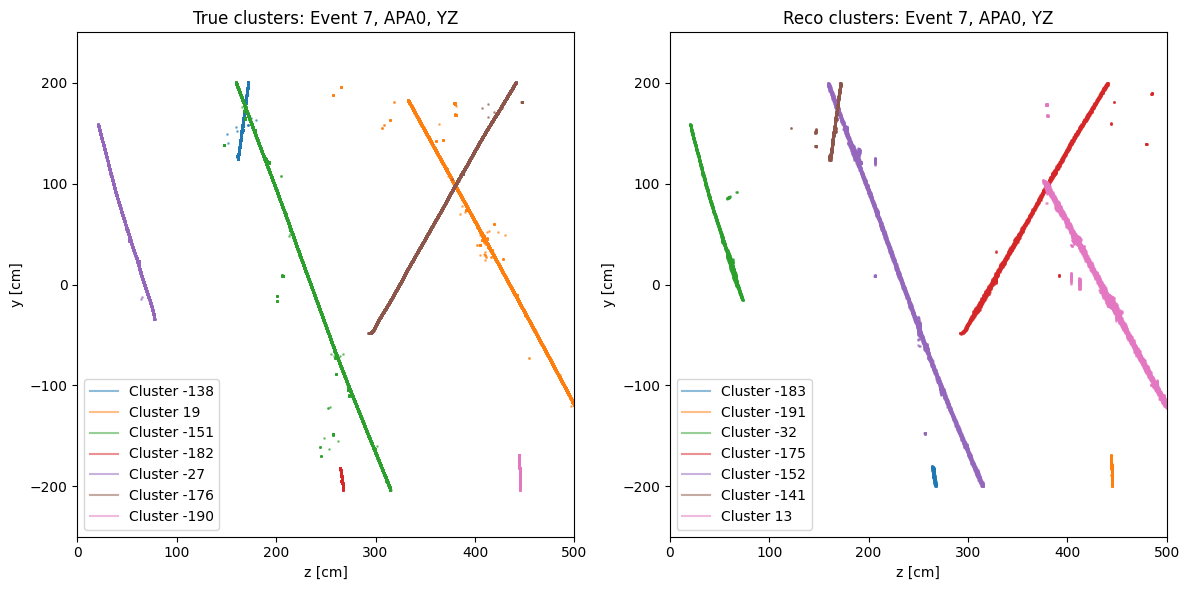

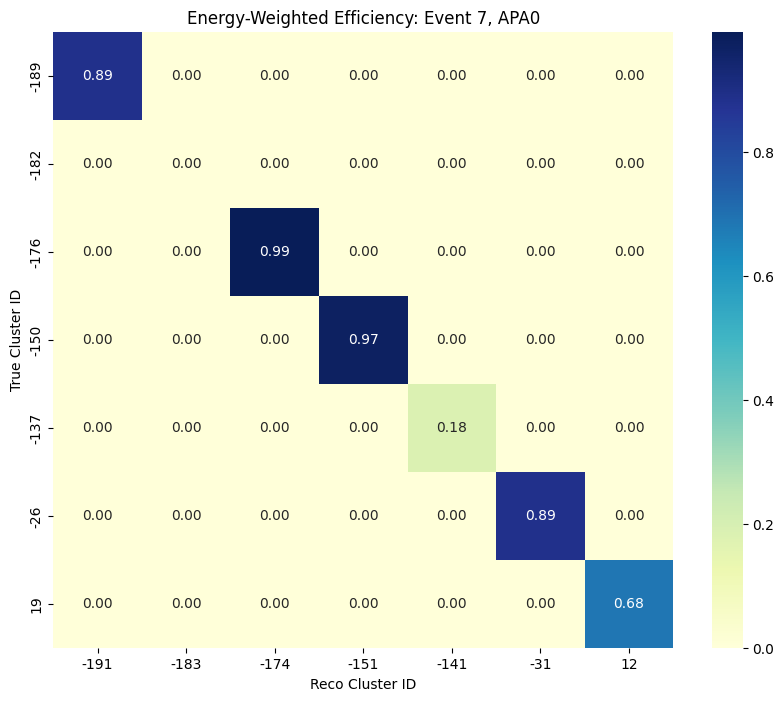

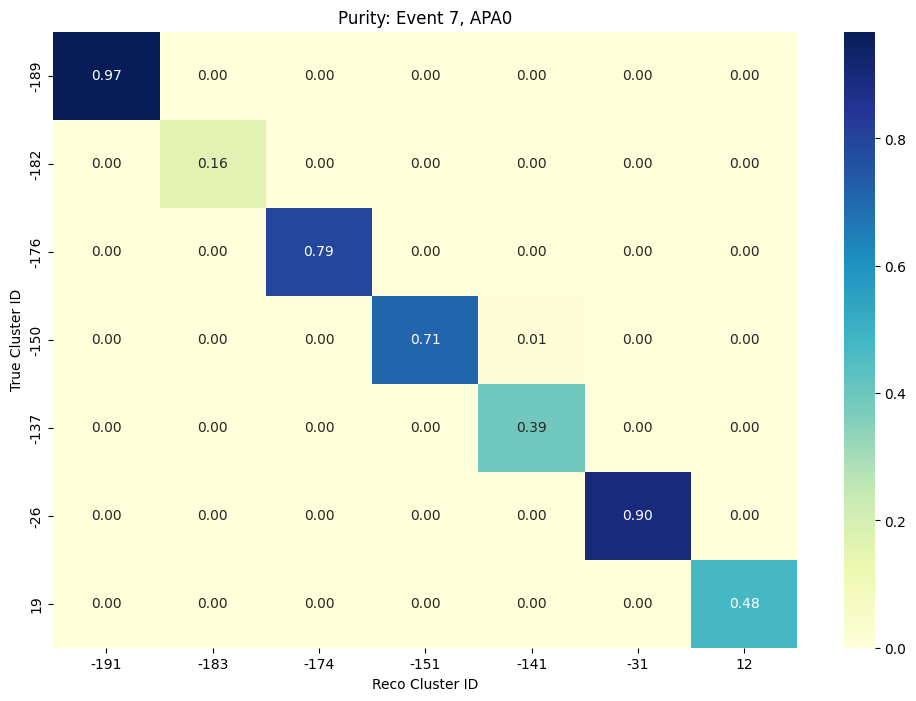

We have  7 matched pairs of true and reco clusters


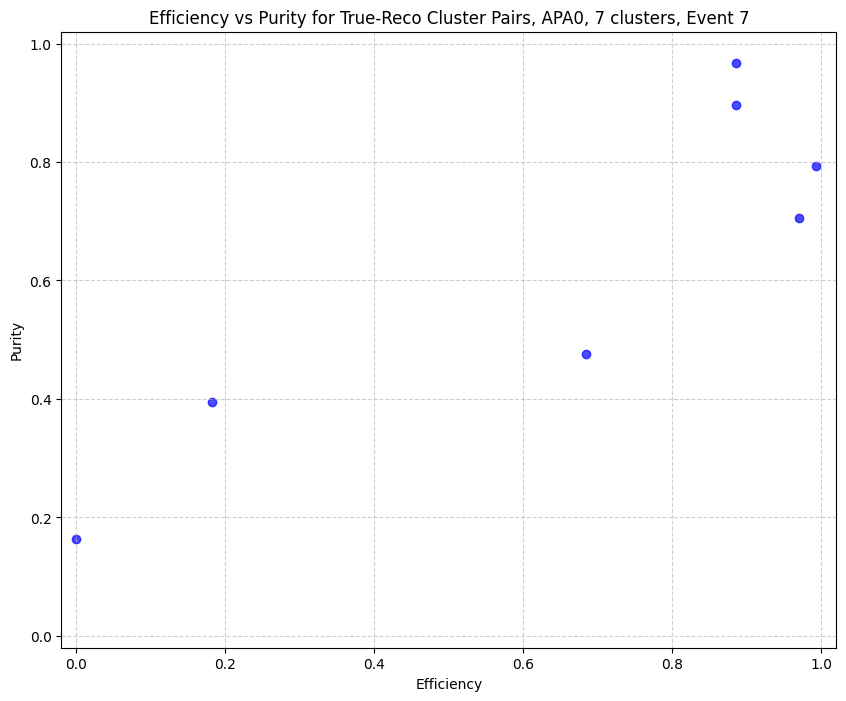

Efficiency and Purity values for each matched pair in Event 7:
True Cluster ID: -189.96, Reco Cluster ID: -191.1, Efficiency: 88.54%, Purity: 96.77%
True Cluster ID: -182.35, Reco Cluster ID: -183.23, Efficiency: 0.00%, Purity: 16.29%
True Cluster ID: -176.0, Reco Cluster ID: -174.74, Efficiency: 99.35%, Purity: 79.27%
True Cluster ID: -150.55, Reco Cluster ID: -151.63, Efficiency: 97.04%, Purity: 70.57%
True Cluster ID: -137.84, Reco Cluster ID: -141.18, Efficiency: 18.29%, Purity: 39.42%
True Cluster ID: -26.81, Reco Cluster ID: -31.83, Efficiency: 88.58%, Purity: 89.62%
True Cluster ID: 19.17, Reco Cluster ID: 12.58, Efficiency: 68.45%, Purity: 47.53%


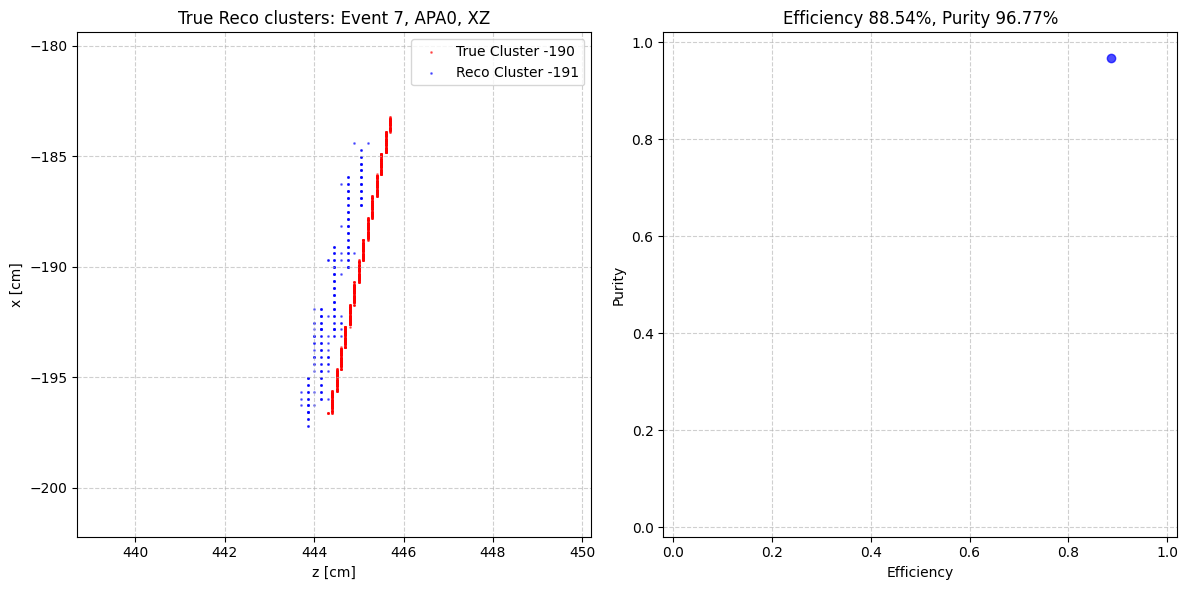

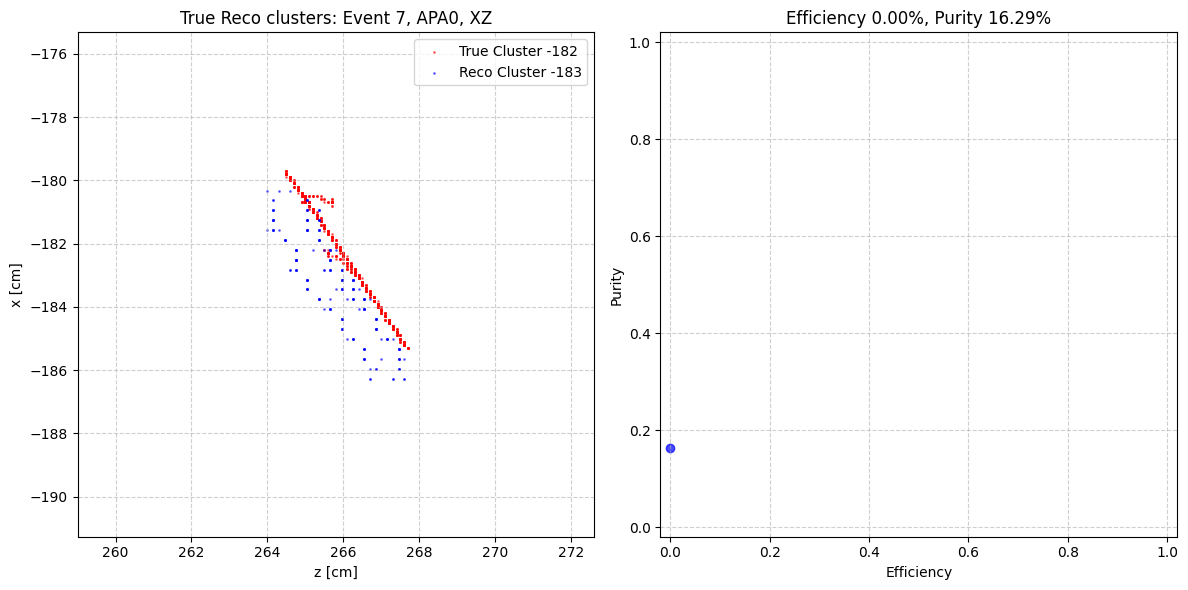

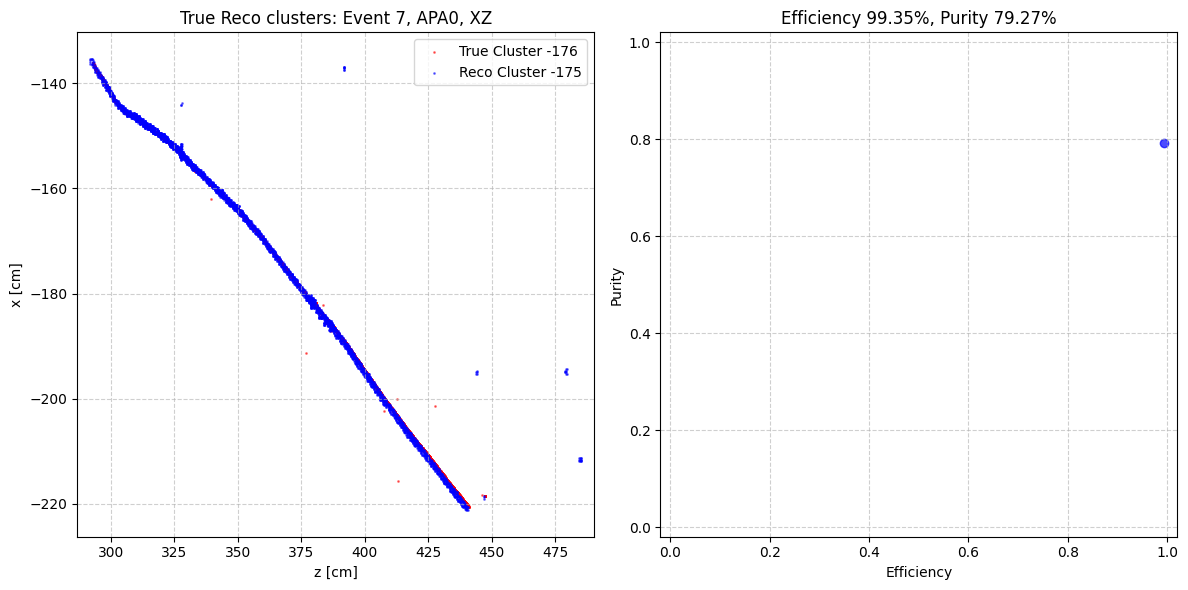

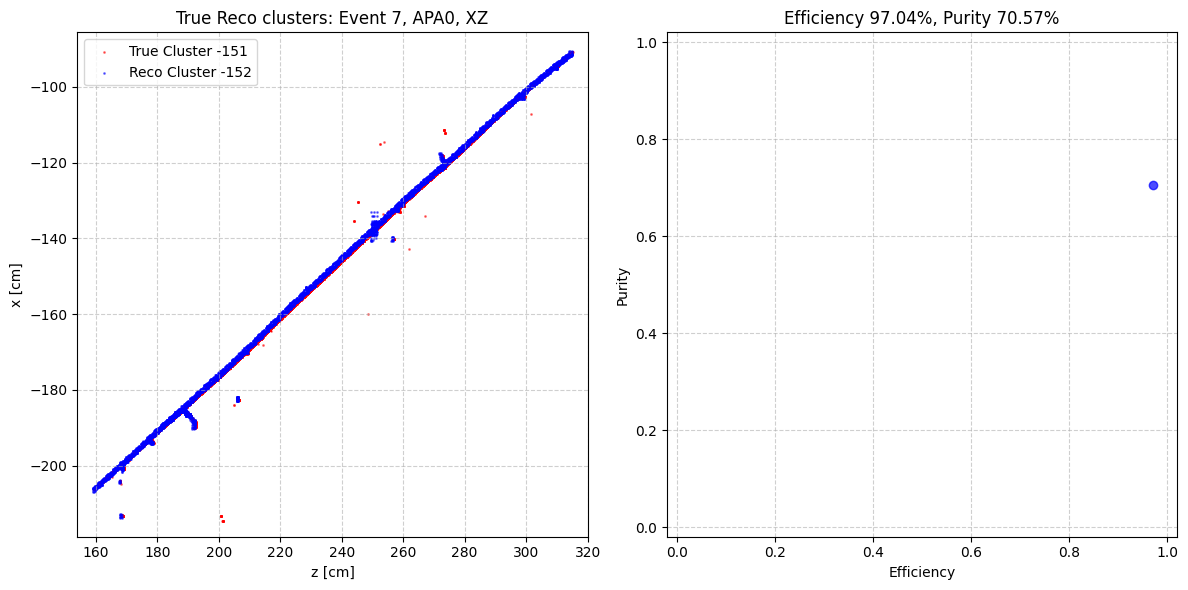

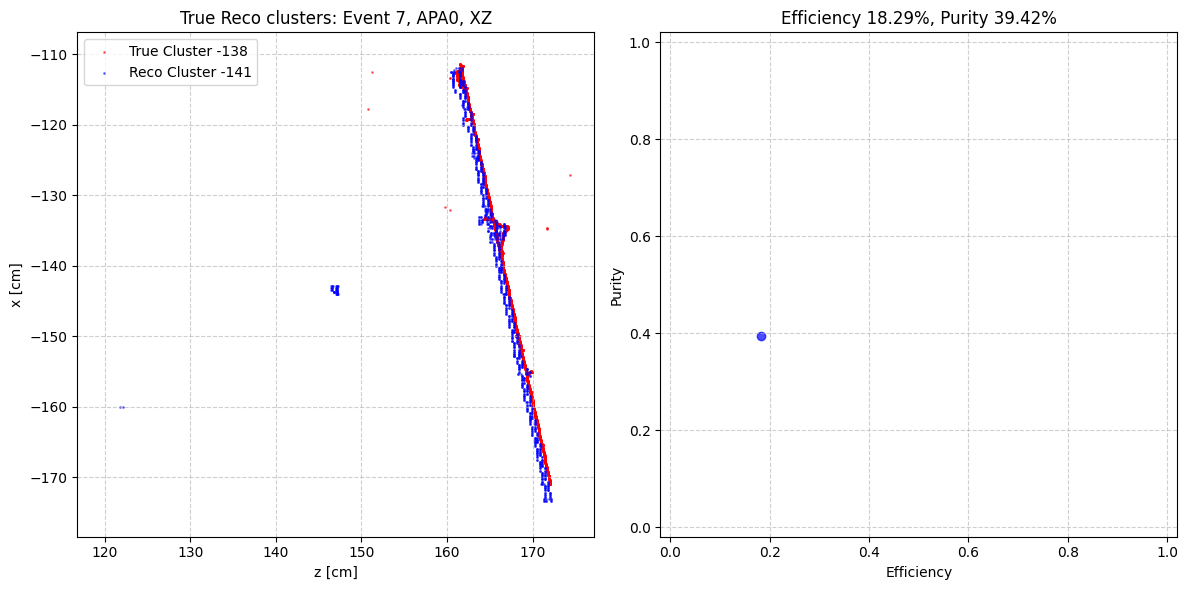

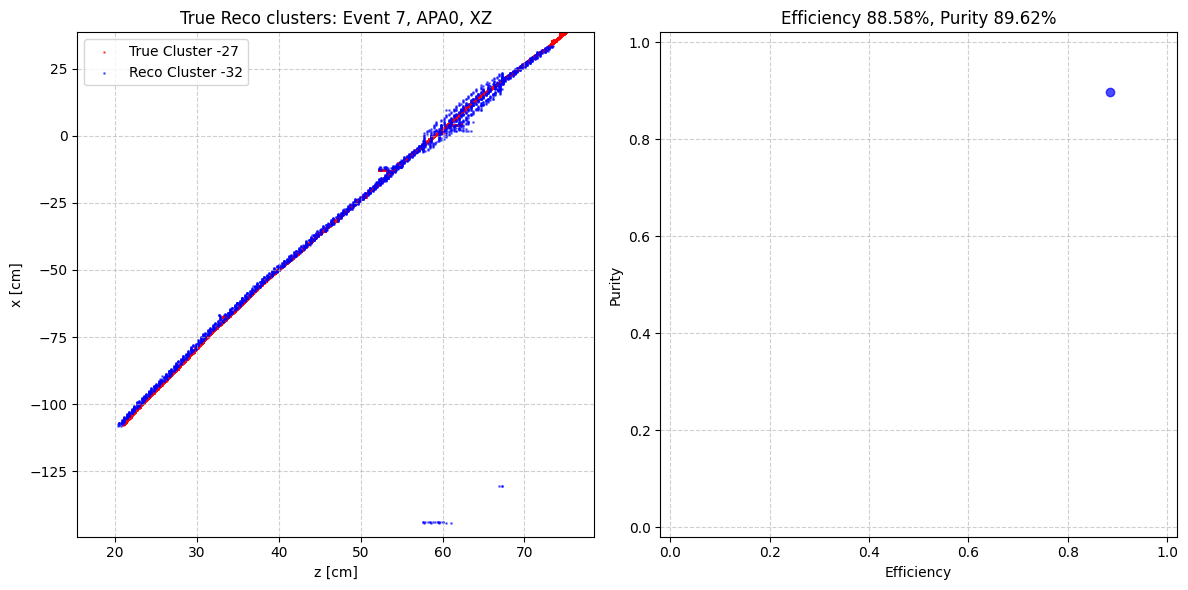

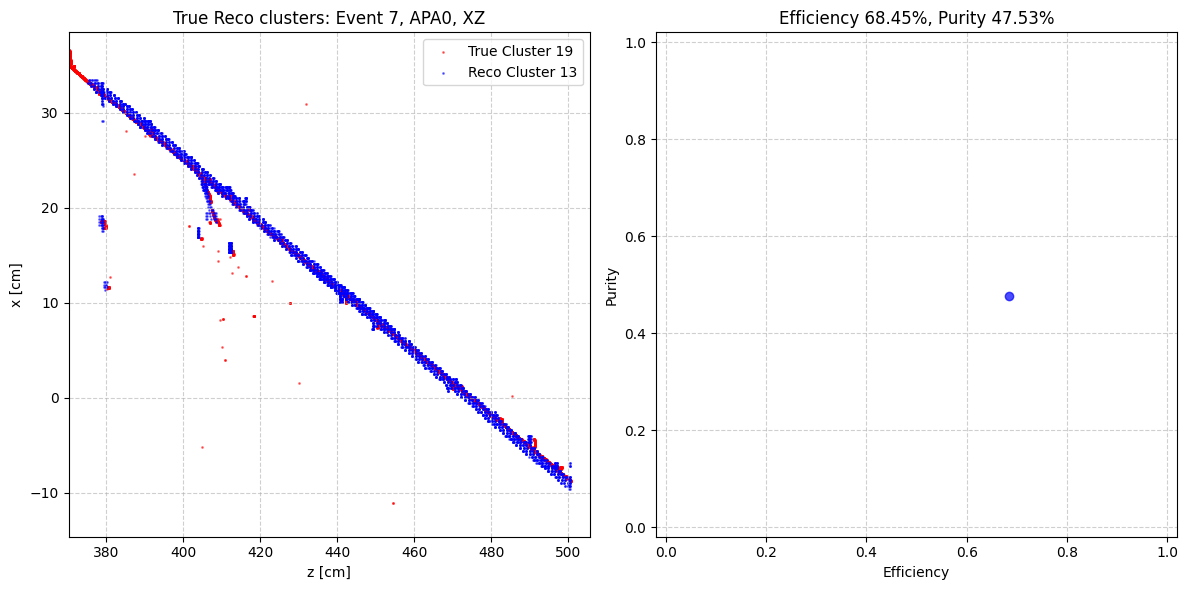



Processing event 8...
Number of true points before cosmic filter: 93473
Number of true points after cosmic filter (q_true != 1): 93473
Number of true points before energy cutoff: 93473
Number of true points after energy cutoff: 93115
Number of true points before minimum points cutoff: 93115
Number of true points after minimum points cutoff: 93115
Number of true points before fiducial volume cut: 93115
Number of true points after fiducial volume cut: 92663
Number of true clusters: 10
Number of reco points before minimum points cutoff: 33316
Number of reco points after minimum points cutoff: 33212
Number of reco points before fiducial volume cut: 33212
Number of reco points after fiducial volume cut: 33177
Number of reco clusters: 9


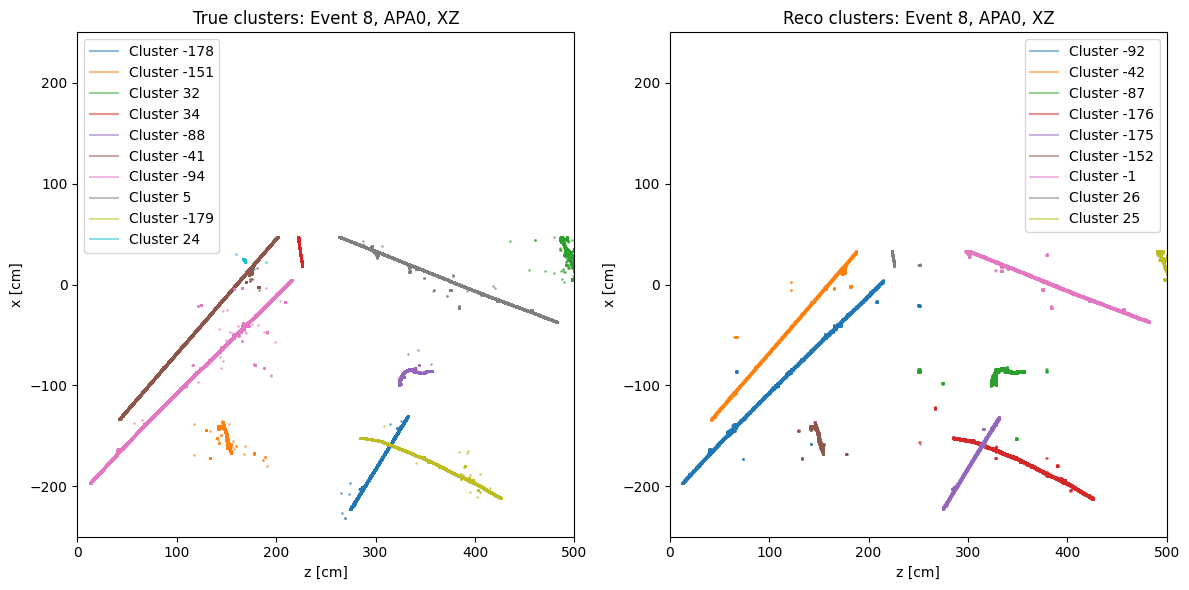

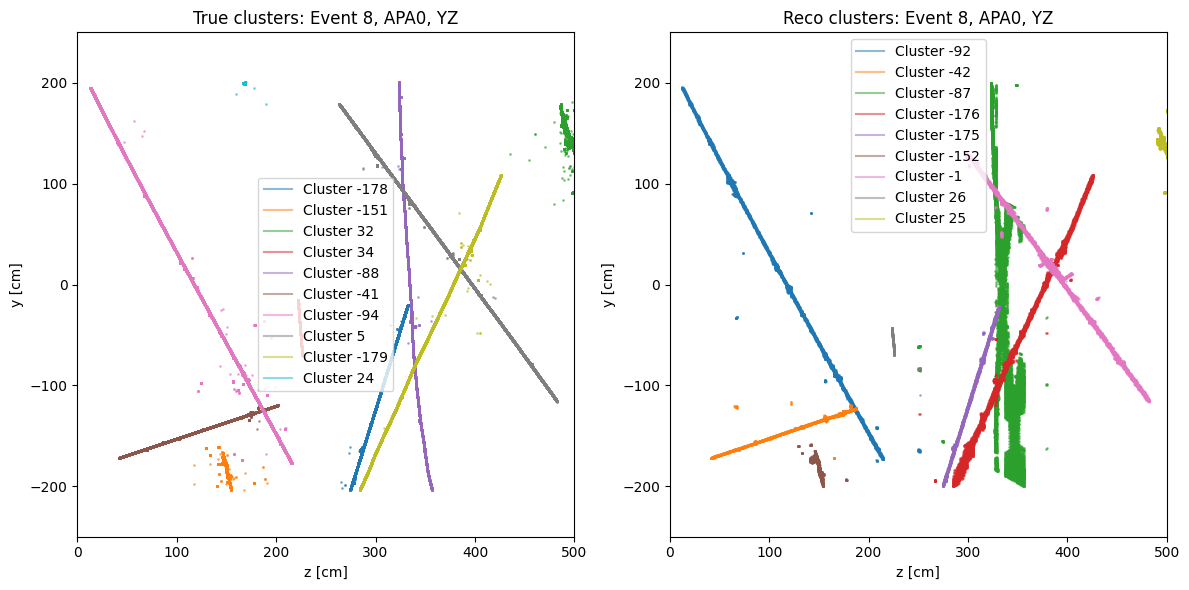

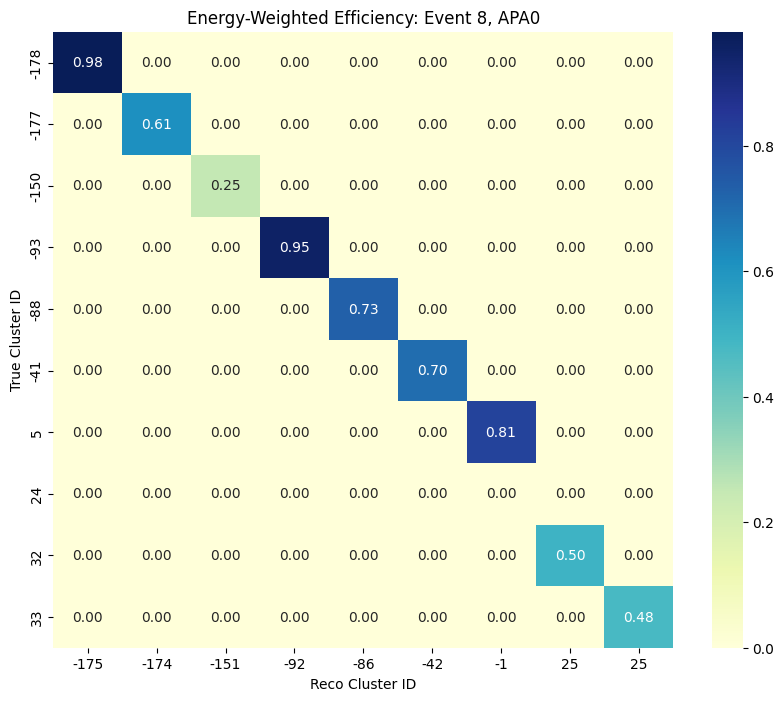

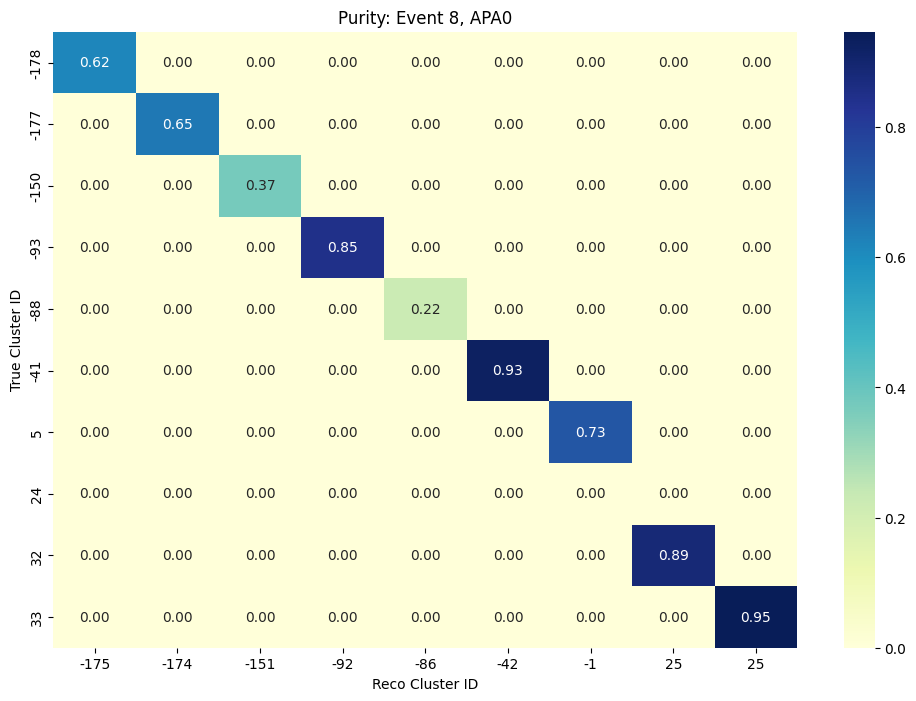

We have  9 matched pairs of true and reco clusters


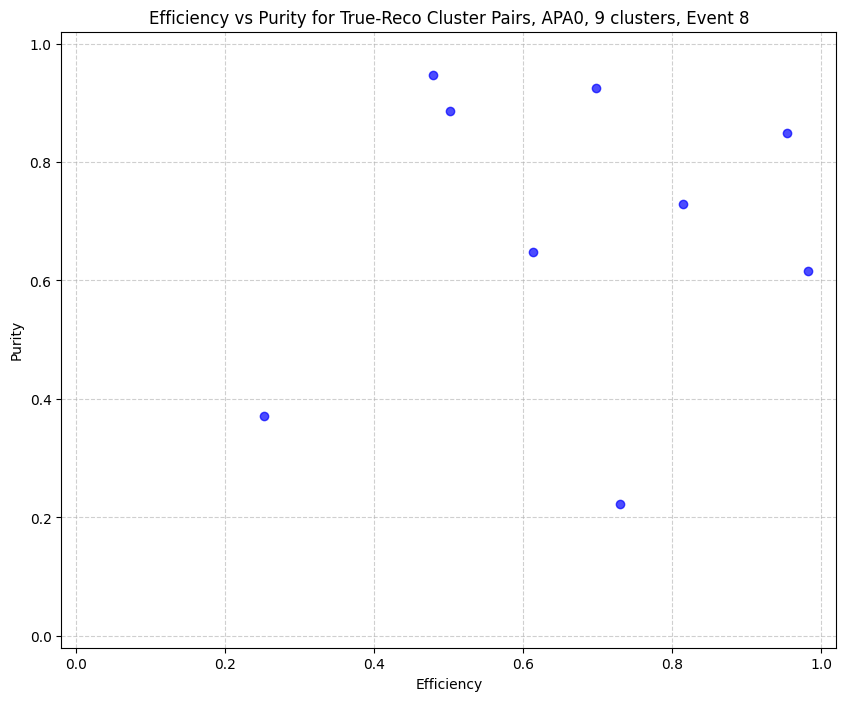

Efficiency and Purity values for each matched pair in Event 8:
True Cluster ID: -178.93, Reco Cluster ID: -175.7, Efficiency: 98.15%, Purity: 61.54%
True Cluster ID: -177.82, Reco Cluster ID: -174.82, Efficiency: 61.34%, Purity: 64.87%
True Cluster ID: -150.96, Reco Cluster ID: -151.54, Efficiency: 25.14%, Purity: 37.16%
True Cluster ID: -93.8, Reco Cluster ID: -92.42, Efficiency: 95.38%, Purity: 84.95%
True Cluster ID: -88.05, Reco Cluster ID: -86.99, Efficiency: 73.04%, Purity: 22.23%
True Cluster ID: -41.1, Reco Cluster ID: -42.36, Efficiency: 69.79%, Purity: 92.53%
True Cluster ID: 5.15, Reco Cluster ID: -1.3, Efficiency: 81.39%, Purity: 72.99%
True Cluster ID: 32.13, Reco Cluster ID: 25.03, Efficiency: 50.12%, Purity: 88.64%
True Cluster ID: 33.63, Reco Cluster ID: 25.81, Efficiency: 47.92%, Purity: 94.67%


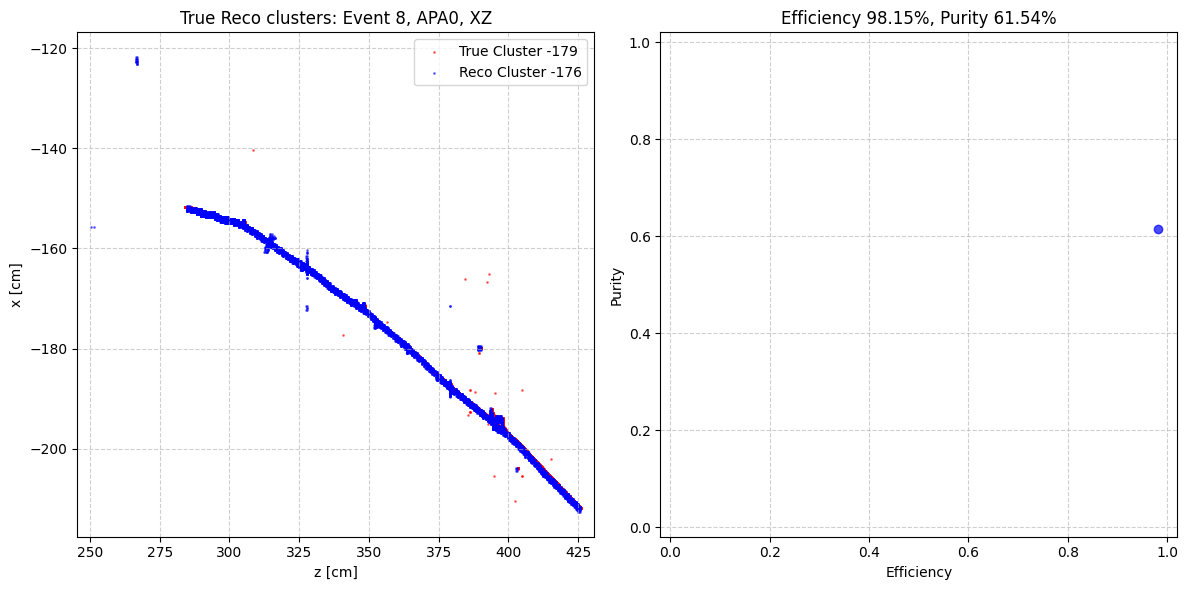

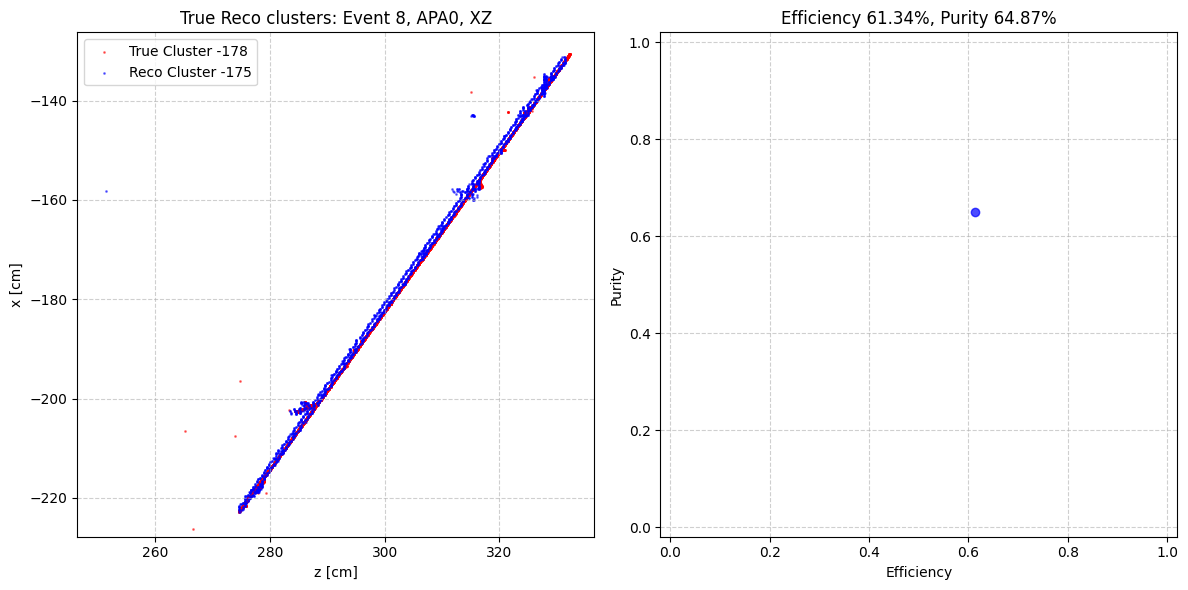

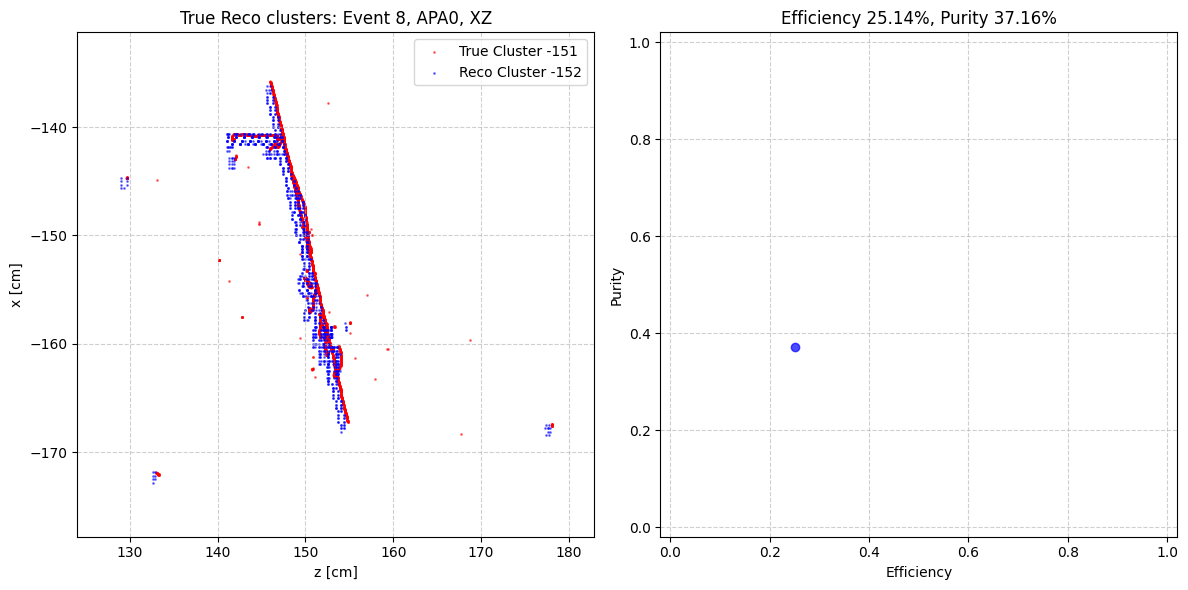

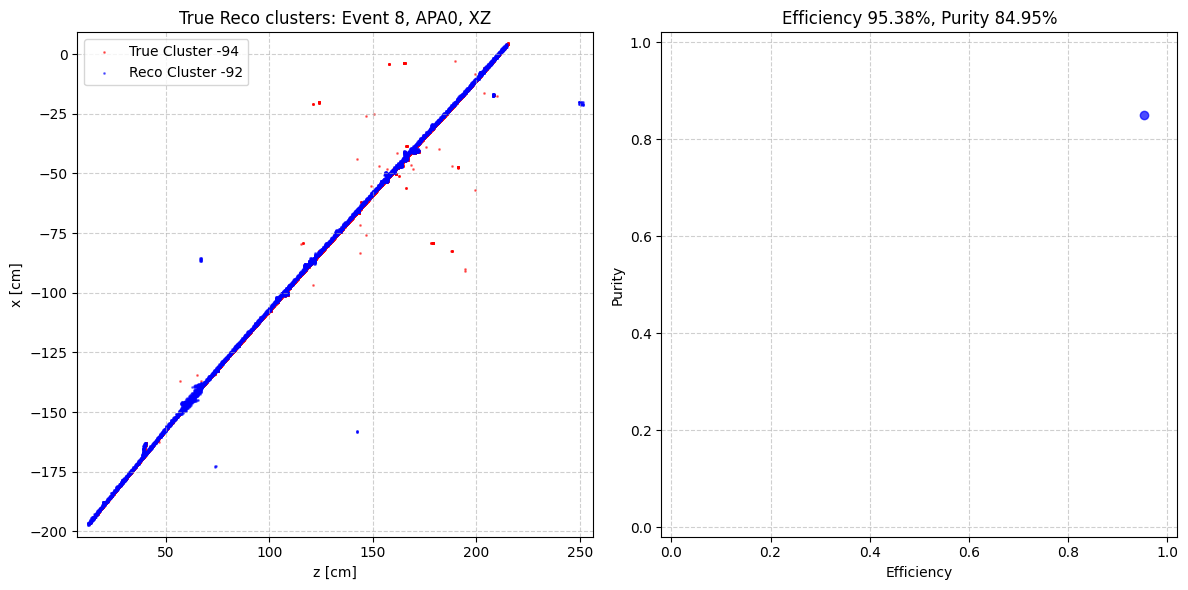

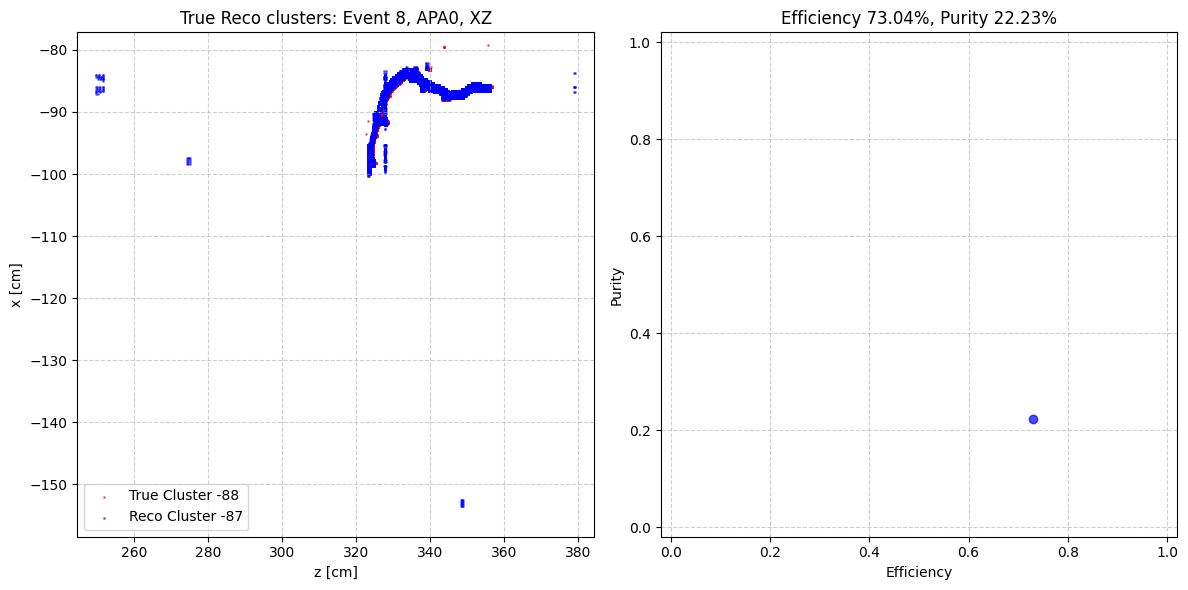

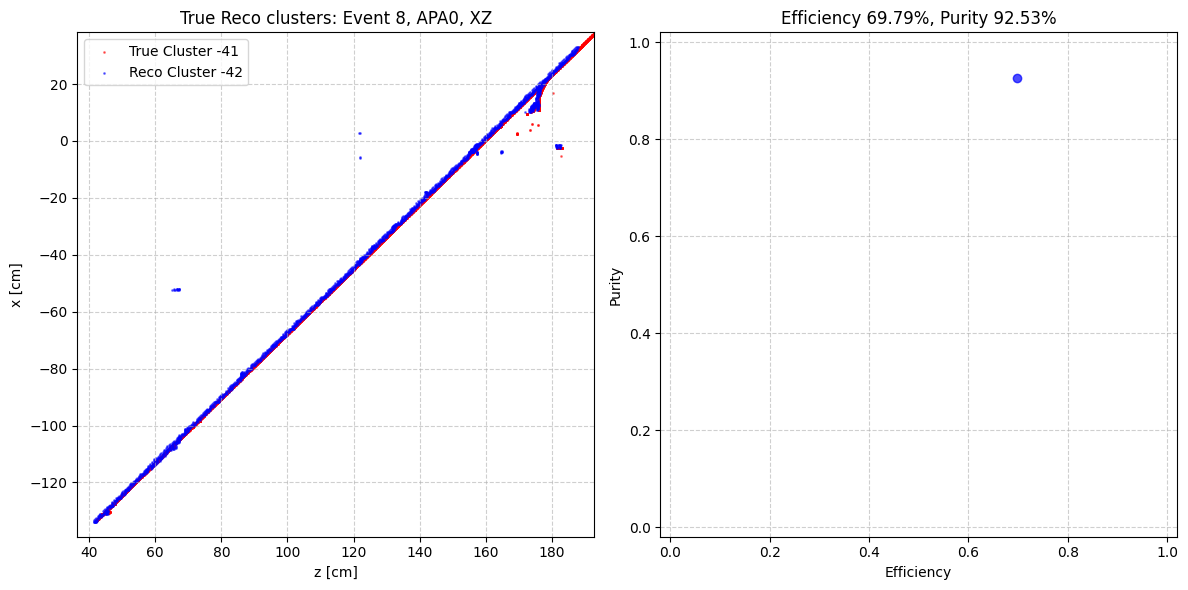

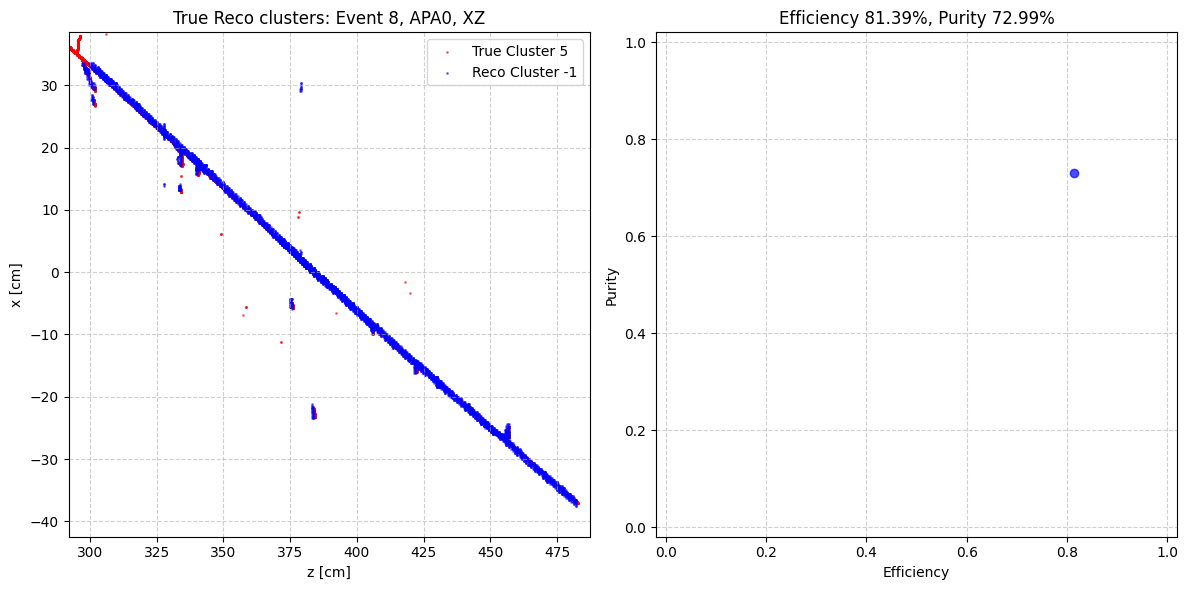

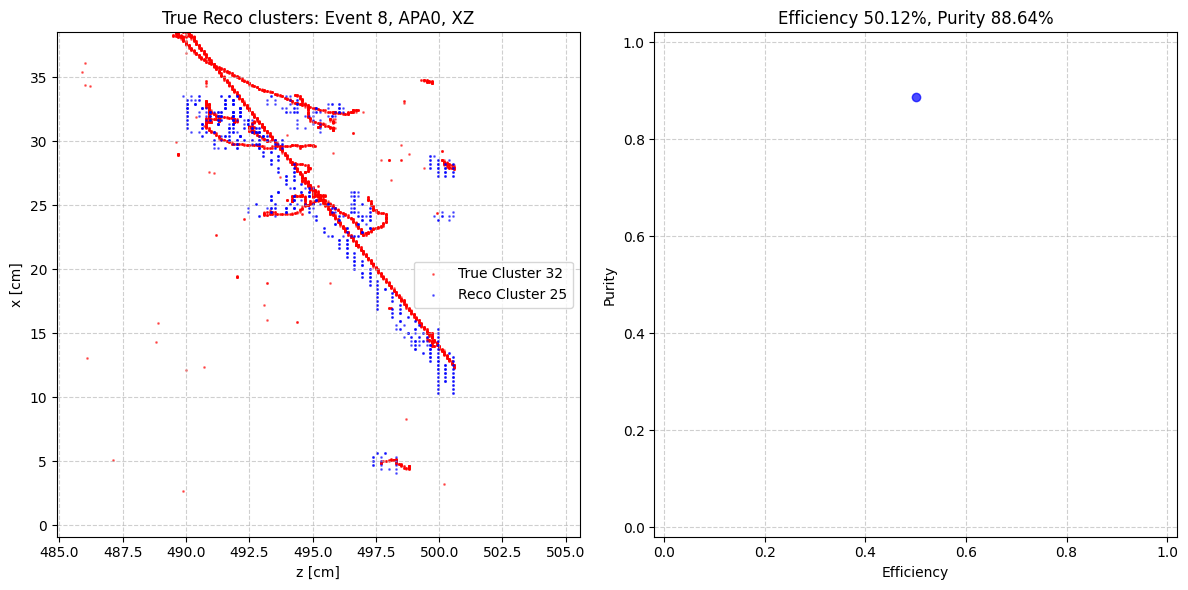

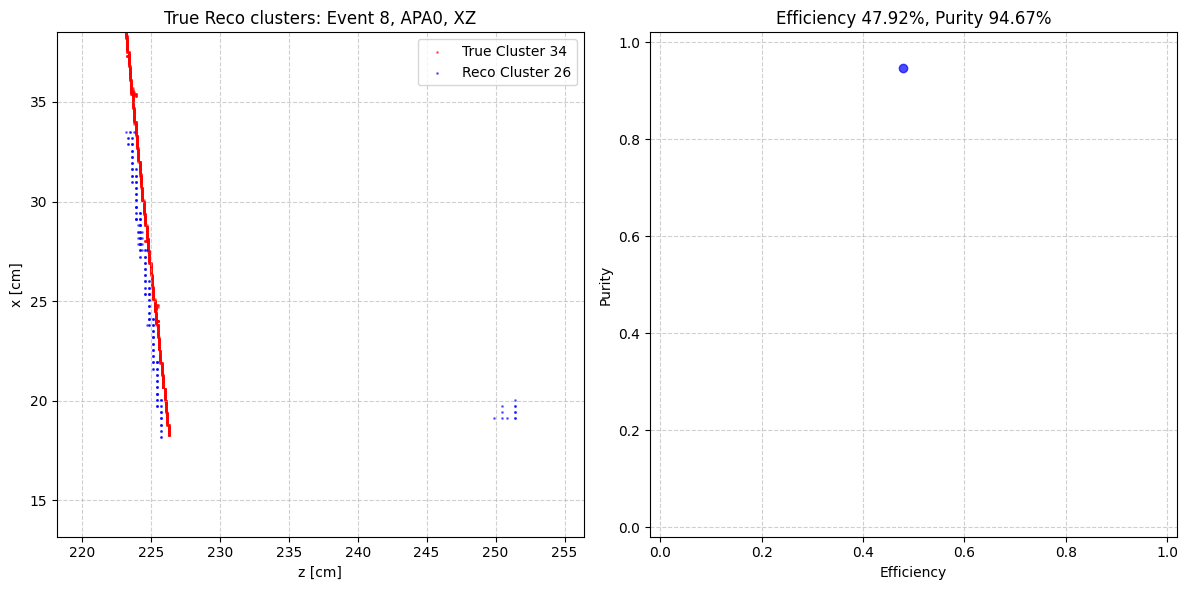



Processing event 9...
Number of true points before cosmic filter: 16922
Number of true points after cosmic filter (q_true != 1): 14909
Number of true points before energy cutoff: 14909
Number of true points after energy cutoff: 14864
Number of true points before minimum points cutoff: 14864
Number of true points after minimum points cutoff: 14864
Number of true points before fiducial volume cut: 14864
Number of true points after fiducial volume cut: 14211
Number of true clusters: 4
Number of reco points before minimum points cutoff: 4462
Number of reco points after minimum points cutoff: 4223
Number of reco points before fiducial volume cut: 4223
Number of reco points after fiducial volume cut: 4223
Number of reco clusters: 3


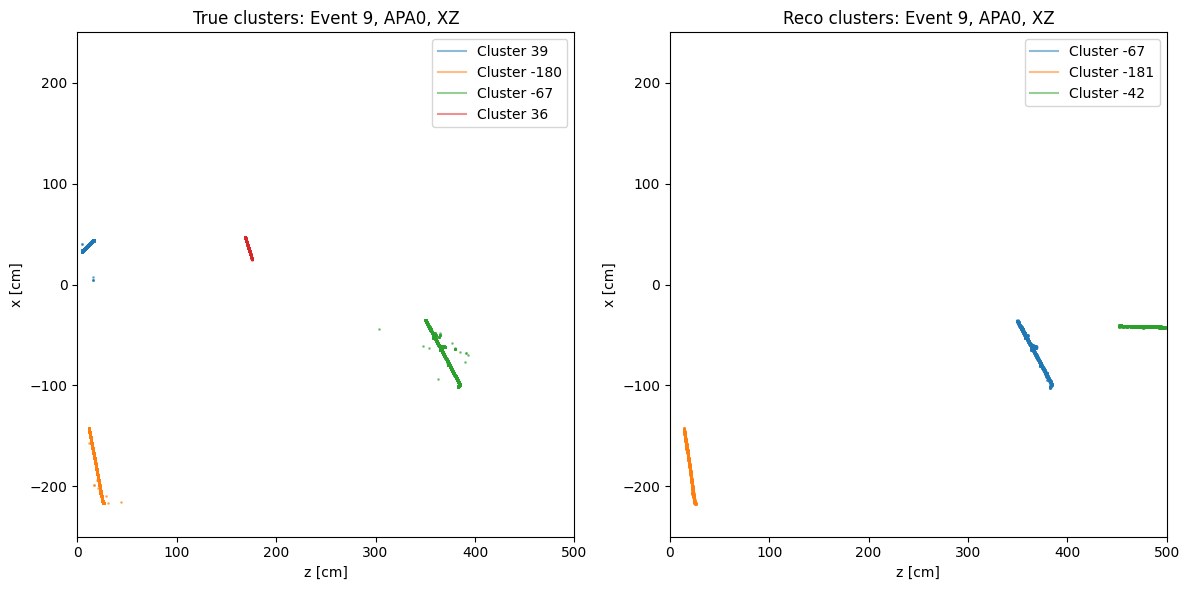

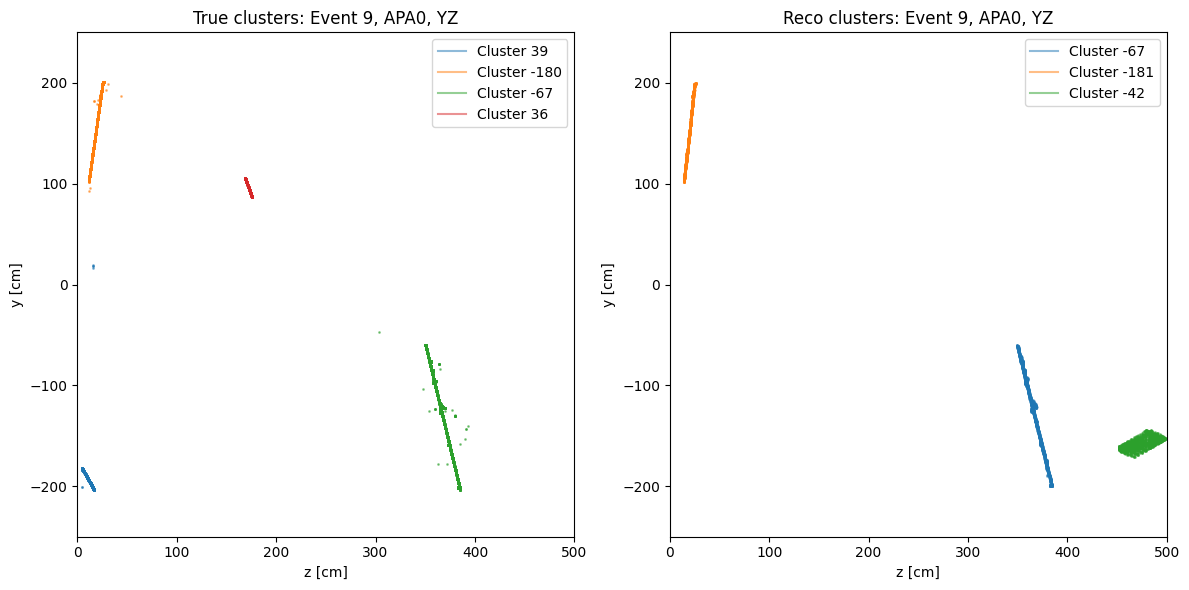

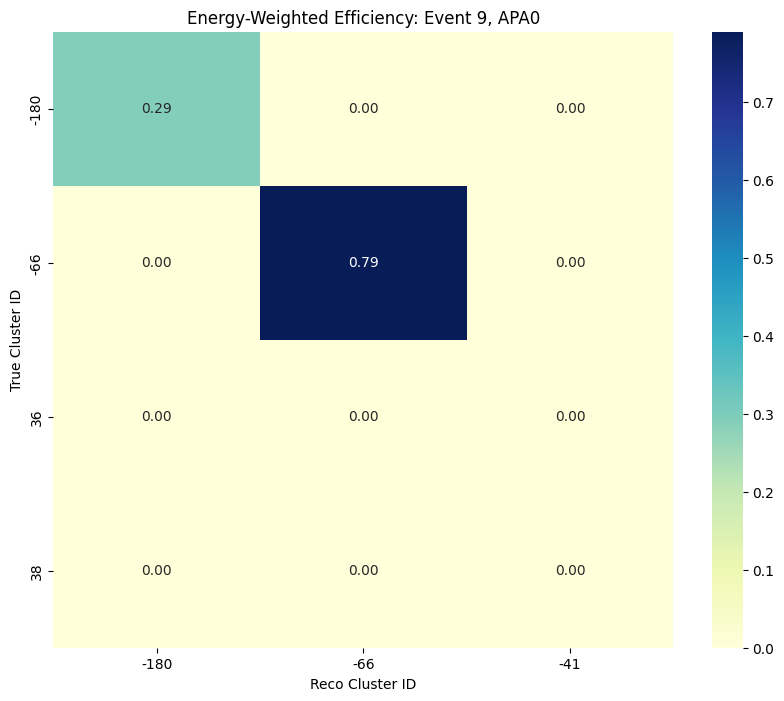

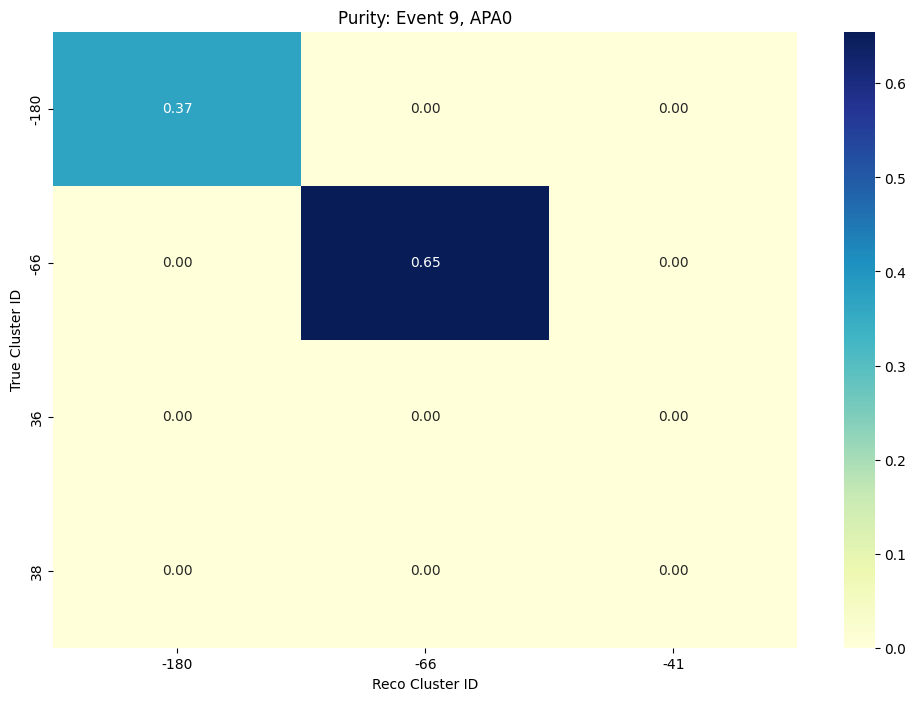

We have  2 matched pairs of true and reco clusters


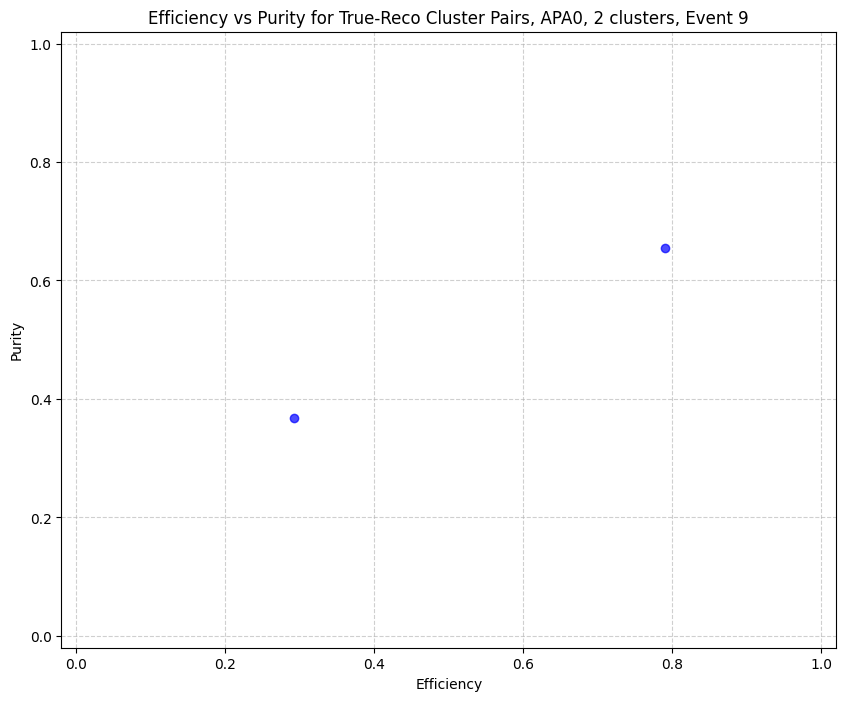

Efficiency and Purity values for each matched pair in Event 9:
True Cluster ID: -180.04, Reco Cluster ID: -180.51, Efficiency: 29.29%, Purity: 36.84%
True Cluster ID: -66.85, Reco Cluster ID: -66.9, Efficiency: 78.95%, Purity: 65.49%


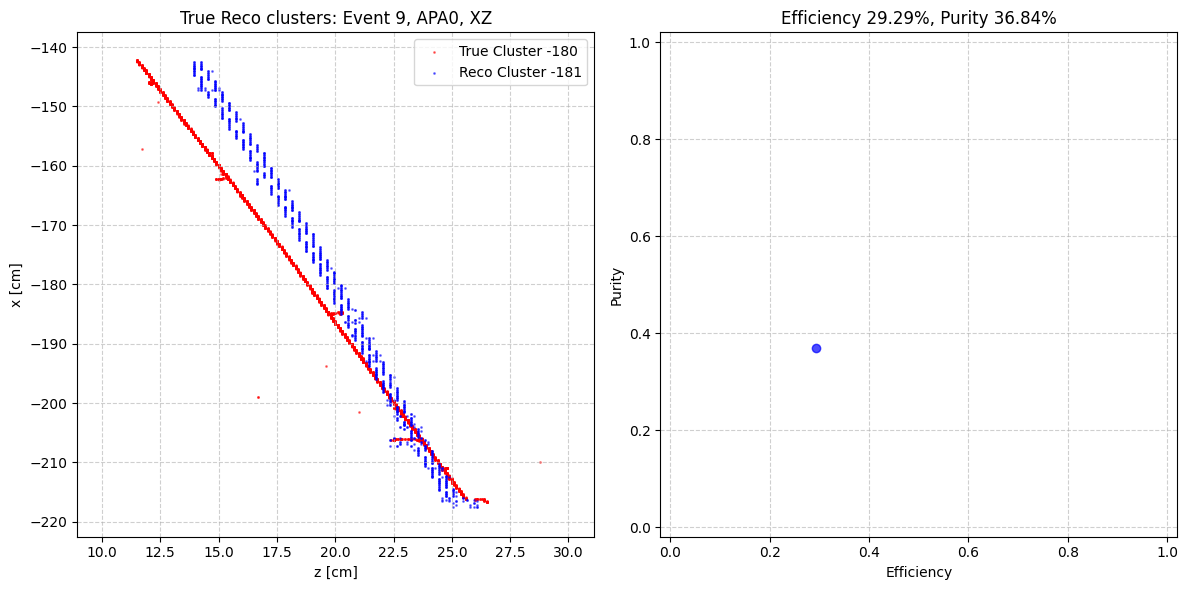

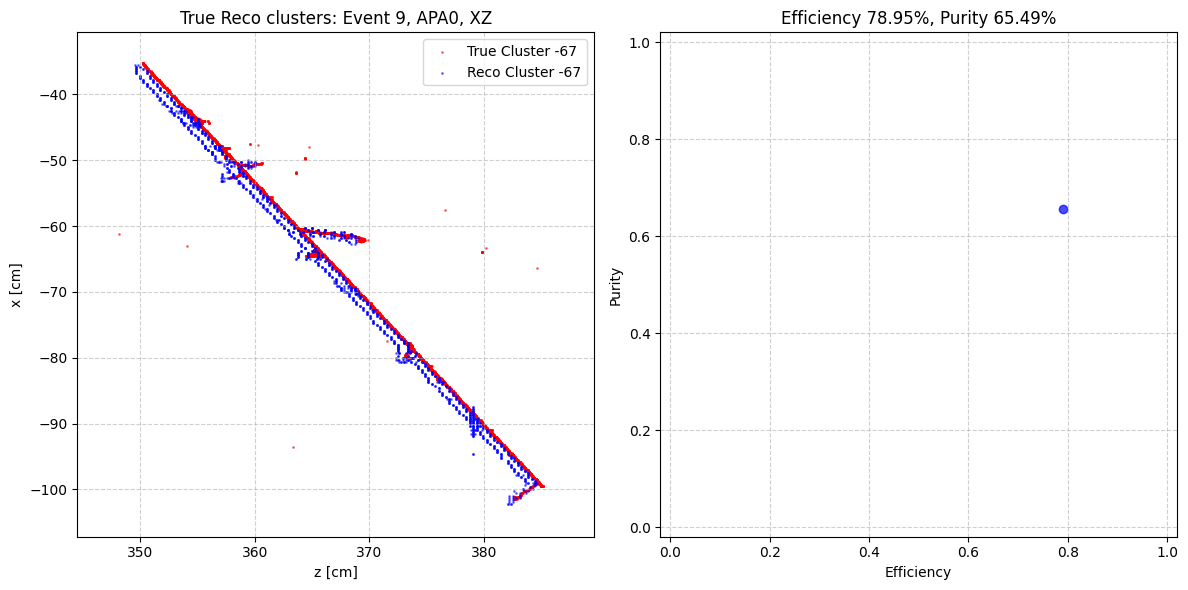



Processing event 10...
Number of true points before cosmic filter: 26183
Number of true points after cosmic filter (q_true != 1): 26183
Number of true points before energy cutoff: 26183
Number of true points after energy cutoff: 26067
Number of true points before minimum points cutoff: 26067
Number of true points after minimum points cutoff: 25888
Number of true points before fiducial volume cut: 25888
Number of true points after fiducial volume cut: 25805
Number of true clusters: 3
Number of reco points before minimum points cutoff: 13119
Number of reco points after minimum points cutoff: 13100
Number of reco points before fiducial volume cut: 13100
Number of reco points after fiducial volume cut: 13007
Number of reco clusters: 3


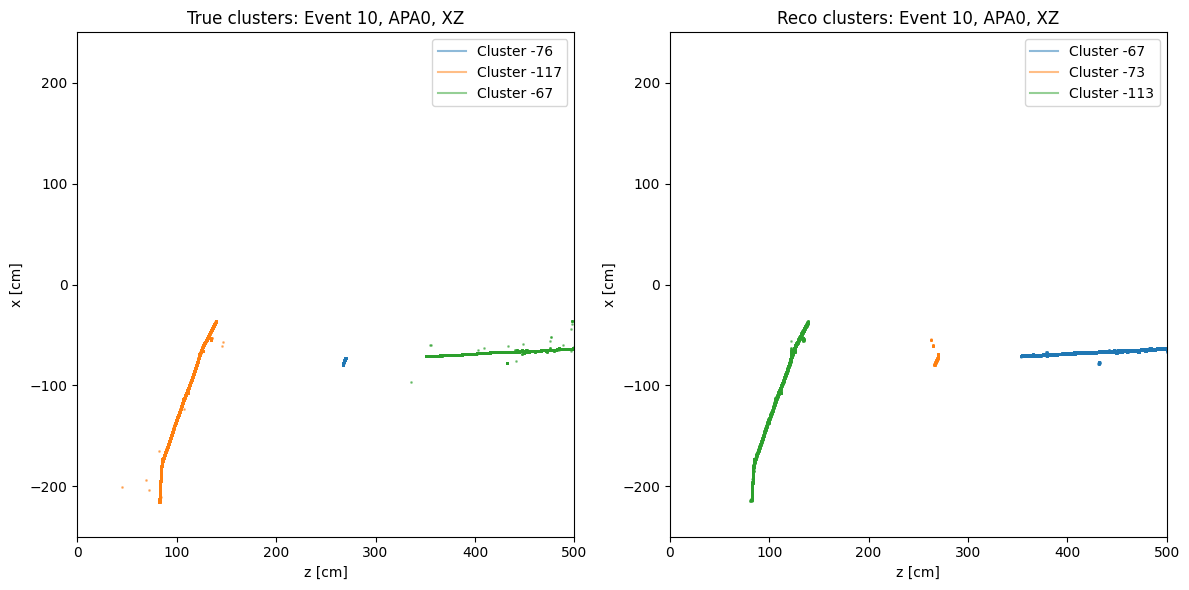

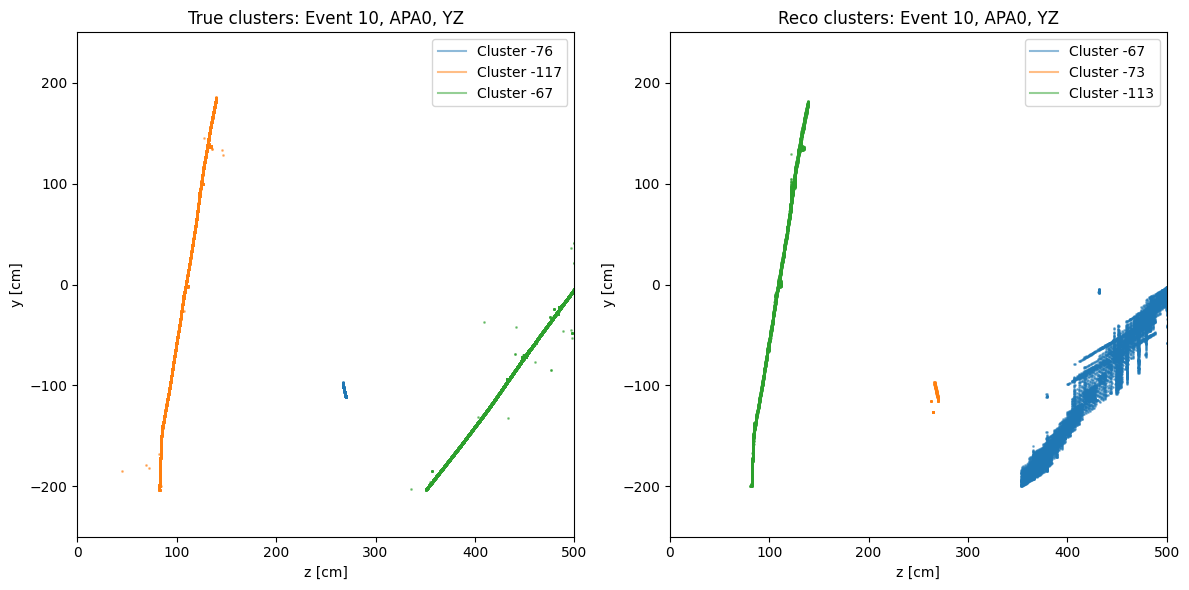

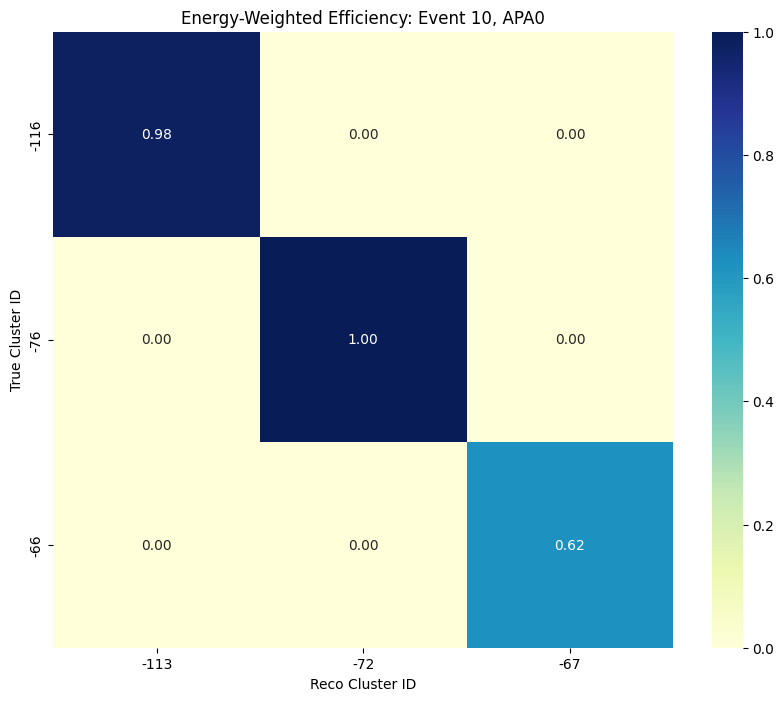

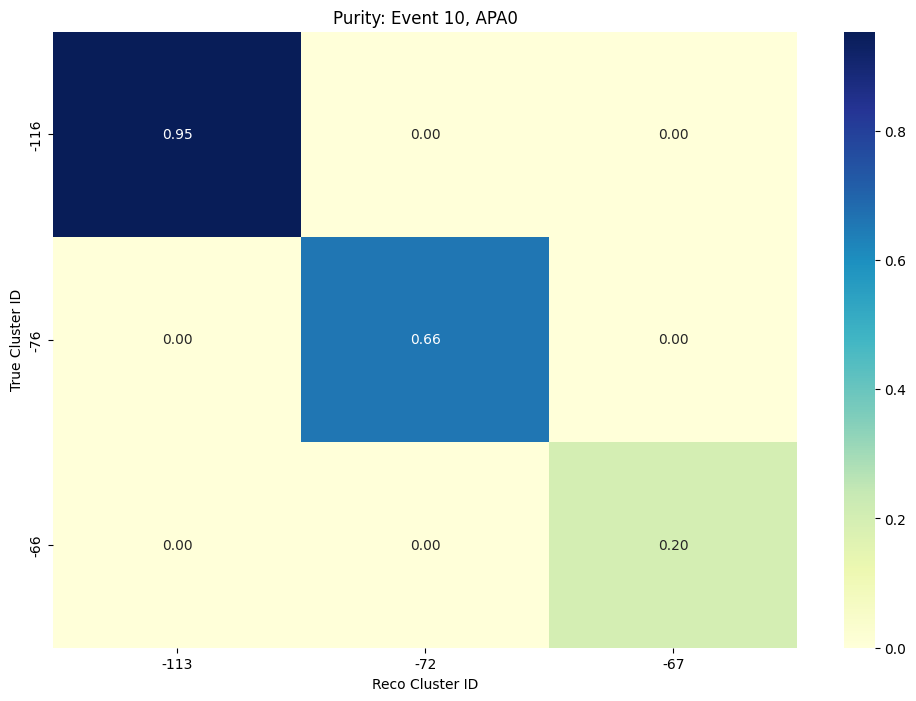

We have  3 matched pairs of true and reco clusters


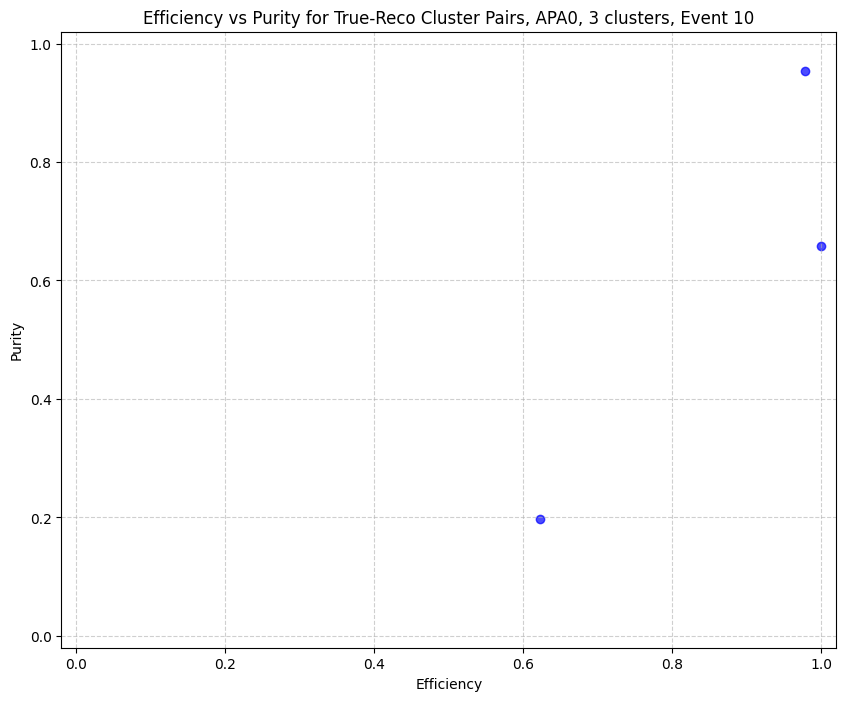

Efficiency and Purity values for each matched pair in Event 10:
True Cluster ID: -116.84, Reco Cluster ID: -113.41, Efficiency: 97.82%, Purity: 95.33%
True Cluster ID: -76.07, Reco Cluster ID: -72.92, Efficiency: 100.00%, Purity: 65.78%
True Cluster ID: -66.99, Reco Cluster ID: -67.22, Efficiency: 62.20%, Purity: 19.76%


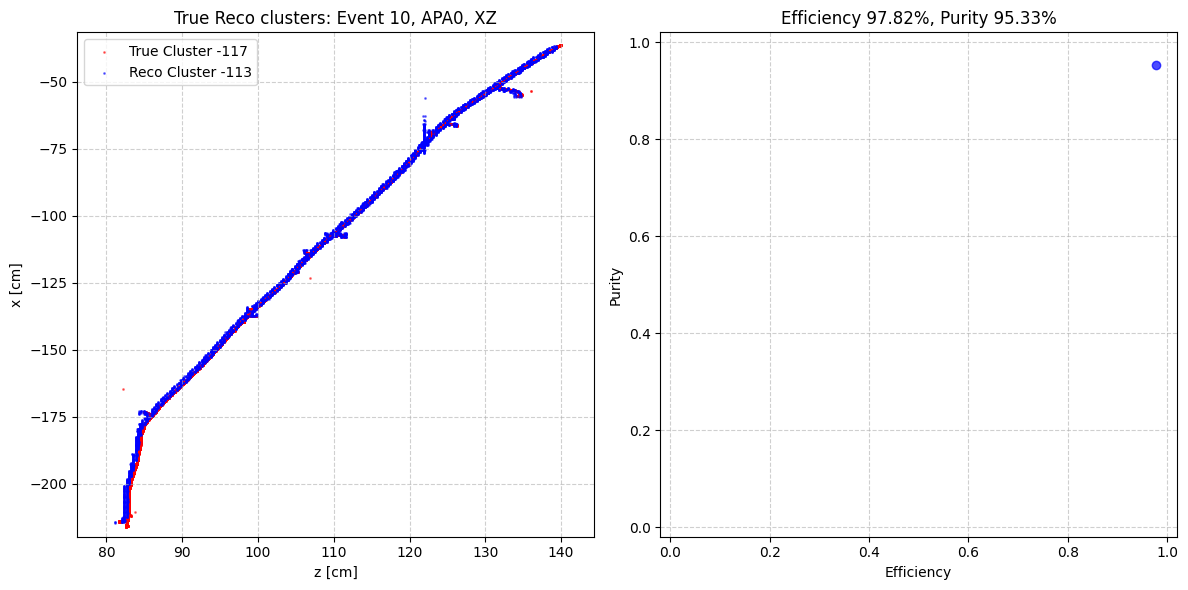

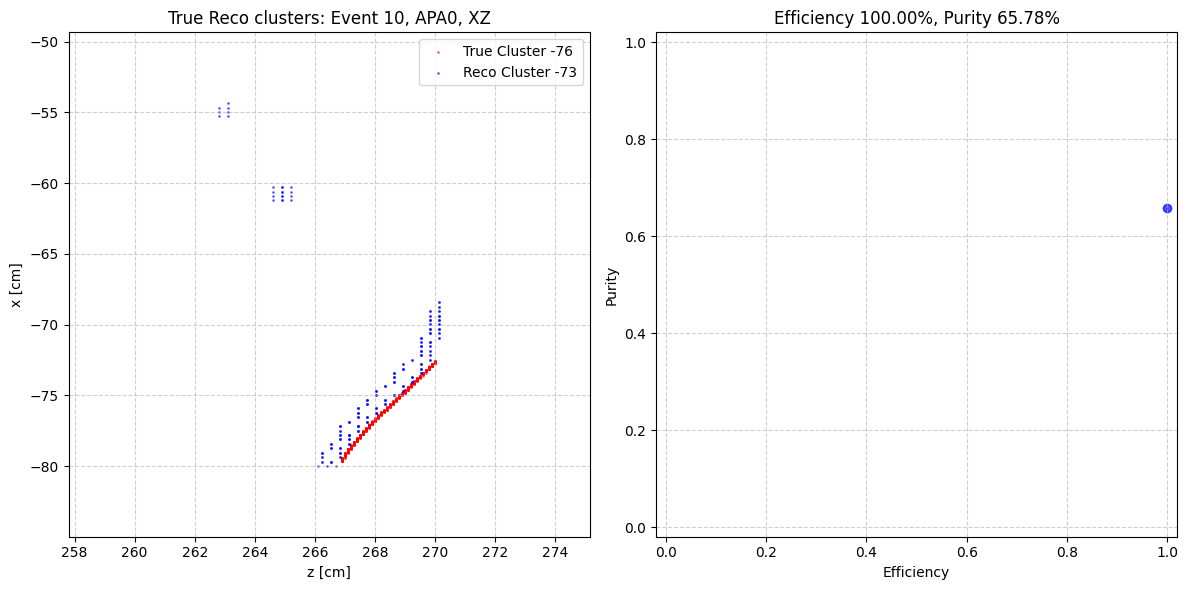

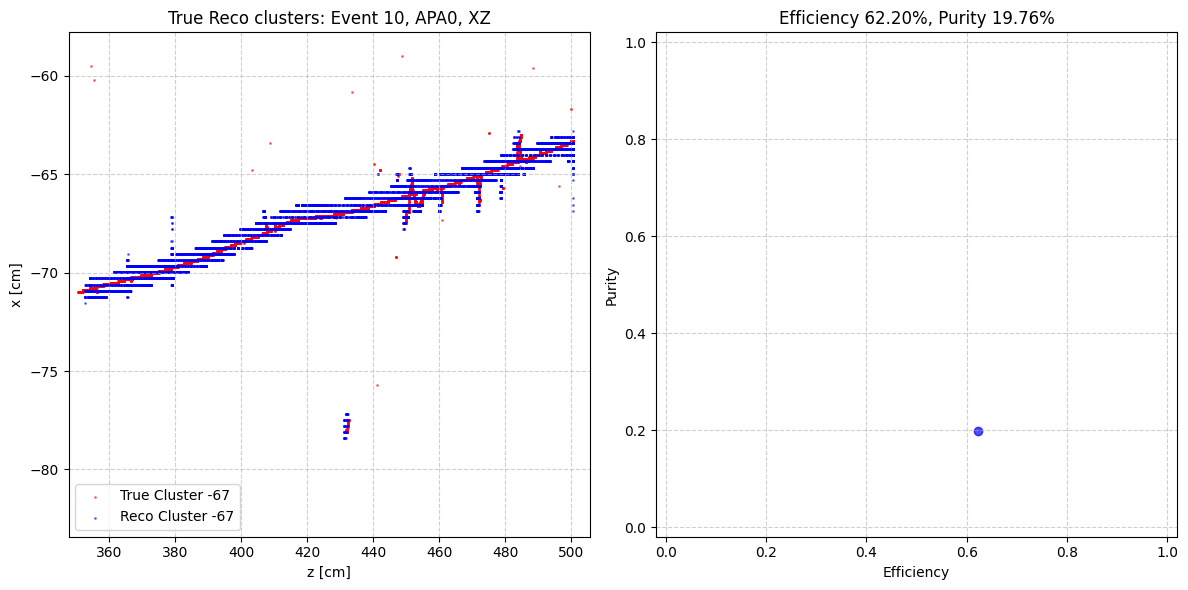



Processing event 11...
Number of true points before cosmic filter: 12620
Number of true points after cosmic filter (q_true != 1): 12568
Number of true points before energy cutoff: 12568
Number of true points after energy cutoff: 12552
Number of true points before minimum points cutoff: 12552
Number of true points after minimum points cutoff: 12552
Number of true points before fiducial volume cut: 12552
Number of true points after fiducial volume cut: 12356
Number of true clusters: 2
Number of reco points before minimum points cutoff: 3446
Number of reco points after minimum points cutoff: 3434
Number of reco points before fiducial volume cut: 3434
Number of reco points after fiducial volume cut: 3425
Number of reco clusters: 2


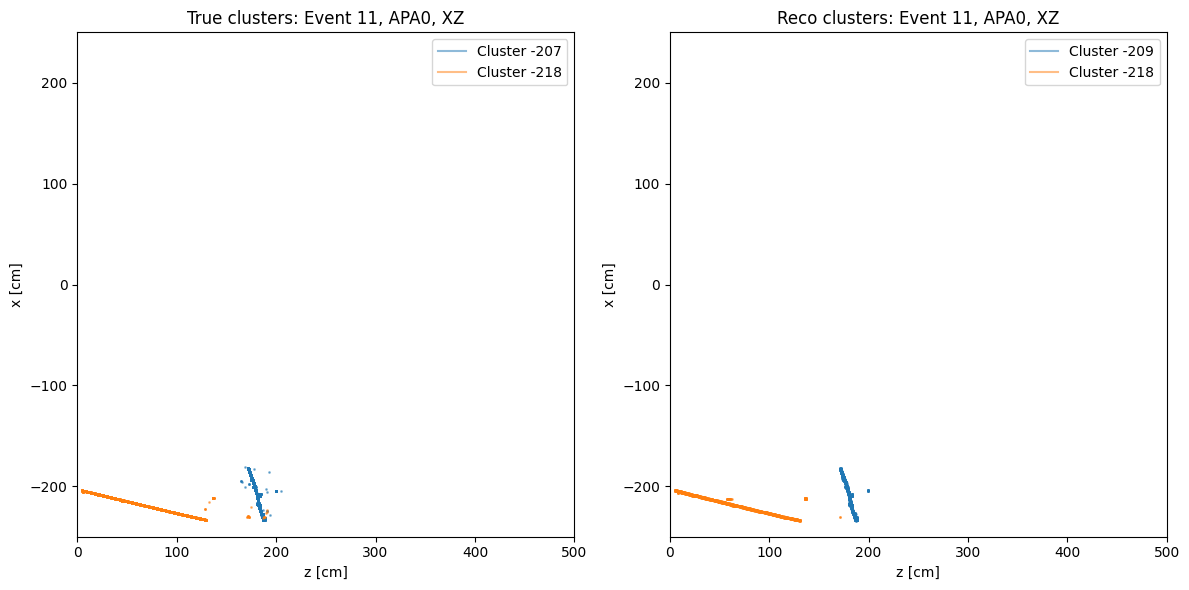

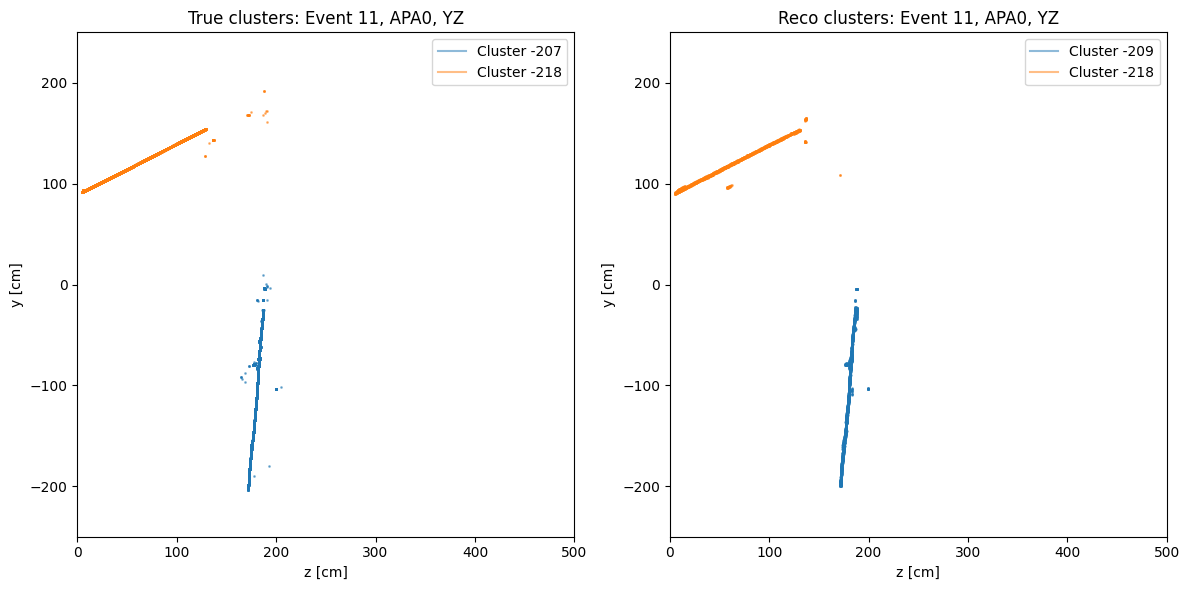

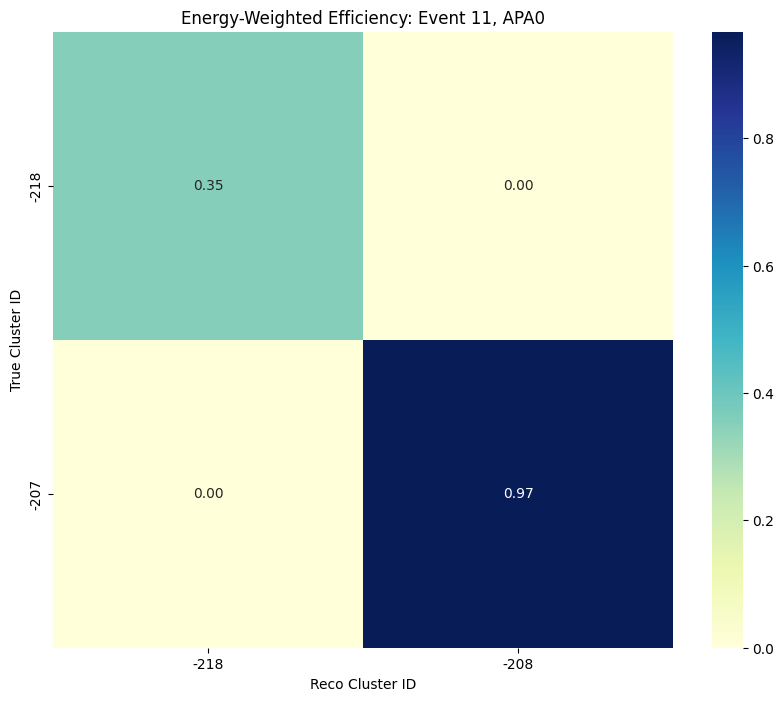

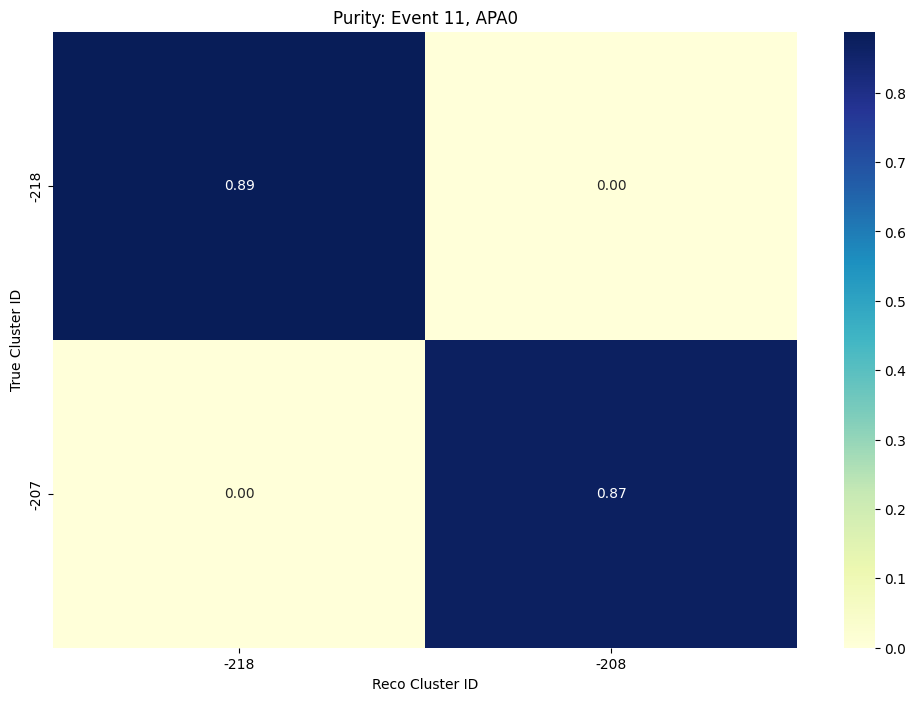

We have  2 matched pairs of true and reco clusters


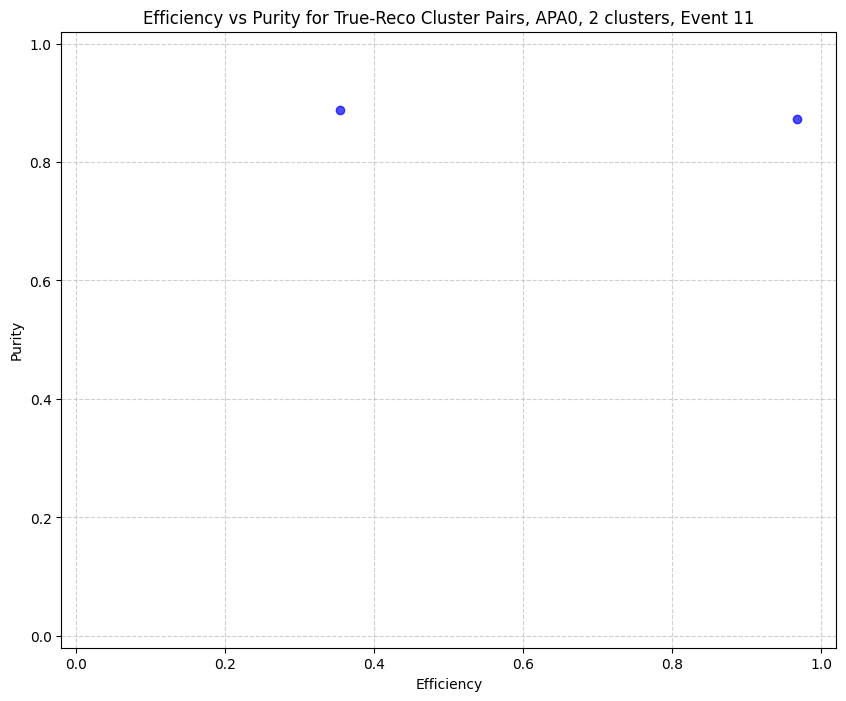

Efficiency and Purity values for each matched pair in Event 11:
True Cluster ID: -218.24, Reco Cluster ID: -218.04, Efficiency: 35.42%, Purity: 88.79%
True Cluster ID: -207.42, Reco Cluster ID: -208.51, Efficiency: 96.71%, Purity: 87.32%


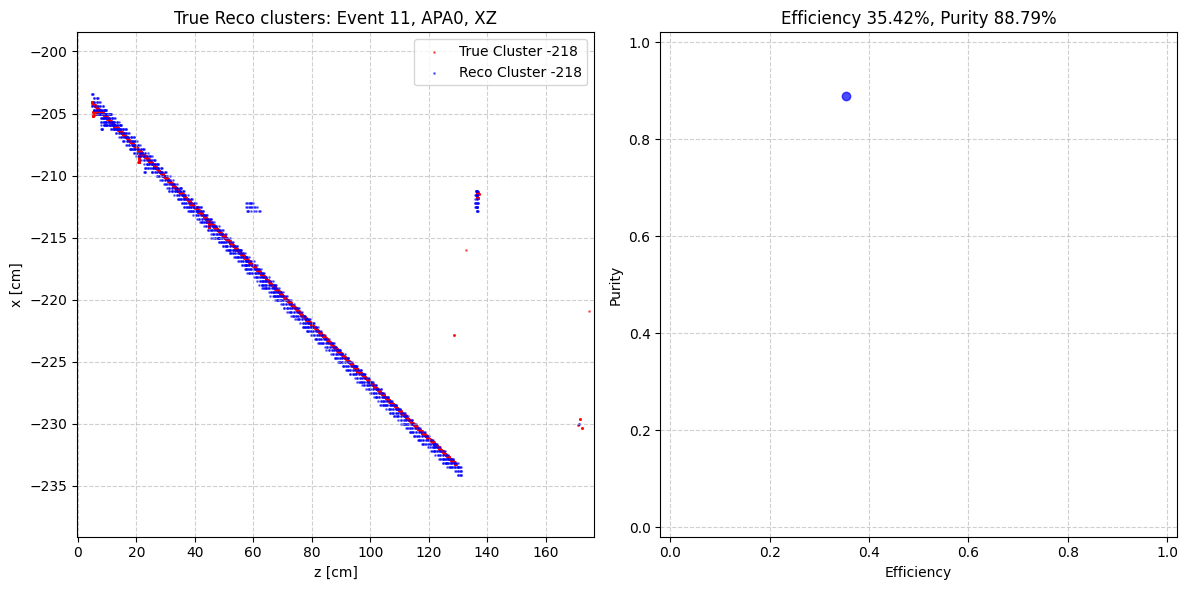

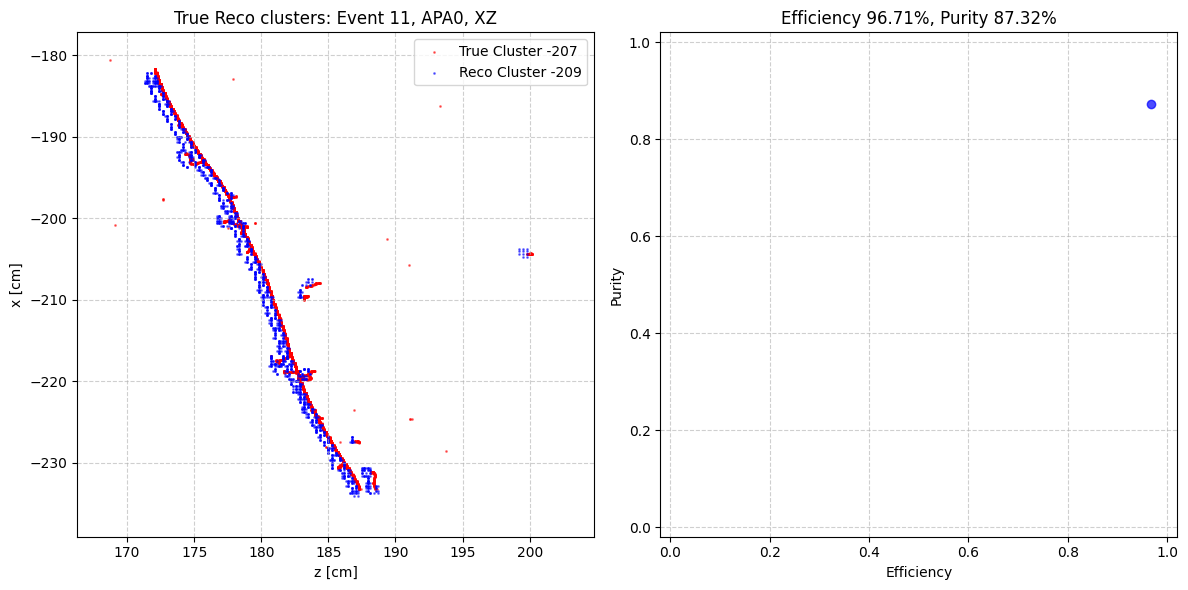



We have  49 matched pairs of true and reco clusters


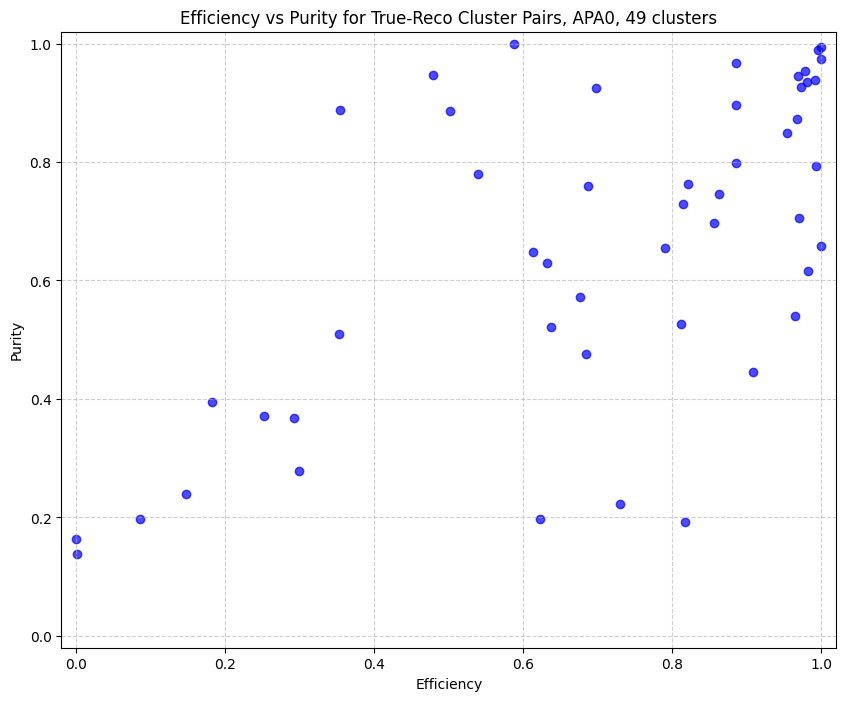


Efficiency and Purity Summary:
Total True-Reco Cluster Pairs: 49

Category                                                     Count      Percentage
Efficiency > 95% and Purity > 95%                            4          8.16      %
Efficiency > 90% and Purity > 90%                            8          16.33     %
Efficiency between 50-90% and Purity between 50-90%          15         30.61     %
Efficiency < 50% or Purity < 50%                             16         32.65     %

Efficiency Summary:
Efficiency > 95%               15         30.61     %
Efficiency > 90%               16         32.65     %
Efficiency > 80%               25         51.02     %
Efficiency > 50%               38         77.55     %
Efficiency < 50%               11         22.45     %




Purity Summary:
Purity > 95%                   6          12.24     %
Purity > 90%                   12         24.49     %
Purity > 80%                   17         34.69     %
Purity > 50%                   36        

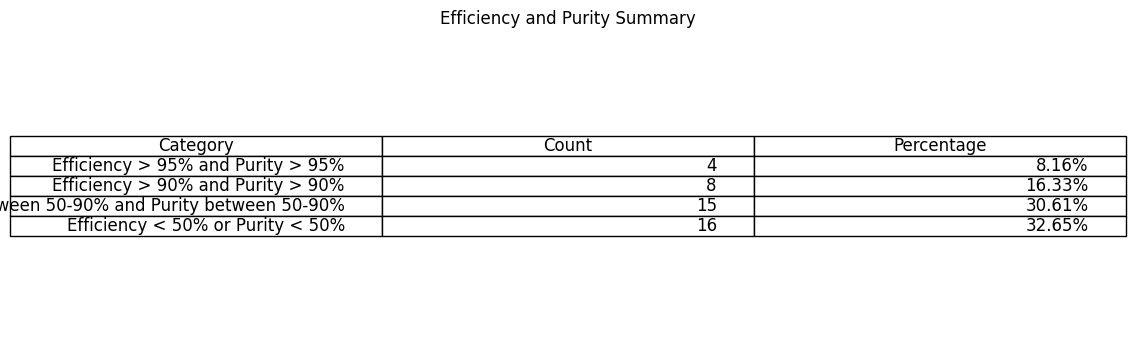

In [51]:
# Now we can loop over events and read in the true and reco coordinates for each event using the above function

# To save efficiency and purity information for all matched pairs across all events for later analysis, we can create empty lists before the loop and append the results from each event to these lists. Then we can use these lists to draw efficiency vs purity for all matched pairs across all events.
purity_results_all_clusters     = []
efficiency_results_all_clusters = []

for evt in range(event_low, event_high):
    print(f"Processing event {evt}...")
    PLOTDIR_EVT = PLOTDIR / str(evt)
    PLOTDIR_EVT.mkdir(parents=True, exist_ok=True)
    
    # read in true and reco coordinates for this event
    result = read_files_for_event(evt)
    
    x_true, y_true, z_true, id_true, q_true, e_true, t_true, x_pred, y_pred, z_pred, id_pred, q_pred = result
    
    # combine true and reco coordinates into a single array for easier processing
    true_5d_points      = np.column_stack((x_true, y_true, z_true, id_true, q_true, e_true))

    # Filter for cosmic clusters only (q_true != 1)
    print(f"Number of true points before cosmic filter: {len(true_5d_points)}")
    true_5d_points = filter_cosmic_points(true_5d_points)
    print(f"Number of true points after cosmic filter (q_true != 1): {len(true_5d_points)}")
    predicted_5d_points = np.column_stack((x_pred, y_pred, z_pred, id_pred, q_pred))

    # call function to apply energy cutoff for each true cluster
    if(Apply_energy_cutoff):
        print(f"Number of true points before energy cutoff: {len(true_5d_points)}")
        true_5d_points = apply_energy_cutoff(true_5d_points, min_cluster_energy)
        print(f"Number of true points after energy cutoff: {len(true_5d_points)}")

    # call function to apply minimum true points cutoff for each true cluster
    if(Apply_min_true_points_cutoff):
        print(f"Number of true points before minimum points cutoff: {len(true_5d_points)}")
        true_5d_points = apply_min_true_points_cutoff(true_5d_points, min_true_points_cutoff)
        print(f"Number of true points after minimum points cutoff: {len(true_5d_points)}")

    # Apply fiducial volume cut to true points
    if(Apply_fiducial_volume_cut):
        print(f"Number of true points before fiducial volume cut: {len(true_5d_points)}")
        true_5d_points = apply_fiducial_volume_cut_true(true_5d_points)
        print(f"Number of true points after fiducial volume cut: {len(true_5d_points)}")

    # Re-assign cluster IDs to true points based on proximity in x and y coordinates using the function defined above
    # Then group true points by cluster ID
    true_5d_points  = reassign_cluster_ID_true(true_5d_points)
    clusters_true   = GroupClustersByID(true_5d_points)
    print(f"Number of true clusters: {len(clusters_true)}")

    # call function to apply minimum reco points cutoff for each reco cluster
    if(Apply_min_reco_points_cutoff):
        print(f"Number of reco points before minimum points cutoff: {len(predicted_5d_points)}")
        predicted_5d_points = apply_min_reco_points_cutoff(predicted_5d_points, min_reco_points_cutoff)
        print(f"Number of reco points after minimum points cutoff: {len(predicted_5d_points)}")

    # Apply fiducial volume cut to reco points
    if(Apply_fiducial_volume_cut):
        print(f"Number of reco points before fiducial volume cut: {len(predicted_5d_points)}")
        predicted_5d_points = apply_fiducial_volume_cut_reco(predicted_5d_points)
        print(f"Number of reco points after fiducial volume cut: {len(predicted_5d_points)}")

    # Re-assign cluster IDs to reco points based on proximity in x and y coordinates using the function defined above
    # Then group reco points by cluster ID
    predicted_5d_points = reassign_cluster_ID_reco(predicted_5d_points)
    clusters_reco = GroupClustersByID(predicted_5d_points)
    print(f"Number of reco clusters: {len(clusters_reco)}")

    # Call function to increase reco points z values by +0.5 cm to account for the shift in the geometry file
    if(ShiftReco_Z):
        clusters_reco = ShiftRecoClusterZValues(clusters_reco, shift_value=0.5)

    # Call function to draw the true and the reco clusters together in the same plot to visually compare them
    # We will use different colors for true and reco clusters.
    DrawTrueRecoClustersXZ(clusters_true, clusters_reco, evt)
    DrawTrueRecoClustersYZ(clusters_true, clusters_reco, evt)   

    # Efficiency evaluation
    efficiency_results  = EvaluateEfficiency(clusters_true, clusters_reco, evt)
    efficiency_results_all_clusters.extend(efficiency_results)

    # Purity
    purity_results      = EvaluatePurity(clusters_true, clusters_reco, evt)
    purity_results_all_clusters.extend(purity_results)

    # Draw efficiency vs purity for all matched pairs after each event to see how they look for each event
    matched_pairs_event = MatchRecoTruePairs(purity_results, efficiency_results)
    DrawEfficiencyVsPurityEventLevel(matched_pairs_event, evt)

    print("\n")

# Match true and reco clustered based on their purities and efficiencies and save this information for all matched pairs in a list for later analysis
all_matched_pairs = MatchRecoTruePairs(purity_results_all_clusters, efficiency_results_all_clusters)

# Draw efficiency vs purity for all matched pairs
DrawEfficiencyVsPurity(all_matched_pairs)

# Now lets do some analyatic analysis
AnalyticResults(all_matched_pairs)